# 10. Portfolio Optimization: Tail Risk, Risk Parity and Robust Models

In this project we move from **mean-variance portfolio construction** into three families of portfolio models that care about risk in different ways:

- **Tail-risk models**, where the objective is based on VaR/CVaR rather than variance.
- **Parity and hierarchical models**, where the allocation is driven by risk contribution and correlation structure.
- **Robust models**, where we admit that expected returns and distributions are uncertain and build portfolios that survive estimation error.
- **Wasserstein distributionally robust optimization**, where the model protects against nearby alternative return distributions rather than trusting one sample.
- **Full model comparison**, where return, volatility, drawdown, expected shortfall, turnover, concentration, and stress behavior are compared together.
- **A secondary sector ETF application**, where we repeat the same model families on a more equity-like universe using the library workflow.

The important idea is that portfolio optimization isn't one problem. It's a set of related problems with different definitions of risk. Mean-variance says risk is covariance. CVaR says risk is the average loss in the worst tail. Risk parity says risk is the amount each asset contributes to total portfolio volatility. Robust optimization says risk also comes from being wrong about the inputs. This project puts those definitions next to each other and lets the backtest show what each one buys and what it costs.

A useful way to read the whole project is to keep four objects separate:

| Object | Symbol | What changes across models |
|---|---|---|
| Expected return estimate | $\hat{\mu}$ | ignored, used directly, shrunk, or penalized |
| Covariance estimate | $\hat{\Sigma}$ | used for variance, risk contributions, clustering, and robust norms |
| Scenario matrix | $R$ | used directly by CVaR and indirectly by covariance/mean estimates |
| Constraint set | $\mathcal{C}$ | keeps all models long-only, fully invested, and capped |

Most portfolio formulas look like they are optimizing weights, but they are really optimizing a **translation of beliefs into weights**. The belief can be "the mean estimate is useful", "the worst 5% scenarios matter more than variance", "each sleeve should contribute equal risk", or "the estimates are unreliable and need an uncertainty penalty".

That distinction helps later when two models hold similar assets for different reasons. For example, Mean-CVaR and Wasserstein DRMV can both like GLD or DBC in a certain window. Mean-CVaR may like them because they help satisfy the historical tail-loss budget. Wasserstein DRMV may like them because their robust return still survives the distributional penalty. The weights can look similar, but the explanation behind those weights is different.

We also need to keep **risk measurement** separate from **portfolio construction**. A model can optimize CVaR and then still be evaluated by Sharpe, Calmar, drawdown, turnover, and expected shortfall. The objective tells us what the model was trying to do. The final report tells us whether that objective produced a useful portfolio under realistic out-of-sample testing.

## 1) The Portfolio Problem After Mean-Variance

We already used mean-variance models earlier, so we don't need to rebuild that whole theory again. The useful starting point here is the weakness that kept showing up: most portfolio models are extremely sensitive to the **input estimates**.

A portfolio optimizer receives three kinds of information:

$$
\hat{\mu}, \qquad \hat{\Sigma}, \qquad \mathcal{C}
$$

where $\hat{\mu}$ is the estimated expected return vector, $\hat{\Sigma}$ is the estimated covariance matrix, and $\mathcal{C}$ is the constraint set, such as long-only weights, full investment, and max-weight caps. If those inputs were known perfectly, the optimization problem would be clean. In real markets, they aren't known. We estimate them from a finite rolling sample, and that makes every model partly a statistical model before it becomes a portfolio model.

The current project keeps the repeated data and baseline machinery short and spends the detail on the new question:

> If variance and raw expected returns aren't enough, how else can we define a portfolio that is safer, more balanced, or more robust?

We work with the same cross-asset ETF universe used in the previous portfolio projects. The data can be reproduced from the [`core_cross_asset_etfs`](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/core_cross_asset_etfs) folder inside the repository's data layer. That folder contains the source notes and script workflow for rebuilding the file used by this project. We also repeat the workflow on sector ETFs later, using the [`sector_etfs`](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/sector_etfs) data folder.

The baselines are also reused. Equal Weight, MinVar, MV, and MaxSharpe come from the same model family developed in [Project 2](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/02_portfolio_optimization_MV_models.html), and Learned-Confidence BL comes from [Project 6](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/06_portfolio_black_littreman.html). Here they serve as reference portfolios, not as the main teaching topic.

We start by loading the project environment, imports, plotting settings, and the cross-asset ETF panel. There isn't much theory in this cell. The important thing is that the later models depend on `cvxpy` for convex programs, SciPy clustering for hierarchical allocation, and the `quantfinlab` portfolio/risk-reporting utilities for consistent backtesting.

The repeated implementation convention is the same as earlier:

$$
r_{t,i} = \frac{P_{t,i}}{P_{t-1,i}} - 1
$$

where $P_{t,i}$ is the adjusted close price of asset $i$ at day $t$, and $r_{t,i}$ is the simple daily return. We stack the daily returns into a matrix

$$
R_t \in \mathbb{R}^{T \times N}
$$

where $T$ is the rolling estimation window and $N$ is the number of assets. Each row is one historical day and each column is one ETF.

For this project, the matrix matters more than in a simple mean-variance backtest because different models read it differently:

- CVaR models read **scenario losses** from the rows of $R_t$.
- Parity models read **covariance structure** from $\hat{\Sigma}_t$.
- Robust models read both **estimated means** and **estimation uncertainty**.
- Wasserstein DRO treats the empirical sample as only one possible distribution inside a neighborhood of plausible distributions.

In [1]:
from pathlib import Path
import warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import cvxpy as cp
from cycler import cycler
from IPython.display import display
from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.portfolio import covariance, expected_returns, selection, attribution
from quantfinlab.portfolio import prices_to_returns, make_rebalance_dates
from quantfinlab.portfolio.covariance import make_psd
from quantfinlab.portfolio.walkforward import run_walkforward_grid, append_frontiergrid_from_best_maxsharpe
from quantfinlab.portfolio import black_litterman as bl
from quantfinlab.portfolio import views as bl_views
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.risk import drawdown_episodes_table, drawdown_summary_table, stress_table, var_es_table, capm_table, rolling_volatility
from quantfinlab.plotting.portfolio import plot_strategy_nav, plot_strategy_drawdowns
from quantfinlab.reports import risk_report
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7", "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({"figure.figsize": (7, 3.5), "figure.dpi": 140, "savefig.dpi": 250, "axes.grid": True, "grid.alpha": 0.20, "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 11, "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8})
project_title = "Portfolio Optimization Models: Tail risk, Risk Parity and Robust Optimization"
repo_root = Path.cwd()
if not (repo_root / "data" / "core_cross_asset_etfs.csv").exists() and (repo_root.parent / "data" / "core_cross_asset_etfs.csv").exists():
    repo_root = repo_root.parent
data_path = repo_root / "data" / "core_cross_asset_etfs.csv"


In [2]:
loaded = load_yfinance_panel(data_path, fields=("close",), source="yfinance_export", lowercase=False)
close_all = loaded["close"].sort_index()
print(project_title)
print("loaded close table:", close_all.shape, close_all.index.min().date(), "to", close_all.index.max().date())


Portfolio Optimization Models: Tail risk, Risk Parity and Robust Optimization
loaded close table: (6906, 19) 1999-01-04 to 2026-06-17


The return matrix can be read in two ways. For mean-variance, we often compress it into two estimates:

$$
\hat{\mu} = \frac{1}{T}\sum_{s=1}^{T} r_s
$$

$$
\hat{\Sigma} = \frac{1}{T-1}\sum_{s=1}^{T}(r_s-\hat{\mu})(r_s-\hat{\mu})^\top
$$

After that compression, the optimizer no longer sees individual crisis days. It only sees average return and covariance. CVaR works differently. It keeps the scenario-level losses:

$$
\ell_s(w)=-r_s^\top w,\qquad s=1,\ldots,T
$$

That means one very bad historical day can directly enter the optimization if it belongs to the worst tail. This is why CVaR is more connected to realized stress scenarios than variance. Variance smooths bad days into a second moment. CVaR identifies the worst days and averages their losses.

For example, if two portfolios have the same volatility but one has many small losses and the other has rare crash losses, variance can treat them as similar. CVaR will usually prefer the first one because its worst 5% outcomes are less severe. This is exactly the kind of distinction that matters when we compare Mean-CVaR against MV and MaxSharpe later.

In [3]:
start_date = "2013-01-01"
assets = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "IEF", "SHY", "AGG", "LQD", "HYG", "GLD", "VNQ", "DBC"]
signal_only_assets = ["UUP"] if "UUP" in close_all.columns else []
close_after_start = close_all.loc[pd.Timestamp(start_date):].copy()
missing_assets = [ticker for ticker in assets if ticker not in close_after_start.columns]
if missing_assets:
    raise ValueError(f"missing required investable ETF columns: {missing_assets}")
first_all_valid = close_after_start[assets].dropna(how="any").index.min()
if pd.isna(first_all_valid):
    raise ValueError("no date where all investable ETFs have adjusted close data")
close = close_after_start.loc[first_all_valid:, assets].ffill(limit=3).dropna(how="any")
returns = prices_to_returns(close, kind="simple").replace([np.inf, -np.inf], np.nan).dropna(how="all").fillna(0.0)
close = close.reindex(returns.index).ffill(limit=3)
signal_tickers = list(dict.fromkeys(assets + signal_only_assets))
signal_close = close_after_start.loc[first_all_valid:, signal_tickers].ffill(limit=3).reindex(returns.index).ffill(limit=3)
signal_returns = prices_to_returns(signal_close, kind="simple").replace([np.inf, -np.inf], np.nan).reindex(returns.index).fillna(0.0)


In [4]:
coverage_rows = []
for ticker in assets + signal_only_assets:
    px = close_after_start[ticker]
    valid = px.dropna()
    first = valid.index.min() if len(valid) else pd.NaT
    coverage_rows.append({"ticker": ticker, "first_date": first, "last_date": valid.index.max() if len(valid) else pd.NaT, "observations": int(len(valid)), "missing_after_first_valid": float(px.loc[first:].isna().sum()) if len(valid) else np.nan, "investable": ticker in assets})
coverage_table = pd.DataFrame(coverage_rows)
data_table = pd.DataFrame([{"number_of_assets": len(assets), "first_date": returns.index.min(), "last_date": returns.index.max(), "daily_return_rows": len(returns), "missing_values_after_alignment": int(returns[assets].isna().sum().sum())}])
display(data_table)
display(coverage_table)
print("signal assets:", list(signal_returns.columns))


,number_of_assets,first_date,last_date,daily_return_rows,missing_values_after_alignment
0,14,2013-01-03,2026-06-17,3384,0


,ticker,first_date,last_date,observations,missing_after_first_valid,investable
0,SPY,2013-01-02,2026-06-17,3385,0.0,True
1,QQQ,2013-01-02,2026-06-17,3385,0.0,True
2,IWM,2013-01-02,2026-06-17,3385,0.0,True
3,EFA,2013-01-02,2026-06-17,3385,0.0,True
4,EEM,2013-01-02,2026-06-17,3385,0.0,True
5,TLT,2013-01-02,2026-06-17,3385,0.0,True
6,IEF,2013-01-02,2026-06-17,3385,0.0,True
7,SHY,2013-01-02,2026-06-17,3385,0.0,True
8,AGG,2013-01-02,2026-06-17,3385,0.0,True
9,LQD,2013-01-02,2026-06-17,3385,0.0,True


signal assets: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'IEF', 'SHY', 'AGG', 'LQD', 'HYG', 'GLD', 'VNQ', 'DBC', 'UUP']


The loaded close table contains 6,906 rows and 19 columns from 1999-01-04 to 2026-06-17. We don't use the full historical range because the investable ETF universe needs aligned coverage. After the 2013 start filter and the all-valid ETF alignment, the investable return panel contains 3,384 daily observations from 2013-01-03 to 2026-06-17.

This is a clean setup for a portfolio model comparison. The panel has enough history to estimate multi-year covariance matrices, it spans calm markets, the COVID crash, the 2022 inflation/rate shock, and the 2023-2026 growth rebound. Those environments are important because the new models aren't meant to look good only in average conditions. CVaR and robust models are especially useful when the average market environment is no longer representative of the next month.

The signal-only asset `UUP` is included for the Black-Litterman baseline, but the investable universe has 14 ETFs. The missing-value check is also clean: after alignment, there are zero missing values in the investable return panel. That matters because CVaR optimization uses historical scenarios directly. A missing value inside a scenario matrix would change the tail set and could distort which days count as bad outcomes.

## 2) Universe, Rebalancing, and Constraints

The tradable universe stays the same as the earlier cross-asset portfolio work, but the way constraints interact with the new models deserves attention.

We use 14 ETFs across four sleeves:

| Sleeve | Assets | Main risk carried |
|---|---|---|
| Equities | SPY, QQQ, IWM, EFA, EEM | equity beta, growth/cyclicality, global risk appetite |
| Duration | TLT, IEF, SHY, AGG | interest-rate duration, curve shocks, flight-to-quality behavior |
| Credit | LQD, HYG | spread risk, default-risk repricing, equity-like credit beta |
| Diversifiers | GLD, VNQ, DBC | gold, real estate, commodities, inflation/real-asset exposure |

We don't re-explain every ETF here because the data and economic role of this universe were already discussed in the earlier portfolio notebooks. For Project 10, the key point is how these sleeves behave under different risk definitions.

A variance-focused model may prefer SHY because it has very low volatility. A CVaR model may prefer assets that avoid large negative tail scenarios. A risk parity model may give large weight to low-volatility bonds because they need more capital to contribute equal volatility risk. A robust model may penalize assets with high expected-return uncertainty, even when their point forecast looks attractive.

The constraint set is:

$$
\mathbf{1}^\top w = 1
$$

$$
0 \le w_i \le \bar{w}_i
$$

where $w_i$ is the weight of asset $i$, $\mathbf{1}^\top w=1$ means the portfolio is fully invested, and $\bar{w}_i$ is the asset-specific cap. These caps are essential. Without caps, many of the optimizers would collapse into one or two assets because the sample makes some assets look much better or much safer than the others.

In [5]:
rebal_freq = "ME"
cov_lookback = 756
mu_lookback = 252
annualization = 252
ewma_lambda = 0.97
risk_free_rate_annual = 0.04
risk_free_daily = (1 + risk_free_rate_annual) ** (1 / annualization) - 1
cost_bps = 10.0
w_min = 0.0
w_max = 0.40
mv_lambda = 4.0
fixed_benchmark_weights = {"SPY": 0.24, "QQQ": 0.10, "IWM": 0.06, "EFA": 0.12, "EEM": 0.06, "TLT": 0.10, "IEF": 0.08, "SHY": 0.04, "AGG": 0.06, "LQD": 0.04, "HYG": 0.03, "GLD": 0.05, "VNQ": 0.04, "DBC": 0.04}
benchmark_w = pd.Series(fixed_benchmark_weights, dtype=float).reindex(assets).fillna(0.0)
benchmark_w = benchmark_w / float(benchmark_w.sum())
sleeve_groups = {"equities": ["SPY", "QQQ", "IWM", "EFA", "EEM"], "duration": ["TLT", "IEF", "SHY", "AGG"], "credit": ["LQD", "HYG"], "diversifiers": ["GLD", "VNQ", "DBC"]}
sleeve_map = {asset: sleeve for sleeve, names in sleeve_groups.items() for asset in names}
asset_cap_map = {"SPY": 0.40, "QQQ": 0.40, "IWM": 0.35, "EFA": 0.35, "EEM": 0.35, "TLT": 0.25, "IEF": 0.25, "SHY": 0.15, "AGG": 0.30, "LQD": 0.25, "HYG": 0.15, "GLD": 0.30, "VNQ": 0.30, "DBC": 0.25}
asset_caps = pd.Series({asset: asset_cap_map.get(asset, w_max) for asset in assets}, index=assets, dtype=float)


In [6]:
rebalance_dates = make_rebalance_dates(returns.index, freq=rebal_freq, min_history_days=max(cov_lookback, mu_lookback, 756))
fixed_universe_by_date = {pd.Timestamp(dt): {"tickers": list(assets), "avg_dollar_volume": pd.Series(1.0, index=assets)} for dt in rebalance_dates}
universe_table = pd.DataFrame({"asset": assets, "sleeve": [sleeve_map.get(asset, "other") for asset in assets], "asset_cap": asset_caps.reindex(assets).values})
benchmark_table = pd.DataFrame({"asset": assets, "sleeve": [sleeve_map.get(asset, "other") for asset in assets], "benchmark_weight": benchmark_w.reindex(assets).values, "asset_cap": asset_caps.reindex(assets).values})
rebalance_summary = pd.DataFrame([{"count": len(rebalance_dates), "first_rebalance": rebalance_dates[0], "last_rebalance": rebalance_dates[-1], "frequency": rebal_freq, "cov_lookback": cov_lookback, "mu_lookback": mu_lookback}])
display(universe_table)
display(benchmark_table.round(4))
display(rebalance_summary)


,asset,sleeve,asset_cap
0,SPY,equities,0.40
1,QQQ,equities,0.40
2,IWM,equities,0.35
3,EFA,equities,0.35
4,EEM,equities,0.35
5,TLT,duration,0.25
6,IEF,duration,0.25
7,SHY,duration,0.15
8,AGG,duration,0.30
9,LQD,credit,0.25


,asset,sleeve,benchmark_weight,asset_cap
0,SPY,equities,0.2264,0.40
1,QQQ,equities,0.0943,0.40
2,IWM,equities,0.0566,0.35
3,EFA,equities,0.1132,0.35
4,EEM,equities,0.0566,0.35
5,TLT,duration,0.0943,0.25
6,IEF,duration,0.0755,0.25
7,SHY,duration,0.0377,0.15
8,AGG,duration,0.0566,0.30
9,LQD,credit,0.0377,0.25


,count,first_rebalance,last_rebalance,frequency,cov_lookback,mu_lookback
0,126,2016-01-29,2026-06-17,ME,756,252


The universe table confirms the investable set and caps. SPY and QQQ can reach 40%, several equity and diversifier ETFs have 30-35% caps, and safer bond-like instruments have lower or moderate caps depending on their role. SHY is capped at 15%, which is important because a pure variance minimizer would otherwise lean too heavily into it.

The benchmark table gives the strategic reference weights. The largest neutral allocations are SPY at about 22.64%, EFA at 11.32%, QQQ and TLT at 9.43%, and IEF at 7.55%. This benchmark isn't the object being optimized in the new models, but it gives useful context for later comparisons. When we see a model hold 40% SHY, 40% DBC, or 40% EEM, we can compare that to the much more balanced benchmark and ask whether the model's risk definition is forcing a concentrated decision.

The rebalance setup gives 126 monthly rebalance dates from 2016-01-29 to 2026-06-17. We start in 2016 because the covariance lookback is 756 trading days, about three years. This is a good compromise: the window is long enough to estimate a stable covariance matrix and tail distribution, but short enough to adapt after large market structure changes.

We then rebuild the baseline grid. This is deliberately short because these models were already taught earlier. The grid searches through covariance and expected-return combinations, then selects:

- Equal Weight as the simplest fully diversified reference.
- MinVar as the variance-only defensive benchmark.
- MV as the standard mean-variance benchmark.
- MaxSharpe as the return-seeking frontier benchmark.

The selected versions are:

| Role | Selected model |
|---|---|
| Equal weight | EW |
| Minimum variance | MinVar with OAS covariance |
| Mean-variance | MV with Ledoit-Wolf covariance and Bayes-Stein expected returns |
| MaxSharpe | MaxSharpe with sample covariance and Bayes-Stein Momentum expected returns |

The point isn't to teach these again. The point is to keep them in the comparison because the new models need a serious benchmark. If a CVaR or robust model can't beat a simple MaxSharpe or BL baseline on a useful metric, then the more complex objective needs to justify itself through lower drawdowns, lower tail loss, lower turnover, or better stability.

In [7]:
cov_models = {"Sample": covariance.sample_covariance, "LedoitWolf": covariance.ledoit_wolf_covariance, "OAS": covariance.oas_covariance, "EWMA": covariance.ewma_covariance}
mu_models = {"Momentum": expected_returns.momentum_mu, "BayesStein": expected_returns.bayes_stein_mu, "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu}
walkforward_grid = run_walkforward_grid(returns=returns[assets], close=close[assets], rebalance_dates=rebalance_dates, universe_by_date=fixed_universe_by_date, cov_models=cov_models, mu_models=mu_models, cov_lookback=cov_lookback, mu_lookback=mu_lookback, min_cov_observations=cov_lookback - 1, min_mu_observations=mu_lookback - 1, max_weight=w_max, min_weight=w_min, long_only=True, trading_cost_bps=cost_bps, turnover_penalty_bps=cost_bps, fallback="equal", rf_daily=risk_free_daily, annualization=annualization, ewma_lambda=ewma_lambda, optimizer_params={"MV": {"mv_lambda": mv_lambda}, "RidgeMV": {"mv_lambda": mv_lambda}, "FrontierGrid": {"grid_n": 15}})
walkforward_grid = append_frontiergrid_from_best_maxsharpe(walkforward_grid, grid_n=15)


In [8]:
def ordered_strategy_table(table):
    cols = ["Sharpe", "Max Drawdown", "Turnover", "CAGR"]
    ascending = [False, False, True, False]
    present = [col for col in cols if col in table.columns]
    asc = [ascending[cols.index(col)] for col in present]
    return table.replace([np.inf, -np.inf], np.nan).sort_values(present, ascending=asc)
benchmark_summary = walkforward_grid.results.copy()
benchmark_summary_ranked = ordered_strategy_table(benchmark_summary)

In [9]:
def pick_best_strategy(summary, optimizer):
    candidates = summary[summary["Optimizer"].eq(optimizer)].replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
    if candidates.empty:
        return None
    return str(ordered_strategy_table(candidates).index[0])
grid_equal_weight_name = "EW" if "EW" in walkforward_grid.backtests else pick_best_strategy(benchmark_summary, "EW")
best_minvar_name = pick_best_strategy(benchmark_summary, "MinVar")
best_mv_name = pick_best_strategy(benchmark_summary, "MV")
best_maxsharpe_name = pick_best_strategy(benchmark_summary, "MaxSharpe")
if best_maxsharpe_name is None:
    best_maxsharpe_name = pick_best_strategy(benchmark_summary, "FrontierGrid")
if grid_equal_weight_name is None or best_minvar_name is None or best_mv_name is None or best_maxsharpe_name is None:
    raise ValueError("could not select all required benchmark strategies from the walk-forward grid")
_, _, best_minvar_cov = selection.parse_strategy_spec(best_minvar_name, walkforward_grid.backtests[best_minvar_name])
_, best_mv_mu, best_mv_cov = selection.parse_strategy_spec(best_mv_name, walkforward_grid.backtests[best_mv_name])
_, best_maxsharpe_mu, best_maxsharpe_cov = selection.parse_strategy_spec(best_maxsharpe_name, walkforward_grid.backtests[best_maxsharpe_name])
benchmark_results = {"Equal Weight": walkforward_grid.backtests[grid_equal_weight_name], best_minvar_name: walkforward_grid.backtests[best_minvar_name], best_mv_name: walkforward_grid.backtests[best_mv_name], best_maxsharpe_name: walkforward_grid.backtests[best_maxsharpe_name]}
selected_benchmark_names = pd.Series({"equal_weight_name": grid_equal_weight_name, "best_minvar_name": best_minvar_name, "best_mv_name": best_mv_name, "best_maxsharpe_name": best_maxsharpe_name, "best_minvar_cov": best_minvar_cov, "best_mv_cov": best_mv_cov, "best_mv_mu": best_mv_mu, "best_maxsharpe_cov": best_maxsharpe_cov, "best_maxsharpe_mu": best_maxsharpe_mu})
selected_benchmark_table = benchmark_summary.loc[[grid_equal_weight_name, best_minvar_name, best_mv_name, best_maxsharpe_name]].copy()
print(selected_benchmark_names.to_string())
display(selected_benchmark_table.round(4))


equal_weight_name                                          EW
best_minvar_name                                 MinVar (OAS)
best_mv_name                      MV (LedoitWolf, BayesStein)
best_maxsharpe_name    MaxSharpe (Sample, BayesSteinMomentum)
best_minvar_cov                                           OAS
best_mv_cov                                        LedoitWolf
best_mv_mu                                         BayesStein
best_maxsharpe_cov                                     Sample
best_maxsharpe_mu                          BayesSteinMomentum


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
EW,EW,-,-,0.0848,0.0935,0.4842,-0.2038,0.4159,0.5934,0.0114,1.4385,0.0010,14.0000,0
MinVar (OAS),MinVar,-,OAS,0.0665,0.0754,0.3543,-0.1973,0.3370,0.4044,0.0031,0.3897,0.0003,9.1680,0
"MV (LedoitWolf, BayesStein)",MV,BayesStein,LedoitWolf,0.0814,0.0847,0.4949,-0.1378,0.5904,0.6049,0.0369,4.6481,0.0028,5.0557,0
"MaxSharpe (Sample, BayesSteinMomentum)",MaxSharpe,BayesSteinMomentum,Sample,0.1168,0.1189,0.6553,-0.1653,0.7065,0.8164,0.2177,27.4264,0.0158,3.2046,0


The baseline table already gives a useful warning. MaxSharpe has the highest baseline CAGR at 11.68% and Sharpe at 0.6553, but it also has high turnover of 21.77% per month and low effective diversification with average effective $N$ around 3.20. That means it gets its performance from concentrated bets that move around.

MV with Ledoit-Wolf and Bayes-Stein is much more conservative: CAGR 8.14%, volatility 8.47%, Sharpe 0.4949, and a strong max drawdown of -13.78%. MinVar has even lower volatility but lower return. Equal Weight is stable and diversified, but its max drawdown is the worst among the baseline set at -20.38%.

So the baseline problem is already visible:

- MaxSharpe gives strong performance, but it concentrates and trades.
- MinVar controls volatility, but gives up too much return.
- MV is balanced, but still depends on a fragile expected-return estimate.
- Equal Weight is stable by construction, but doesn't react to changing risk.

The new models will mostly try to control this exact tradeoff.

## 3) Learned-Confidence Black-Litterman as a Strong Reference

We rebuild the Learned-Confidence BL strategy from Project 6 and include it as a reference. We don't re-teach the full Black-Litterman posterior here, but it helps to remember what BL contributes to the comparison.

The BL model starts from an equilibrium prior, generates active relative views, learns view confidence from realized payoff history, and converts the posterior return vector into a constrained portfolio. In this project, it gives us a strong "active but structured" benchmark.

The reason BL is important here is that the new models are not only competing against classical MV. They're competing against a model that already tries to solve one of MV's biggest weaknesses: the instability of raw expected returns. If a robust optimizer beats simple MV but loses to BL, that still tells us something. It means robustness helps relative to naive estimation, but perhaps not relative to a structured Bayesian view process.

The BL rebuild generates 544 candidate view rows, 538 selected view rows, 538 confidence rows, and 125 posterior rows. That confirms the BL baseline is active through almost the full monthly period.

In [10]:
family_q_caps = {
    "liquid_leadership": 0.08, "dual_momentum": 0.10,
    "inflation_rotation": 0.05, "risk_adj_momentum": 0.10,
    "credit_switch": 0.05, "reflation_breadth": 0.10,
    "growth_duration": 0.08, "correlation_stress": 0.08,
    "international_rotation": 0.10, "duration_quality": 0.08}

roles = {"assets": assets, "risk_assets": ["SPY", "QQQ", "IWM", "EFA", "EEM", "HYG", "VNQ", "DBC"], "risky": ["SPY", "QQQ", "IWM", "EFA", "EEM", "HYG", "VNQ", "DBC"], "cyclical": ["IWM", "EEM", "VNQ", "HYG"], "defensive": ["TLT", "IEF", "SHY", "AGG", "LQD", "GLD"], "duration": ["TLT", "IEF", "SHY", "AGG"], "credit": ["LQD", "HYG"], "real_assets": ["GLD", "VNQ", "DBC"], "international": ["EFA", "EEM"], "growth": ["QQQ", "SPY"], "small_caps": ["IWM"], "dollar": ["UUP"] if "UUP" in signal_returns.columns else [], "sleeve_map": sleeve_map}
view_settings = bl_views.ViewSettings(family_q_caps=family_q_caps, 
                                      family_display_names=bl_views.DEFAULT_PRIMARY_DISPLAY_NAMES, 
                                      assets=assets, annualization=annualization, entry_z=0.50, 
                                      q_strength_scale=1.25, view_horizon_days=21)

bl_settings = bl.BLSettings(rebalance_freq=rebal_freq, 
                            cov_lookback=cov_lookback, mu_lookback=mu_lookback, 
                            annualization=annualization, risk_free_rate_annual=risk_free_rate_annual, 
                            tau=0.05, ewma_lambda=ewma_lambda, delta_fallback=2.5, delta_min=0.50, delta_max=8.00, 
                            transaction_cost_bps=cost_bps, max_weight=w_max, min_weight=w_min, 
                            active_weight_limit=0.15, active_weight_relaxed=0.22, 
                            max_selected_views=len(family_q_caps), redundancy_similarity=0.85, max_same_direction=3, 
                            confidence_mode="learned", use_learned_q=True, full_view_covariance=True, 
                            empirical_omega_rescale=False, posterior_mu_clip=0.30, te_gamma_fallback=3.0)

view_functions = [bl_views.liquid_leadership, bl_views.dual_momentum, bl_views.inflation_rotation, bl_views.risk_adjusted_momentum, bl_views.credit_switch, bl_views.reflation_breadth, bl_views.growth_duration, bl_views.correlation_stress, bl_views.international_rotation, bl_views.duration_quality]
bl_constraints = {"asset_caps": asset_caps.to_dict()}


In [11]:
learned_bl_run = bl.learned_confidence_bl(returns=returns[assets], signal_returns=signal_returns, 
                                          rebalance_dates=rebalance_dates, benchmark_weights=benchmark_w, 
                                          roles=roles, view_functions=view_functions, view_settings=view_settings, 
                                          settings=bl_settings, constraints=bl_constraints)

learned_bl_result = run_many_weights_backtests({"Learned-Confidence BL": learned_bl_run.weights}, returns=returns[assets], 
                                               cost_bps=cost_bps, rf_daily=risk_free_daily, w_min=w_min, 
                                               w_max=w_max, long_only=True, normalize=True, weight_timing="next_close")["Learned-Confidence BL"]
print("candidate view rows:", len(learned_bl_run.candidate_view_log))
print("selected view rows:", len(learned_bl_run.selected_view_log))
print("confidence rows:", len(learned_bl_run.confidence_log))
print("posterior rows:", len(learned_bl_run.posterior_log))


candidate view rows: 544
selected view rows: 538
confidence rows: 538
posterior rows: 125


In [12]:
strategic_weights = pd.DataFrame([benchmark_w.reindex(assets).rename(pd.Timestamp(dt)) for dt in rebalance_dates[:-1]])
strategic_result = run_many_weights_backtests({"Strategic Benchmark": strategic_weights}, returns=returns[assets], cost_bps=cost_bps, rf_daily=risk_free_daily, w_min=w_min, w_max=w_max, long_only=True, normalize=True, weight_timing="next_close")["Strategic Benchmark"]
bl_metric_table = selection.build_strategy_summary({"Learned-Confidence BL": learned_bl_result}, rf_daily=risk_free_daily, annualization=annualization)
display(bl_metric_table.round(4))
sanity_results = {"Strategic Benchmark": strategic_result, "Equal Weight": walkforward_grid.backtests[grid_equal_weight_name], "Learned-Confidence BL": learned_bl_result}
for sanity_name in ["MinVar (OAS)", "MV (LedoitWolf, BayesStein)"]:
    if sanity_name in walkforward_grid.backtests:
        sanity_results[sanity_name] = walkforward_grid.backtests[sanity_name]
sanity_actual = selection.build_strategy_summary(sanity_results, rf_daily=risk_free_daily, annualization=annualization)
sanity_actual = sanity_actual.rename(columns={"CAGR": "cagr", "Vol": "annualized_volatility", "Sharpe": "sharpe", "Sortino": "sortino", "Max Drawdown": "max_drawdown", "Calmar": "calmar", "Turnover": "avg_turnover", "Effective N": "effective_n"})
expected_project6 = pd.DataFrame({"cagr": {"Strategic Benchmark": 0.0914, "Equal Weight": 0.0855, "MinVar (OAS)": 0.0686, "MV (LedoitWolf, BayesStein)": 0.0735, "Learned-Confidence BL": 0.1015}, "annualized_volatility": {"Learned-Confidence BL": 0.1031}, "sharpe": {"Strategic Benchmark": 0.5291, "Equal Weight": 0.4916, "MinVar (OAS)": 0.3806, "MV (LedoitWolf, BayesStein)": 0.4860, "Learned-Confidence BL": 0.6103}, "sortino": {"Learned-Confidence BL": 0.7671}, "max_drawdown": {"Strategic Benchmark": -0.2242, "Equal Weight": -0.2041, "MinVar (OAS)": -0.1975, "MV (LedoitWolf, BayesStein)": -0.1181, "Learned-Confidence BL": -0.2207}, "calmar": {"Learned-Confidence BL": 0.4600}, "avg_turnover": {"Learned-Confidence BL": 0.1761}, "effective_n": {"Learned-Confidence BL": 6.7530}})
sanity_compare = sanity_actual[[c for c in expected_project6.columns if c in sanity_actual.columns]].join(expected_project6, rsuffix="_expected")
for col in expected_project6.columns:
    if col in sanity_actual.columns:
        sanity_compare[col + "_diff"] = sanity_compare[col] - sanity_compare[col + "_expected"]
display(sanity_compare.round(4))
bl_far = False
if "Learned-Confidence BL" in sanity_compare.index:
    row = sanity_compare.loc["Learned-Confidence BL"]
    bl_far = bool(abs(row.get("cagr_diff", 0.0)) > 0.03 or abs(row.get("sharpe_diff", 0.0)) > 0.20 or abs(row.get("max_drawdown_diff", 0.0)) > 0.08)
if bl_far:
    print("learned-confidence BL is materially away from the project 6 sanity anchors with the current data/settings")
    display(pd.Series(vars(bl_settings)).to_frame("setting"))


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Learned-Confidence BL,Learned-Confidence BL,-,-,0.1253,0.115,0.7458,-0.182,0.6888,0.9287,0.3147,39.332,0.0226,5.2021,0


,cagr,annualized_volatility,sharpe,sortino,max_drawdown,calmar,avg_turnover,effective_n,cagr_expected,annualized_volatility_expected,sharpe_expected,sortino_expected,max_drawdown_expected,calmar_expected,avg_turnover_expected,effective_n_expected,cagr_diff,annualized_volatility_diff,sharpe_diff,sortino_diff,max_drawdown_diff,calmar_diff,avg_turnover_diff,effective_n_diff
Strategy,,,,,,,,,,,,,,,,,,,,,,,,
Strategic Benchmark,0.0989,0.1105,0.5559,0.6828,-0.2301,0.4298,0.0147,9.4420,0.0914,NaN,0.5291,NaN,-0.2242,NaN,NaN,NaN,0.0075,NaN,0.0268,NaN,-0.0059,NaN,NaN,NaN
Equal Weight,0.0848,0.0935,0.4842,0.5934,-0.2038,0.4159,0.0114,14.0000,0.0855,NaN,0.4916,NaN,-0.2041,NaN,NaN,NaN,-0.0007,NaN,-0.0074,NaN,0.0003,NaN,NaN,NaN
Learned-Confidence BL,0.1253,0.1150,0.7458,0.9287,-0.1820,0.6888,0.3147,5.2021,0.1015,0.1031,0.6103,0.7671,-0.2207,0.46,0.1761,6.753,0.0238,0.0119,0.1355,0.1616,0.0387,0.2288,0.1386,-1.5509
MinVar (OAS),0.0665,0.0754,0.3543,0.4044,-0.1973,0.3370,0.0031,9.1680,0.0686,NaN,0.3806,NaN,-0.1975,NaN,NaN,NaN,-0.0021,NaN,-0.0263,NaN,0.0002,NaN,NaN,NaN
"MV (LedoitWolf, BayesStein)",0.0814,0.0847,0.4949,0.6049,-0.1378,0.5904,0.0369,5.0557,0.0735,NaN,0.4860,NaN,-0.1181,NaN,NaN,NaN,0.0079,NaN,0.0089,NaN,-0.0197,NaN,NaN,NaN


The BL reference performs very strongly:

$$
\text{CAGR} = 12.53\%, \qquad \sigma_{\text{ann}} = 11.50\%, \qquad \text{Sharpe} = 0.7458
$$

It also improves the drawdown relative to the strategic benchmark: -18.20% versus -23.01%. Its turnover is high at 31.47% average monthly turnover, which is the cost of running active monthly views. The effective number of positions is about 5.20, so it is diversified enough to avoid a one-asset bet, but still meaningfully concentrated relative to Equal Weight.

This sets the bar high. A new model doesn't need to beat BL on every metric, but it has to show a clear role. For example:

- CVaR models can justify themselves if they reduce expected shortfall or drawdown.
- Risk parity can justify itself if it gives a smoother defensive allocation.
- Robust models can justify themselves if they preserve return while reducing dependence on fragile forecasts.
- Wasserstein DRO can justify itself if it behaves like a less brittle version of aggressive mean-variance.

That is the comparison logic we use for the rest of the project.

In [13]:
results = {}
results["Equal Weight"] = walkforward_grid.backtests[grid_equal_weight_name]
results[best_minvar_name] = walkforward_grid.backtests[best_minvar_name]
results[best_mv_name] = walkforward_grid.backtests[best_mv_name]
results[best_maxsharpe_name] = walkforward_grid.backtests[best_maxsharpe_name]
results["Learned-Confidence BL"] = learned_bl_result

def compact_result_table(result_map):
    out = selection.build_strategy_summary(result_map, rf_daily=risk_free_daily, annualization=annualization).copy()
    out = out.rename(columns={"CAGR": "cagr", "Vol": "ann_vol", "Sharpe": "sharpe", "Sortino": "sortino", "Max Drawdown": "max_drawdown", "Calmar": "calmar", "Turnover": "avg_turnover", "Total Turnover": "total_turnover", "Cost Drag": "cost_drag", "Effective N": "avg_effective_n"})
    rows = []
    for name, result in result_map.items():
        weights = result.weights.reindex(columns=assets).fillna(0.0) if not result.weights.empty else pd.DataFrame(columns=assets)
        rows.append({"model": name, "avg_max_weight": float(attribution.max_weight(weights).mean()) if not weights.empty else np.nan})
    extra = pd.DataFrame(rows).set_index("model") if rows else pd.DataFrame()
    if not extra.empty:
        out = out.join(extra, how="left")
    cols = ["cagr", "ann_vol", "sharpe", "sortino", "max_drawdown", "calmar", "avg_turnover", "total_turnover", "cost_drag", "avg_effective_n", "avg_max_weight"]
    return out[[c for c in cols if c in out.columns]]
benchmark_table_compact = compact_result_table(results)
display(benchmark_table_compact.round(4))


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Equal Weight,0.0848,0.0935,0.4842,0.5934,-0.2038,0.4159,0.0114,1.4385,0.0010,14.0000,0.0714
MinVar (OAS),0.0665,0.0754,0.3543,0.4044,-0.1973,0.3370,0.0031,0.3897,0.0003,9.1680,0.2394
"MV (LedoitWolf, BayesStein)",0.0814,0.0847,0.4949,0.6049,-0.1378,0.5904,0.0369,4.6481,0.0028,5.0557,0.3212
"MaxSharpe (Sample, BayesSteinMomentum)",0.1168,0.1189,0.6553,0.8164,-0.1653,0.7065,0.2177,27.4264,0.0158,3.2046,0.3897
Learned-Confidence BL,0.1253,0.1150,0.7458,0.9287,-0.1820,0.6888,0.3147,39.3320,0.0226,5.2021,0.2724


## 4) Shared Optimization Infrastructure

Before the new models start, we define a few shared optimization utilities. This part isn't the center of the project, but it matters because the objective functions below are only useful if the optimizer returns valid portfolios.

The constraints are enforced repeatedly:

$$
\sum_{i=1}^{N} w_i = 1
$$

$$
w_i \ge 0
$$

$$
w_i \le \bar{w}_i
$$

where $\bar{w}_i$ is the cap for asset $i$. We also clean weights after optimization so that tiny numerical negatives are clipped, weights are renormalized, and cap violations are corrected.

The PSD square-root routine also matters. Several models need a matrix square root of a covariance-like matrix:

$$
A^{1/2}(A^{1/2})^\top \approx A
$$

For example, portfolio volatility can be written as:

$$
\sqrt{w^\top \Sigma w} = \|\Sigma^{1/2} w\|_2
$$

That norm form is useful in conic optimization, robust optimization, and Wasserstein DRO. Since empirical covariance matrices can have tiny numerical eigenvalue problems, the implementation symmetrizes the matrix and floors small eigenvalues before taking the square root. This doesn't change the model's economic idea. It prevents the numerical solver from failing because of floating-point noise.

In [14]:
def psd_sqrt(mat, eps=1e-10):
    arr = np.asarray(mat, dtype=float)
    arr = 0.5 * (arr + arr.T)
    vals, vecs = np.linalg.eigh(arr)
    vals = np.maximum(vals, eps)
    out = (vecs * np.sqrt(vals)) @ vecs.T
    return 0.5 * (out + out.T)

def cap_array(index, max_weight=None):
    idx = pd.Index(index)
    if max_weight is None:
        return pd.Series(float(w_max), index=idx, dtype=float)
    if isinstance(max_weight, (pd.Series, dict)):
        cap = pd.Series(max_weight, dtype=float).reindex(idx).fillna(w_max)
    else:
        arr = np.asarray(max_weight, dtype=float).reshape(-1)
        cap = pd.Series(arr, index=idx, dtype=float) if arr.size == len(idx) else pd.Series(float(max_weight), index=idx, dtype=float)
    cap = cap.replace([np.inf, -np.inf], np.nan).fillna(w_max).clip(lower=0.0)
    if float(cap.sum()) < 1.0 - 1e-10:
        cap = pd.Series(max(float(w_max), 1.0 / len(idx)), index=idx, dtype=float)
    return cap

def clean_weight_array(values, index, max_weight=None):
    idx = pd.Index(index)
    caps = cap_array(idx, max_weight)
    w = pd.Series(values, index=idx, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0)
    w = np.minimum(w, caps)
    if float(w.sum()) <= 1e-12:
        w = pd.Series(1.0 / len(idx), index=idx, dtype=float)
    else:
        w = w / float(w.sum())
    for _ in range(50):
        over = w > caps + 1e-12
        if not bool(over.any()):
            break
        extra = float((w[over] - caps[over]).sum())
        w[over] = caps[over]
        room = (caps[~over] - w[~over]).clip(lower=0.0)
        if float(room.sum()) <= 1e-12:
            break
        w.loc[room.index] = w.loc[room.index] + extra * room / float(room.sum())
    w = np.minimum(w.clip(lower=0.0), caps)
    return w / float(w.sum()) if float(w.sum()) > 1e-12 else pd.Series(1.0 / len(idx), index=idx, dtype=float)


In [15]:
def solve_cvx_problem(problem):
    installed = set(cp.installed_solvers())
    for solver in ["CLARABEL", "ECOS", "SCS"]:
        if solver not in installed:
            continue
        try:
            problem.solve(solver=solver, verbose=False)
            if problem.status in ["optimal", "optimal_inaccurate"]:
                return problem.status
        except Exception:
            pass
    return str(problem.status)

def backtest_weight_frame(name, weights):
    return run_many_weights_backtests({name: weights}, returns=returns[assets], cost_bps=cost_bps, rf_daily=risk_free_daily, w_min=w_min, w_max=w_max, long_only=True, normalize=True, weight_timing="next_close")[name]

def make_weight_frame_from_func(name, weight_func):
    usable_dates = [pd.Timestamp(dt) for dt in walkforward_grid.metadata["rebalance_dates"] if pd.Timestamp(dt) in walkforward_grid.cache][:-1]
    rows = []
    fallback_count = 0
    prev_w = pd.Series(1.0 / len(assets), index=assets, dtype=float)
    for dt in usable_dates:
        state = walkforward_grid.cache[pd.Timestamp(dt)]
        tickers = list(state.get("tickers", assets))
        raw = weight_func(pd.Timestamp(dt), state, prev_w.reindex(tickers).fillna(0.0))
        if raw is None:
            fallback_count += 1
            raw = prev_w.reindex(tickers).fillna(0.0)
        w = clean_weight_array(raw, tickers).reindex(assets).fillna(0.0)
        w = clean_weight_array(w, assets)
        rows.append(w.rename(pd.Timestamp(dt)))
        prev_w = w
    local_fallback_counts[name] = fallback_count
    return pd.DataFrame(rows).reindex(columns=assets).fillna(0.0)
local_fallback_counts = {}
model_rebalance_dates = [pd.Timestamp(dt) for dt in walkforward_grid.metadata["rebalance_dates"] if pd.Timestamp(dt) in walkforward_grid.cache][:-1]
first_cache_date = model_rebalance_dates[0]
display(pd.Series(list(walkforward_grid.cache[first_cache_date].keys()), name=str(first_cache_date.date())).to_frame("cache_keys"))


,cache_keys
0,tickers
1,R_cov
2,R_mu
3,mu_raw_map
4,mu_ann_map
5,mu_info_map
6,cov_ann_map
7,avg_dollar_volume


The cache-key output shows the walk-forward engine stores the pieces every model needs at each rebalance date:

- `tickers`, the current asset universe.
- `R_cov`, the rolling return matrix used for covariance and scenario-risk estimation.
- `R_mu`, the rolling return matrix used for expected-return estimation.
- `mu_ann_map`, expected-return estimates under different models.
- `cov_ann_map`, covariance estimates under different estimators.
- `avg_dollar_volume`, retained from the general selection system.

This is important because all Project 10 models run on the same walk-forward information set. A CVaR model doesn't get future returns. A robust model doesn't get future realized volatility. A risk-parity model doesn't get to know which period is coming next. Each rebalance sees only the historical window up to that date, produces weights, and then those weights are tested out-of-sample over the next period.

That makes the later comparison much more meaningful. Differences in performance come from the objective and constraints, not from giving one model a better data window.

## 5) CVaR as a Tail-Risk Objective

Variance is easy to optimize, but it treats upside and downside symmetrically. A large positive return increases variance, and a large negative return also increases variance. For portfolio construction, investors usually don't dislike both equally. The painful part is the **left tail**, especially months or days where many assets fall together.

To model that directly, we define portfolio return in scenario $s$ as:

$$
r_{p,s} = r_s^\top w
$$

where $r_s \in \mathbb{R}^N$ is the vector of asset returns in historical scenario $s$, and $w$ is the portfolio weight vector. Portfolio loss is the negative return:

$$
\ell_s(w) = -r_s^\top w
$$

Large positive $\ell_s(w)$ means a bad portfolio outcome. At confidence level $\alpha$, Value-at-Risk is the loss threshold:

$$
VaR_\alpha(w) = \inf \left\{x : P(\ell(w) \le x) \ge \alpha \right\}
$$

For $\alpha=0.95$, this is the 95th percentile of losses. It tells us the cutoff loss where 95% of scenarios are better and 5% are worse.

CVaR, also called expected shortfall, goes one step further:

$$
CVaR_\alpha(w) = E[\ell(w) \mid \ell(w) \ge VaR_\alpha(w)]
$$

It asks: once we are already in the bad 5% of outcomes, what is the average loss? That is why CVaR is usually a better portfolio risk objective than VaR. VaR only finds the cliff edge. CVaR looks over the edge and measures how bad the fall is.

### 5.1 Rockafellar-Uryasev CVaR Linear Program

The useful optimization trick is that empirical CVaR can be written as a convex problem. We introduce one scalar $\eta$ and one slack variable $u_s$ per historical scenario.

The variable $\eta$ acts like the estimated VaR level. The slack $u_s$ measures how far scenario $s$ exceeds that VaR threshold. The empirical CVaR objective is:

$$
\eta + \frac{1}{(1-\alpha)T}\sum_{s=1}^{T}u_s
$$

subject to:

$$
u_s \ge 0
$$

$$
u_s \ge \ell_s(w) - \eta
$$

The second constraint says $u_s$ is active only when the loss is above $\eta$. If the scenario loss is smaller than $\eta$, then $\ell_s(w)-\eta$ is negative and $u_s$ can stay at zero. If the loss is larger than $\eta$, then $u_s$ has to cover the excess loss above the threshold.

So the optimizer is doing two things at once:

1. It chooses $\eta$, the tail cutoff.
2. It chooses $w$, the portfolio that makes the average excess loss beyond $\eta$ as small as possible.

For a pure minimum-CVaR portfolio, the optimization problem is:

$$
\min_{w,\eta,u}\; \eta + \frac{1}{(1-\alpha)T}\sum_{s=1}^{T}u_s
$$

with the full-investment, long-only, cap, and CVaR slack constraints. This is one of the cleanest examples of why CVaR is practical: a tail-risk quantity that sounds complicated becomes a convex linear program over historical scenarios.

The slack-variable construction is also useful because it gives a very intuitive picture of what the optimizer is doing. Suppose we have five simplified loss scenarios:

$$
\ell(w)=\{0.1\%, 0.2\%, 0.4\%, 1.0\%, 3.0\%\}
$$

If the tail threshold $\eta$ is set near 1.0%, then only the 3.0% scenario creates a large positive slack. The small losses below $\eta$ don't matter much for the CVaR term. If the optimizer changes the weights and lowers the 3.0% scenario to 2.0%, the CVaR objective improves even if several normal scenarios barely change.

That is why CVaR optimization can produce portfolios that look different from variance-minimizing portfolios. Variance cares about all deviations, including the middle of the distribution. CVaR spends most of its attention on the tail set:

$$
\mathcal{T}_\alpha(w)=\{s:\ell_s(w)\ge VaR_\alpha(w)\}
$$

The tail set itself depends on $w$. When we change the portfolio, the worst scenarios can change. A portfolio with more commodities may have a different bad-scenario set than a portfolio with more duration. So the CVaR optimizer is not only reducing the size of losses in a fixed tail. It is also changing which historical days become the relevant tail days.

This is one reason CVaR is powerful but sample-sensitive. If the rolling window doesn't contain the type of crisis that is coming next, the optimized tail may be the wrong tail.

The minimum-CVaR model solves this tail-risk minimization problem at each rebalance. It doesn't ask which assets have the highest expected return. It only asks which long-only capped allocation minimizes the average loss in the worst 5% of the rolling historical scenarios.

That objective creates a very defensive latest allocation:

- SHY receives the max 40%.
- HYG receives about 30.17%.
- AGG receives about 21.99%.
- DBC receives about 7.84%.
- Most equity and long-duration assets receive zero.

At first, HYG may look surprising because high-yield credit is risky. But the model isn't reading labels. It reads the empirical tail scenarios inside the rolling training window. If HYG's recent worst-tail behavior is less damaging than equity or long-duration bonds under that particular window, the optimizer can still include it. This is one reason CVaR models need careful interpretation: they are only as good as the tail scenarios in the estimation window.

The latest training tail numbers are tiny, with a 95% VaR loss around 0.31% and CVaR loss around 0.44%. That is the in-window optimized tail loss, not a promise about future drawdown.

In [16]:
cvar_alpha = 0.95
min_cvar_rows = []
def min_cvar_weight(dt, state, prev_w):
    tickers = list(state["tickers"])
    caps = cap_array(tickers).to_numpy(dtype=float)
    r_train = state["R_cov"].reindex(columns=tickers).astype(float).dropna(how="any")
    r = r_train.to_numpy(dtype=float)
    t, n = r.shape
    w = cp.Variable(n)
    eta = cp.Variable()
    u = cp.Variable(t)
    losses = -r @ w
    cvar = eta + cp.sum(u) / ((1.0 - cvar_alpha) * t)
    problem = cp.Problem(cp.Minimize(cvar), [cp.sum(w) == 1.0, w >= 0.0, w <= caps, u >= 0.0, u >= losses - eta])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return None
    out = clean_weight_array(w.value, tickers)
    loss_values = -r @ out.reindex(tickers).values
    var = float(np.quantile(loss_values, cvar_alpha))
    tail = loss_values[loss_values >= var]
    min_cvar_rows.append({"date": dt, "var_95_loss": var, "cvar_95_loss": float(tail.mean()) if len(tail) else var, "status": status})
    return out
min_cvar_weights = make_weight_frame_from_func("Min-CVaR 95", min_cvar_weight)
min_cvar_result = backtest_weight_frame("Min-CVaR 95", min_cvar_weights)
results["Min-CVaR 95"] = min_cvar_result
min_cvar_diag = pd.DataFrame(min_cvar_rows).set_index("date")
display(min_cvar_weights.iloc[-1].sort_values(ascending=False).to_frame("Min-CVaR 95").round(4))
display(compact_result_table({"Min-CVaR 95": min_cvar_result}).round(4))
display(min_cvar_diag.tail(1).round(6))


,Min-CVaR 95
SHY,0.4000
HYG,0.3017
AGG,0.2199
DBC,0.0784
IEF,0.0000
GLD,0.0000
LQD,0.0000
QQQ,0.0000
SPY,0.0000
EFA,0.0000


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Min-CVaR 95,0.024,0.036,-0.4073,-0.4977,-0.125,0.1918,0.0248,3.099,0.0027,2.9749,0.4


,var_95_loss,cvar_95_loss,status
date,,,
2026-05-29,0.003132,0.004446,optimal


The backtest shows the limitation of pure Min-CVaR very clearly. It has the smallest annualized volatility among all models at 3.60%, the lowest historical ES at 0.54%, and the lowest worst month at -3.31%. That means the objective does what it was designed to do: it produces a portfolio with very small realized tail losses.

But the return side is too weak:

$$
\text{CAGR} = 2.40\%, \qquad \text{Sharpe} = -0.4073
$$

The Sharpe is negative because the project assumes a 4% annual risk-free rate. A portfolio that earns only 2.40% annualized has failed the basic opportunity-cost test. In other words, pure tail minimization can become too defensive. It reduces loss severity, but it may reduce the expected return so much that the portfolio is no longer economically attractive.

This is the first major lesson from the project: **tail control alone isn't enough**. A usable model needs to control tail risk while still earning a return premium. That motivates the Mean-CVaR model next.

The Min-CVaR result also teaches an important economic lesson about the difference between **risk minimization** and **portfolio usefulness**. In mathematical terms, the model solved exactly the problem we gave it:

$$
\min_w CVaR_{0.95}(w)
$$

But the objective doesn't contain a reward term. If an asset helps reduce the worst 5% losses but has poor expected return, the optimizer can still love it. If another asset has strong expected return but occasionally appears in the tail set, the optimizer can reject it completely.

This is why pure risk minimization often creates portfolios that look safe in a risk table but weak in a wealth curve. The optimizer isn't failing. The objective is incomplete for an investor who needs positive real returns. A risk-minimizing sleeve can be useful inside a larger allocation, but as a standalone strategy it can become too close to cash or short-duration bonds.

The result also shows why comparing only max drawdown or ES can be misleading. Min-CVaR has excellent tail metrics, but if it earns less than the assumed risk-free rate, its Sharpe becomes negative. That is not a technical detail. It means the strategy has failed after accounting for opportunity cost.

## 6) Mean-CVaR: Return Maximization Under a Tail Budget

The pure Min-CVaR objective minimizes the left tail but ignores return. Mean-CVaR changes the problem. Instead of minimizing CVaR directly, we maximize expected return subject to a CVaR limit.

The expected return estimate is:

$$
\hat{\mu}^\top w
$$

where $\hat{\mu}$ is the annualized expected-return vector selected from the walk-forward grid. The CVaR constraint is:

$$
CVaR_{0.95}(w) \le B
$$

where $B$ is a tail-risk budget. In this project, the budget is based on the equal-weight portfolio's in-sample CVaR:

$$
B = c \cdot CVaR_{0.95}(w_{\text{EW}})
$$

where $c$ is a budget scale. A value below 1.0 means the portfolio must have lower in-sample CVaR than equal weight. A value above 1.0 allows more tail risk than equal weight.

The optimization becomes:

$$
\max_{w,\eta,u}\; \hat{\mu}^\top w
$$

subject to:

$$
\eta + \frac{1}{(1-\alpha)T}\sum_{s=1}^{T}u_s \le B
$$

$$
u_s \ge 0, \qquad u_s \ge -r_s^\top w - \eta
$$

$$
\mathbf{1}^\top w=1,\qquad 0 \le w_i \le \bar{w}_i
$$

This is a much more useful portfolio construction problem. The model can take risk, but only if the worst-scenario average loss remains inside the allowed budget.

Mean-CVaR can be read as a **risk-budget spending problem**. The model receives a budget $B$ and tries to buy as much expected return as possible without spending more than that amount of tail risk.

The Lagrangian intuition is useful. If we attach a multiplier $\gamma \ge 0$ to the CVaR constraint, the problem behaves like:

$$
\max_w\; \hat{\mu}^\top w - \gamma \, CVaR_\alpha(w)
$$

The constrained form and penalized form are closely related. In the constrained form, we choose the tail budget directly. In the penalized form, we choose how expensive tail risk is. We use the constrained form because the budget is easier to interpret: it is a fraction of the equal-weight portfolio's in-sample CVaR.

This makes the result more transparent. A 0.90 budget scale means:

$$
CVaR_{0.95}(w) \le 0.90 \times CVaR_{0.95}(w_{\text{EW}})
$$

So the model must produce a portfolio whose in-sample tail loss is at least 10% lower than equal weight. That is much clearer than saying "we use a tail penalty of $\gamma$" because $\gamma$ is harder to understand economically.

When the optimized CVaR sits almost exactly at the budget, it means the tail constraint is binding. The model would like to take more expected-return exposure, but the CVaR limit prevents it.

,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Min-CVaR 95,0.0240,0.0360,-0.4073,-0.4977,-0.1250,0.1918,0.0248,3.0990,0.0027,2.9749,0.4000
Mean-CVaR 95,0.0921,0.0955,0.5609,0.7014,-0.1461,0.6305,0.3077,38.4629,0.0223,3.3662,0.3887


,ew_cvar_95_loss,budget_scale,cvar_budget,cvar_95_loss,mu_ann
date,,,,,
2026-01-30,0.011656,0.9,0.010490,0.010469,-0.001971
2026-02-27,0.011499,0.9,0.010349,0.010325,-0.002675
2026-03-31,0.011943,0.9,0.010749,0.010723,-0.002571
2026-04-30,0.011943,0.9,0.010749,0.010728,0.023956
2026-05-29,0.012068,0.9,0.010861,0.010839,0.001603


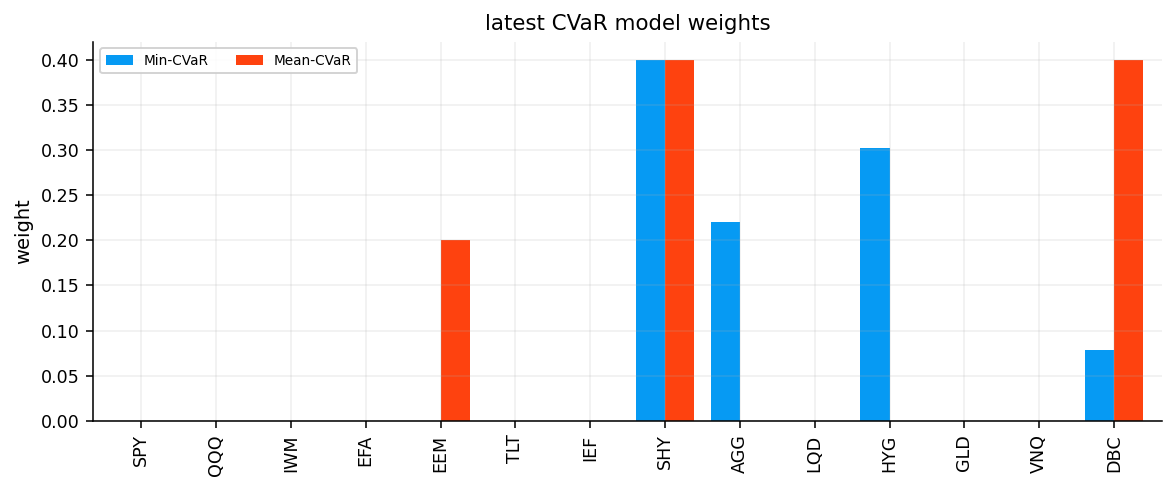

In [17]:
mean_cvar_rows = []
def training_cvar_loss(r, wv):
    loss_values = -r @ wv
    var = float(np.quantile(loss_values, cvar_alpha))
    tail = loss_values[loss_values >= var]
    return float(tail.mean()) if len(tail) else var

def mean_cvar_weight(dt, state, prev_w):
    tickers = list(state["tickers"])
    caps = cap_array(tickers).to_numpy(dtype=float)
    r_train = state["R_cov"].reindex(columns=tickers).astype(float).dropna(how="any")
    r = r_train.to_numpy(dtype=float)
    mu_ann = state["mu_ann_map"][best_maxsharpe_cov][best_maxsharpe_mu].reindex(tickers).fillna(0.0).astype(float)
    ew = np.repeat(1.0 / len(tickers), len(tickers))
    ew_cvar = training_cvar_loss(r, ew)
    t, n = r.shape
    for scale in [0.90, 1.00, 1.10]:
        budget = scale * ew_cvar
        w = cp.Variable(n)
        eta = cp.Variable()
        u = cp.Variable(t)
        losses = -r @ w
        cvar = eta + cp.sum(u) / ((1.0 - cvar_alpha) * t)
        problem = cp.Problem(cp.Maximize(mu_ann.values @ w), [cp.sum(w) == 1.0, w >= 0.0, w <= caps, u >= 0.0, u >= losses - eta, cvar <= budget])
        status = solve_cvx_problem(problem)
        if w.value is not None and status in ["optimal", "optimal_inaccurate"]:
            out = clean_weight_array(w.value, tickers)
            cvar_value = training_cvar_loss(r, out.reindex(tickers).values)
            mean_cvar_rows.append({"date": dt, "ew_cvar_95_loss": ew_cvar, "budget_scale": scale, "cvar_budget": budget, "cvar_95_loss": cvar_value, "mu_ann": float(mu_ann.values @ out.reindex(tickers).values), "status": status})
            return out
    return None
mean_cvar_weights = make_weight_frame_from_func("Mean-CVaR 95", mean_cvar_weight)
mean_cvar_result = backtest_weight_frame("Mean-CVaR 95", mean_cvar_weights)
results["Mean-CVaR 95"] = mean_cvar_result
mean_cvar_diag = pd.DataFrame(mean_cvar_rows).set_index("date")
cvar_table = compact_result_table({"Min-CVaR 95": min_cvar_result, "Mean-CVaR 95": mean_cvar_result})
cvar_latest_weights = pd.concat({"Min-CVaR": min_cvar_weights.iloc[-1], "Mean-CVaR": mean_cvar_weights.iloc[-1]}, axis=1)
display(cvar_table.round(4))
display(mean_cvar_diag[["ew_cvar_95_loss", "budget_scale", "cvar_budget", "cvar_95_loss", "mu_ann"]].tail(5).round(6))
ax = cvar_latest_weights.plot(kind="bar", figsize=(8.5, 3.6), width=0.78)
ax.set_title("latest CVaR model weights")
ax.set_ylabel("weight")
ax.legend(fontsize=7, ncol=2, frameon=True, framealpha=0.85)
plt.tight_layout()
plt.show()


The Mean-CVaR model tests budget scales of 0.90, 1.00, and 1.10 and keeps the first feasible solution in the implementation flow. The displayed recent rows show the 0.90 budget being used in the last months. For example, on 2026-05-29, equal-weight CVaR is about 0.01207, the budget is 0.01086, and the optimized portfolio's CVaR is 0.01084. The model is using almost the full tail budget, which is what we expect from a constrained optimizer. If expected return is being maximized, there is usually no reason to leave a valuable risk budget unused.

The performance comparison between Min-CVaR and Mean-CVaR is the important part:

$$
\text{Min-CVaR Sharpe}=-0.4073
$$

$$
\text{Mean-CVaR Sharpe}=0.5609
$$

Mean-CVaR sacrifices some tail purity, but it becomes a real investment strategy. It earns 9.21% CAGR with 9.55% volatility, historical ES of 1.45%, and max drawdown of -14.61%. This is one of the strongest examples in the project of why risk control needs to be tied to a return objective. A portfolio that only avoids losses can become cash-like. A portfolio that spends a controlled tail budget can still participate in risk premia.

In [18]:
def latest_mean_cvar_budget(scale):
    dt = model_rebalance_dates[-1]
    state = walkforward_grid.cache[dt]
    tickers = list(state["tickers"])
    caps = cap_array(tickers).to_numpy(dtype=float)
    r = state["R_cov"].reindex(columns=tickers).astype(float).dropna(how="any").to_numpy(dtype=float)
    mu_ann = state["mu_ann_map"][best_maxsharpe_cov][best_maxsharpe_mu].reindex(tickers).fillna(0.0).astype(float)
    ew_cvar = training_cvar_loss(r, np.repeat(1.0 / len(tickers), len(tickers)))
    t, n = r.shape
    w = cp.Variable(n)
    eta = cp.Variable()
    u = cp.Variable(t)
    losses = -r @ w
    cvar = eta + cp.sum(u) / ((1.0 - cvar_alpha) * t)
    budget = float(scale) * ew_cvar
    problem = cp.Problem(cp.Maximize(mu_ann.values @ w), [cp.sum(w) == 1.0, w >= 0.0, w <= caps, u >= 0.0, u >= losses - eta, cvar <= budget])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return {"budget_scale": scale, "cvar_budget": budget, "status": status}
    out = clean_weight_array(w.value, tickers)
    return {"budget_scale": scale, "cvar_budget": budget, "expected_ann_return": float(mu_ann.values @ out.reindex(tickers).values), "cvar_95_loss": training_cvar_loss(r, out.reindex(tickers).values), "effective_n": float(1.0 / np.square(out.values).sum()), "max_weight": float(out.max()), "status": status}
latest_cvar_path = pd.DataFrame([latest_mean_cvar_budget(x) for x in [0.80, 0.90, 1.00, 1.10, 1.25]])
display(latest_cvar_path.round(6))


,budget_scale,cvar_budget,expected_ann_return,cvar_95_loss,effective_n,max_weight,status
0,0.80,0.009655,0.000591,0.009634,3.086826,0.4,optimal
1,0.90,0.010861,0.001603,0.010839,2.780100,0.4,optimal
2,1.00,0.012068,0.002401,0.012045,3.008913,0.4,optimal
3,1.10,0.013275,0.003098,0.013250,3.068390,0.4,optimal
4,1.25,0.015085,0.004068,0.015056,2.870796,0.4,optimal


The CVaR budget-path table makes the tradeoff visible. At the latest rebalance, as the budget scale rises from 0.80 to 1.25, the allowed CVaR budget moves from about 0.00966 to 0.01509. The optimized expected annual return rises from about 0.00059 to 0.00407.

The relationship is monotonic in the expected direction:

- More tail budget allows more return-seeking allocations.
- The realized training CVaR stays just below the budget.
- The max-weight constraint remains binding at 40% across the path.
- Effective $N$ stays low, around 2.8 to 3.1, meaning the optimal tail-return tradeoff is still concentrated.

This is a useful diagnostic. If expected return didn't rise when the CVaR budget loosened, then the expected-return estimate wouldn't be giving the optimizer a meaningful direction. Here it does rise, but slowly. The model is saying that within the latest rolling window, buying more expected return requires accepting more left-tail exposure, and the portfolio quickly hits concentration constraints.

For example, if the allowed CVaR budget is very tight, the model has to hold more defensive assets even when their expected return is low. When the budget loosens, it can add assets like GLD, DBC, or equity/credit exposures if their expected-return estimate justifies the extra tail risk.

The budget path is also a small local efficient frontier. Each row answers:

$$
\text{Given this tail budget, what is the highest estimated return we can hold?}
$$

This is different from the classical mean-variance frontier, where the risk constraint is usually volatility:

$$
w^\top\Sigma w \le \sigma_\star^2
$$

Here the risk constraint is tail loss:

$$
CVaR_{0.95}(w) \le B_\star
$$

The difference matters because the two constraints can prefer different assets. A portfolio can have moderate volatility but ugly crash behavior if its losses are skewed or if it loads on assets that gap down together. A CVaR constraint directly limits the average loss inside the historical bad tail.

The latest budget table shows max weight stays at 0.40 across all budget scales. That tells us the cap constraint is binding together with the tail constraint. The optimizer wants to allocate more to the assets that best satisfy return-per-tail-risk, but the max-weight rule prevents unlimited concentration. This is exactly why constraints are part of the model, not just implementation details. In constrained portfolio optimization, the final weights come from the objective **and** the constraint geometry.

## 7) Risk Parity and Risk Contributions

Risk parity takes a different view of diversification. Equal weight gives each asset the same capital weight. Risk parity tries to give each asset, or each sleeve, the same contribution to portfolio risk.

For a portfolio with weights $w$ and covariance matrix $\Sigma$, portfolio variance is:

$$
\sigma_p^2 = w^\top \Sigma w
$$

Portfolio volatility is:

$$
\sigma_p = \sqrt{w^\top \Sigma w}
$$

The marginal contribution of asset $i$ to portfolio volatility is the partial derivative:

$$
\frac{\partial \sigma_p}{\partial w_i} = \frac{(\Sigma w)_i}{\sigma_p}
$$

This derivative tells us how much portfolio volatility would change if we slightly increased asset $i$'s weight. The total risk contribution of asset $i$ is weight times marginal contribution:

$$
RC_i = w_i \frac{(\Sigma w)_i}{\sigma_p}
$$

If we divide by total portfolio volatility, we get the percentage contribution:

$$
PRC_i = \frac{w_i(\Sigma w)_i}{w^\top \Sigma w}
$$

The percentage contributions sum to 1. Risk parity tries to make these contributions equal, or equal across predefined groups:

$$
PRC_i \approx b_i
$$

where $b_i$ is the target risk budget. For equal risk contribution across assets, $b_i=1/N$. For sleeve parity, the target can be equal across sleeves, as this project checks in the diagnostics.

The risk-contribution formula also shows why correlation matters. Expanding the numerator for asset $i$:

$$
(\Sigma w)_i = \sum_{j=1}^{N}\Sigma_{ij}w_j
$$

So asset $i$'s contribution is not based only on its own volatility. It depends on how it covaries with everything else in the portfolio. If an asset has high standalone volatility but negative or low correlation with the rest of the portfolio, its risk contribution can be lower than its standalone volatility suggests. If a low-volatility asset is highly correlated with the largest portfolio positions, its contribution can be larger than expected.

This is why risk parity is a portfolio-level concept. We don't equalize individual volatilities. We equalize each asset's contribution to the portfolio's total volatility. The covariance terms decide how much each asset adds to the combined risk.

A two-asset example makes this clear. With weights $w_1,w_2$, volatilities $\sigma_1,\sigma_2$, and correlation $\rho$, portfolio variance is:

$$
\sigma_p^2 = w_1^2\sigma_1^2+w_2^2\sigma_2^2+2w_1w_2\rho\sigma_1\sigma_2
$$

When $\rho$ is high, diversification is weak and the higher-volatility asset usually needs much lower capital weight. When $\rho$ is low or negative, the same asset can receive more weight because it doesn't add as much total portfolio risk.

### 7.1 Why Risk Parity Often Holds More Bonds

Risk parity is easy to misunderstand if we only look at weights. Low-volatility assets often receive large capital weights because they need more dollars to contribute the same risk.

Suppose Asset A has 20% volatility and Asset B has 5% volatility. If they are weakly correlated, a 10% weight in A can contribute similar volatility risk to a 40% weight in B. So a risk parity portfolio may look "bond heavy" or "SHY heavy", but that doesn't mean it is trying to maximize bond exposure. It is trying to equalize the volatility contribution.

The model solves this kind of target indirectly by minimizing the gap between actual risk contributions and target risk contributions. In simplified form:

$$
\min_w \sum_{i=1}^{N}\left(PRC_i(w)-b_i\right)^2
$$

subject to the usual portfolio constraints. The exact numerical implementation can be different, but the target is the same: distribute risk contribution rather than distribute capital equally.

In this project, we also inspect sleeve-level risk contribution. The sleeve contribution for group $g$ is the sum of asset contributions inside that group:

$$
PRC_g = \sum_{i \in g} PRC_i
$$

This is useful because a portfolio can have equal asset-level contributions but still load too much on one economic sleeve if several correlated assets belong to the same sleeve.

,Risk Parity
SHY,0.2827
HYG,0.1453
LQD,0.1057
AGG,0.0881
IEF,0.0725
VNQ,0.0576
DBC,0.0555
GLD,0.0423
TLT,0.0371
EFA,0.0262


,percent_risk_contribution
equities,0.2483
duration,0.2532
credit,0.2499
diversifiers,0.2486


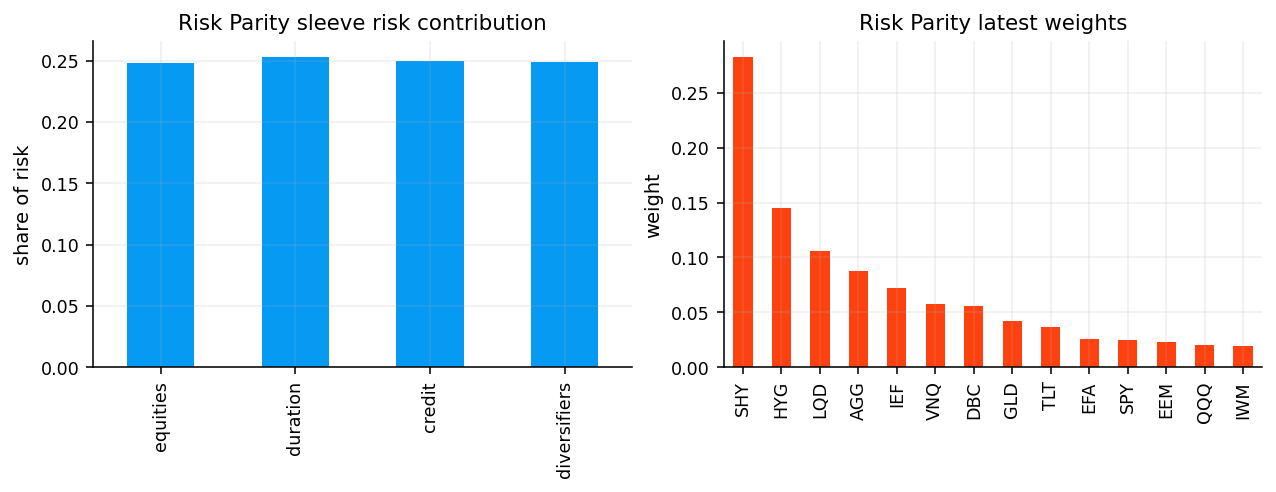

,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Risk Parity,0.0453,0.0492,0.132,0.1649,-0.1374,0.3295,0.0131,1.6326,0.0012,5.9635,0.3498


In [19]:
def erc_vector(cov_arr, upper=None):
    cov = make_psd(np.asarray(cov_arr, dtype=float), eps=1e-10)
    n = cov.shape[0]
    cap = np.ones(n, dtype=float) if upper is None else np.asarray(upper, dtype=float)
    if cap.size != n or float(cap.sum()) < 1.0:
        cap = np.ones(n, dtype=float)
    x0 = np.minimum(np.ones(n, dtype=float) / n, cap)
    x0 = x0 / float(x0.sum())
    bounds = [(0.0, float(c)) for c in cap]
    cons = {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
    def objective(w):
        sigma_w = cov @ w
        port_vol = math.sqrt(max(float(w @ sigma_w), 1e-18))
        rc = w * sigma_w / port_vol
        return float(np.sum((rc - port_vol / n) ** 2))
    res = opt.minimize(objective, x0, method="SLSQP", bounds=bounds, constraints=cons, options={"maxiter": 700, "ftol": 1e-12})
    if not res.success or not np.all(np.isfinite(res.x)):
        return x0
    return clean_weight_array(res.x, range(n), cap).values

def sleeve_risk_parity_weight(dt, state, prev_w):
    tickers = list(state["tickers"])
    r_train = state["R_cov"].reindex(columns=tickers).astype(float).dropna(how="any")
    cov_ann = pd.DataFrame(make_psd(np.asarray(state["cov_ann_map"][best_minvar_cov], dtype=float), eps=1e-10), index=tickers, columns=tickers)
    sleeve_inner = {}
    sleeve_returns = {}
    sleeve_names = []
    for sleeve, names in sleeve_groups.items():
        names = [name for name in names if name in tickers]
        if not names:
            continue
        sub_cov = cov_ann.loc[names, names].values
        inner = pd.Series(erc_vector(sub_cov), index=names, dtype=float)
        sleeve_inner[sleeve] = inner
        sleeve_returns[sleeve] = r_train[names] @ inner.reindex(names).values
        sleeve_names.append(sleeve)
    sleeve_frame = pd.DataFrame(sleeve_returns).dropna(how="any")
    if sleeve_frame.shape[1] < 2:
        return None
    sleeve_cov = sleeve_frame.cov().values * annualization
    sleeve_w = pd.Series(erc_vector(sleeve_cov), index=sleeve_names, dtype=float)
    final = pd.Series(0.0, index=tickers, dtype=float)
    for sleeve in sleeve_names:
        final.loc[sleeve_inner[sleeve].index] = sleeve_w.loc[sleeve] * sleeve_inner[sleeve]
    return clean_weight_array(final, tickers)
rp_weights = make_weight_frame_from_func("Risk Parity", sleeve_risk_parity_weight)
rp_result = backtest_weight_frame("Risk Parity", rp_weights)
results["Risk Parity"] = rp_result
latest_rp_state = walkforward_grid.cache[model_rebalance_dates[-1]]
latest_rp_cov = pd.DataFrame(make_psd(latest_rp_state["cov_ann_map"][best_minvar_cov], eps=1e-10), index=assets, columns=assets)
latest_rp_w = rp_weights.iloc[-1].reindex(assets).fillna(0.0)
asset_rc = attribution.risk_contribution(latest_rp_w, latest_rp_cov.loc[assets, assets], tickers=assets)
sleeve_rc = pd.Series({sleeve: asset_rc.reindex(names).fillna(0.0).sum() for sleeve, names in sleeve_groups.items()})
sleeve_rc = sleeve_rc / float(sleeve_rc.sum())
display(latest_rp_w.sort_values(ascending=False).to_frame("Risk Parity").round(4))
display(sleeve_rc.to_frame("percent_risk_contribution").round(4))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)
sleeve_rc.plot(kind="bar", ax=axes[0], color=colors[0])
axes[0].set_title("Risk Parity sleeve risk contribution")
axes[0].set_ylabel("share of risk")
latest_rp_w.sort_values(ascending=False).plot(kind="bar", ax=axes[1], color=colors[1])
axes[1].set_title("Risk Parity latest weights")
axes[1].set_ylabel("weight")
plt.show()
display(compact_result_table({"Risk Parity": rp_result}).round(4))


The latest risk parity output shows the model strongly prefers low-volatility fixed-income assets:

- SHY gets about 34.98%.
- AGG gets about 11.18%.
- LQD gets about 9.87%.
- IEF, VNQ, DBC, GLD, TLT, EFA, SPY, EEM, QQQ, and IWM receive smaller weights.

The sleeve risk contribution table is the most important output here. It shows roughly equal risk contribution across the four sleeves:

$$
\text{equities}=24.83\%, \quad \text{duration}=25.32\%, \quad \text{credit}=24.99\%, \quad \text{diversifiers}=24.86\%
$$

This is exactly the target behavior. The capital weights are not equal, but the sleeve risk contributions are nearly equal. That means the optimizer is succeeding at the risk-budgeting problem.

The performance is defensive. Risk Parity has 4.53% CAGR, 4.92% annualized volatility, 0.132 Sharpe, -13.74% max drawdown, and historical ES of 0.73%. Its main strength is risk control, not return. This model becomes a tail-control benchmark: if another model has much higher return but also much higher ES, we can see the cost of buying that return.

## 8) Hierarchical Risk Parity

HRP, or Hierarchical Risk Parity, starts from a different idea: assets shouldn't be allocated as if all correlations are equally important. The first step is to understand which assets naturally cluster together.

The model converts correlation into a distance:

$$
d_{ij} = \sqrt{\frac{1-\rho_{ij}}{2}}
$$

where $\rho_{ij}$ is the correlation between assets $i$ and $j$. This distance has useful properties:

- If two assets are perfectly correlated, $\rho_{ij}=1$, then $d_{ij}=0$.
- If two assets are uncorrelated, $\rho_{ij}=0$, then $d_{ij}=\sqrt{1/2}$.
- If two assets are perfectly negatively correlated, $\rho_{ij}=-1$, then $d_{ij}=1$.

The clustering algorithm uses these distances to build a tree. Assets that move together are placed near each other. Once the tree is built, HRP orders the covariance matrix according to the tree structure and recursively splits the ordered list into clusters. At each split, it allocates more weight to the lower-risk cluster.

For a cluster $C$, the cluster variance is estimated using an inverse-variance portfolio inside the cluster:

$$
w_i^{(C)} = \frac{1/\sigma_i^2}{\sum_{j\in C}1/\sigma_j^2}
$$

$$
\sigma_C^2 = (w^{(C)})^\top \Sigma_C w^{(C)}
$$

If a parent cluster is split into left and right subclusters with variances $\sigma_L^2$ and $\sigma_R^2$, the lower-variance side receives more capital. The recursive process continues until weights are assigned to individual assets.

,HRP
SHY,0.4000
HYG,0.1317
AGG,0.0711
IEF,0.0555
LQD,0.0518
DBC,0.0416
VNQ,0.0381
EFA,0.0356
GLD,0.0346
TLT,0.0301


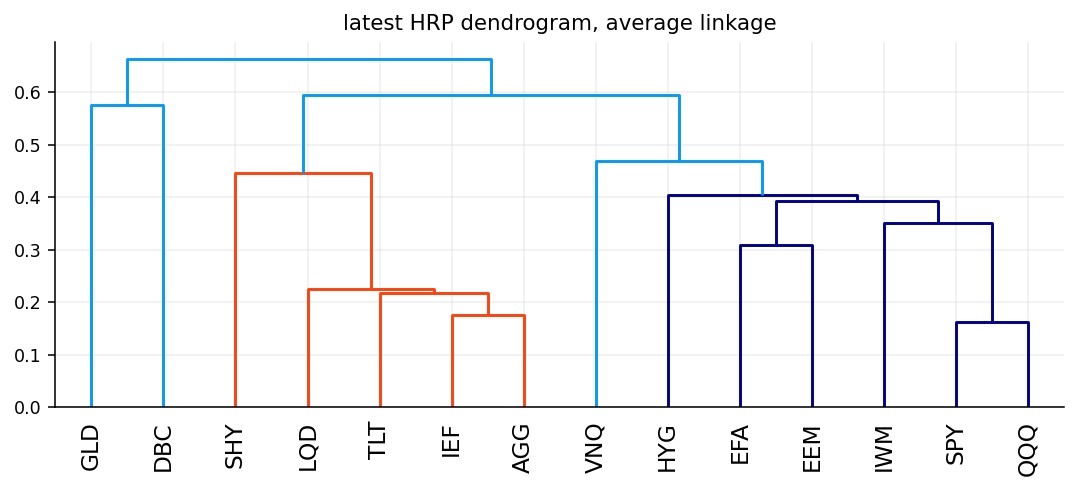

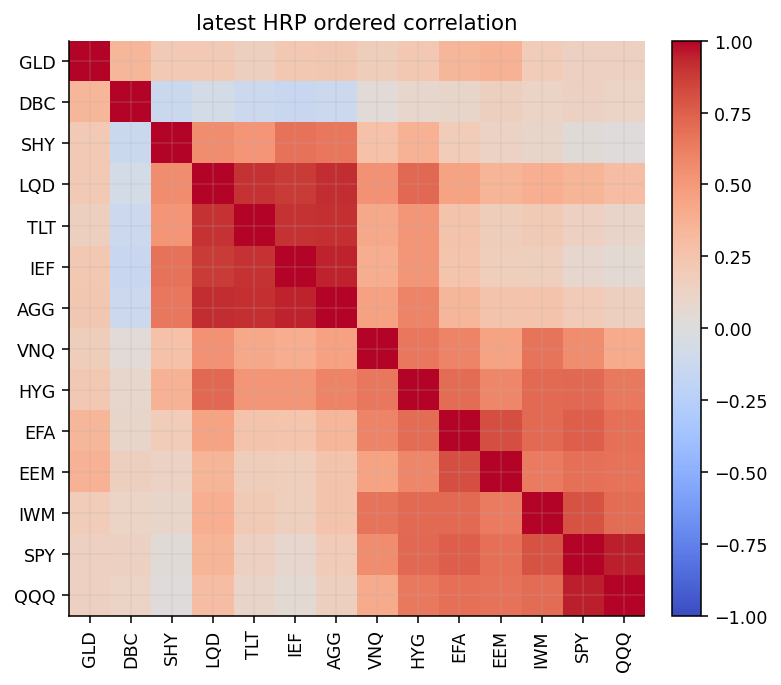

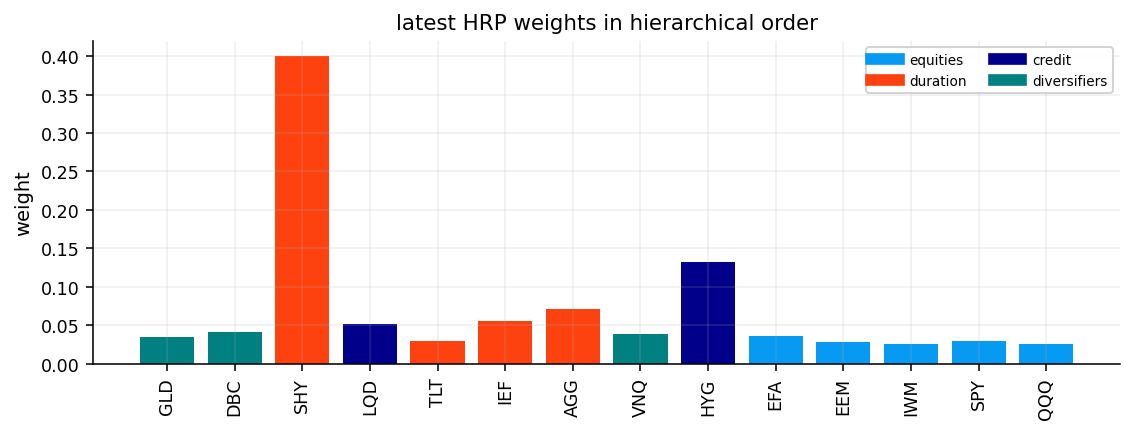

In [20]:
def corr_distance_link(cov_ann, method="average"):
    cov = pd.DataFrame(cov_ann).astype(float)
    diag = np.sqrt(np.maximum(np.diag(cov.values), 1e-12))
    corr = cov.values / np.outer(diag, diag)
    corr = np.clip(np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0), -1.0, 1.0)
    np.fill_diagonal(corr, 1.0)
    distance = np.sqrt(np.clip((1.0 - corr) / 2.0, 0.0, 1.0))
    link = hierarchy.linkage(squareform(distance, checks=False), method=method)
    return corr, distance, link

def cluster_variance(cov, items):
    sub = cov[np.ix_(items, items)]
    diag = np.maximum(np.diag(sub), 1e-12)
    ivp = 1.0 / diag
    ivp = ivp / ivp.sum()
    return float(ivp @ sub @ ivp)

def hrp_allocation(cov_ann, tickers):
    cov = make_psd(np.asarray(cov_ann, dtype=float), eps=1e-10)
    corr, distance, link = corr_distance_link(cov, method="average")
    order = list(hierarchy.leaves_list(link))
    alloc = pd.Series(0.0, index=range(len(tickers)), dtype=float)
    def split(items, weight):
        if len(items) == 1:
            alloc.loc[items[0]] += weight
            return
        k = len(items) // 2
        left, right = items[:k], items[k:]
        left_var = cluster_variance(cov, left)
        right_var = cluster_variance(cov, right)
        left_weight = right_var / (left_var + right_var) if left_var + right_var > 1e-18 else 0.5
        split(left, weight * left_weight)
        split(right, weight * (1.0 - left_weight))
    split(order, 1.0)
    return clean_weight_array(pd.Series(alloc.values, index=tickers, dtype=float), tickers), corr, link, order

def hrp_weight(dt, state, prev_w):
    weights, corr, link, order = hrp_allocation(state["cov_ann_map"][best_minvar_cov], list(state["tickers"]))
    return weights
hrp_weights = make_weight_frame_from_func("HRP", hrp_weight)
hrp_result = backtest_weight_frame("HRP", hrp_weights)
results["HRP"] = hrp_result
latest_hrp_state = walkforward_grid.cache[model_rebalance_dates[-1]]
latest_hrp_weights, latest_hrp_corr, latest_hrp_link, latest_hrp_order = hrp_allocation(latest_hrp_state["cov_ann_map"][best_minvar_cov], assets)
display(hrp_weights.iloc[-1].sort_values(ascending=False).to_frame("HRP").round(4))
fig, ax = plt.subplots(figsize=(7.8, 3.6))
hierarchy.dendrogram(latest_hrp_link, labels=assets, leaf_rotation=90, ax=ax)
ax.set_title("latest HRP dendrogram, average linkage")
plt.tight_layout()
plt.show()
ordered_assets = [assets[i] for i in latest_hrp_order]
fig, ax = plt.subplots(figsize=(5.8, 5.0))
im = ax.imshow(pd.DataFrame(latest_hrp_corr, index=assets, columns=assets).loc[ordered_assets, ordered_assets], cmap="coolwarm", vmin=-1.0, vmax=1.0)
ax.set_title("latest HRP ordered correlation")
ax.set_xticks(range(len(ordered_assets)), ordered_assets, rotation=90)
ax.set_yticks(range(len(ordered_assets)), ordered_assets)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
hrp_ordered_weights = hrp_weights.iloc[-1].reindex(ordered_assets).fillna(0.0)
sleeve_color = {sleeve: colors[i] for i, sleeve in enumerate(sleeve_groups)}
bar_colors = [sleeve_color.get(sleeve_map.get(asset, "other"), colors[0]) for asset in ordered_assets]
fig, ax = plt.subplots(figsize=(8.2, 3.2))
ax.bar(hrp_ordered_weights.index, hrp_ordered_weights.values, color=bar_colors)
ax.set_title("latest HRP weights in hierarchical order")
ax.set_ylabel("weight")
ax.tick_params(axis="x", rotation=90)
handles = [plt.Line2D([0], [0], color=sleeve_color[sleeve], lw=6) for sleeve in sleeve_groups]
ax.legend(handles, list(sleeve_groups), fontsize=7, ncol=2, frameon=True, framealpha=0.85)
plt.tight_layout()
plt.show()


The latest HRP dendrogram and ordered-correlation heatmap show the cross-asset structure clearly. Duration and bond-like assets cluster together, equity and credit-like assets cluster together, and diversifiers form their own partial grouping. This is economically sensible because the model isn't told those labels directly. It sees them through correlation.

The latest HRP weights are extremely defensive:

- SHY receives the cap at 40%.
- HYG receives 13.17%.
- AGG receives 7.11%.
- IEF and LQD receive around 5%.
- Equity ETFs receive small weights.

The cap on SHY matters here. HRP sees SHY as a low-risk cluster anchor, and without a cap it would likely receive even more. This is one of the practical issues with HRP in a cross-asset ETF universe: if the universe contains near-cash instruments, hierarchical allocation can become too defensive unless the constraints prevent it.

The HRP backtest has 5.19% CAGR, 5.04% volatility, 0.2547 Sharpe, -14.46% max drawdown, and ES of 0.75%. It improves tail behavior compared with aggressive models, but it doesn't earn enough return to compete with BL, MaxSharpe, Mean-CVaR, or robust MV.

The HRP allocation process can be understood as a sequence of local decisions. At each branch of the tree, we ask how risky the left cluster is relative to the right cluster. If the left cluster has variance $\sigma_L^2$ and the right cluster has variance $\sigma_R^2$, the allocation to the left side is proportional to the inverse of its cluster variance:

$$
\alpha_L = \frac{1/\sigma_L^2}{1/\sigma_L^2+1/\sigma_R^2}
$$

which can also be written as:

$$
\alpha_L = \frac{\sigma_R^2}{\sigma_L^2+\sigma_R^2}
$$

So if the left cluster is much safer than the right cluster, $\sigma_L^2$ is small and $\alpha_L$ is large. The safer cluster receives more capital. This is repeated down the tree until every asset has a final weight.

This recursive structure is why HRP can be stable. It doesn't invert the full covariance matrix in the same way a mean-variance optimizer does. Instead, it uses the hierarchy to break the problem into smaller allocation decisions. The cost is that HRP doesn't directly optimize expected return, and in a universe with very low-volatility assets it can become heavily defensive.

## 9) Nested Clustered Optimization

NCO, or Nested Clustered Optimization, uses clustering like HRP but doesn't stop at recursive bisection. It treats each cluster as a sub-portfolio and then optimizes across those cluster portfolios.

The workflow is:

1. Use the correlation distance matrix to cluster the assets.
2. Solve an **inner optimization** inside each cluster.
3. Treat each cluster portfolio as one synthetic asset.
4. Solve an **outer optimization** across the cluster portfolios.
5. Multiply outer cluster weights by inner asset weights to get final asset weights.

If cluster $g$ contains assets in index set $C_g$, the inner weights are:

$$
w_g^{\text{inner}} \in \mathbb{R}^{|C_g|}
$$

The cluster return forecast is:

$$
\mu_g^{\text{cluster}} = (w_g^{\text{inner}})^\top \mu_{C_g}
$$

The covariance between clusters $g$ and $h$ is:

$$
\Sigma_{g,h}^{\text{cluster}} = (w_g^{\text{inner}})^\top \Sigma_{C_g,C_h} w_h^{\text{inner}}
$$

Then the outer optimizer chooses cluster weights $a_g$. The final asset weight for asset $i$ in cluster $g$ is:

$$
w_i = a_g \cdot w_{g,i}^{\text{inner}}
$$

This structure is useful because it prevents one large correlated group from dominating the optimizer asset-by-asset. The optimizer first decides how much risk/return to allocate to clusters, then distributes inside each cluster.

NCO is more optimization-heavy than HRP, so its result depends more on the quality of the mean estimate. Inside each cluster, the inner optimizer decides which assets represent that cluster best. Then the outer optimizer decides how much capital each cluster gets.

A compact matrix view is:

$$
W_{\text{inner}} =
\begin{bmatrix}
| & | & & | \\
w_1^{\text{inner}} & w_2^{\text{inner}} & \cdots & w_G^{\text{inner}} \\
| & | & & |
\end{bmatrix}
$$

where each column is a cluster portfolio placed in the full asset space, with zeros outside its cluster. If $a\in\mathbb{R}^G$ is the vector of outer cluster weights, then the final asset portfolio is:

$$
w = W_{\text{inner}}a
$$

The cluster-level expected return vector is:

$$
\mu^{(G)} = W_{\text{inner}}^\top \mu
$$

and the cluster-level covariance matrix is:

$$
\Sigma^{(G)} = W_{\text{inner}}^\top \Sigma W_{\text{inner}}
$$

Then the outer optimizer solves a smaller portfolio problem over $G$ cluster portfolios instead of $N$ individual assets. This can reduce instability when $N$ is large or when assets are strongly correlated. In this project, $N=14$, so the dimensionality benefit is modest. The bigger question is whether the clustering creates a better economic structure. In the results, HRP's simpler structure wins.

,asset,cluster
13,DBC,1
11,GLD,1
8,AGG,2
6,IEF,2
9,LQD,2
7,SHY,2
5,TLT,2
4,EEM,3
3,EFA,3
10,HYG,3


,NCO-MV
SHY,0.2400
AGG,0.2400
GLD,0.1223
DBC,0.1223
IEF,0.1200
HYG,0.0622
EEM,0.0301
VNQ,0.0256
SPY,0.0215
EFA,0.0161


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
HRP,0.0519,0.0504,0.2547,0.3247,-0.1446,0.3586,0.0186,2.3204,0.0017,5.0967,0.4000
NCO-MV,0.0519,0.0636,0.2128,0.2538,-0.1509,0.3435,0.1645,20.5595,0.0155,5.7432,0.2467


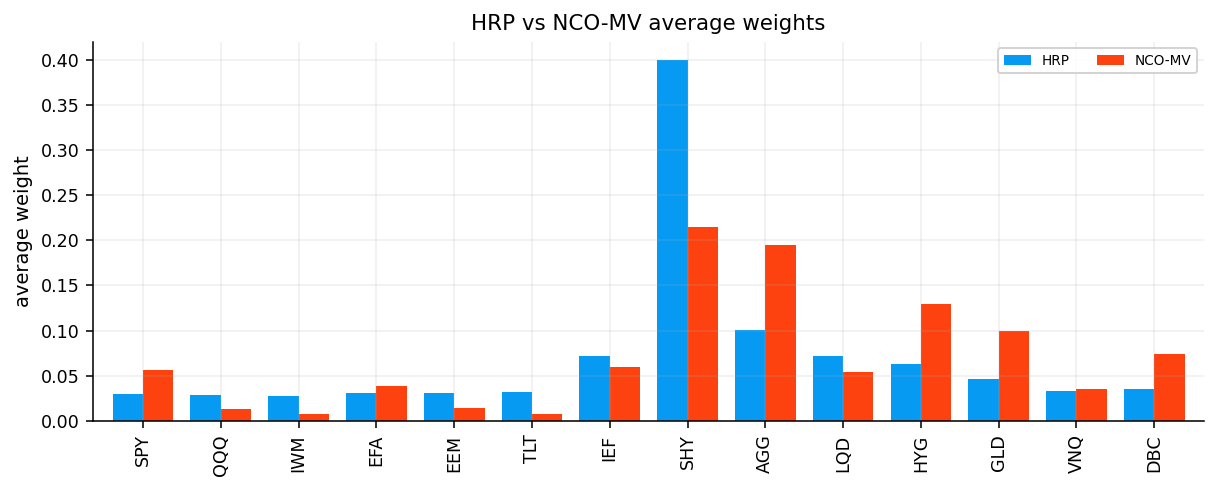

,assets,cluster_weight,forecast_return,standalone_vol
cluster,,,,
1,"GLD, DBC",0.2445,0.0050,0.1487
2,"TLT, IEF, SHY, AGG, LQD",0.6000,-0.0077,0.0407
3,"SPY, QQQ, IWM, EFA, EEM, HYG, VNQ",0.1555,-0.0032,0.1021


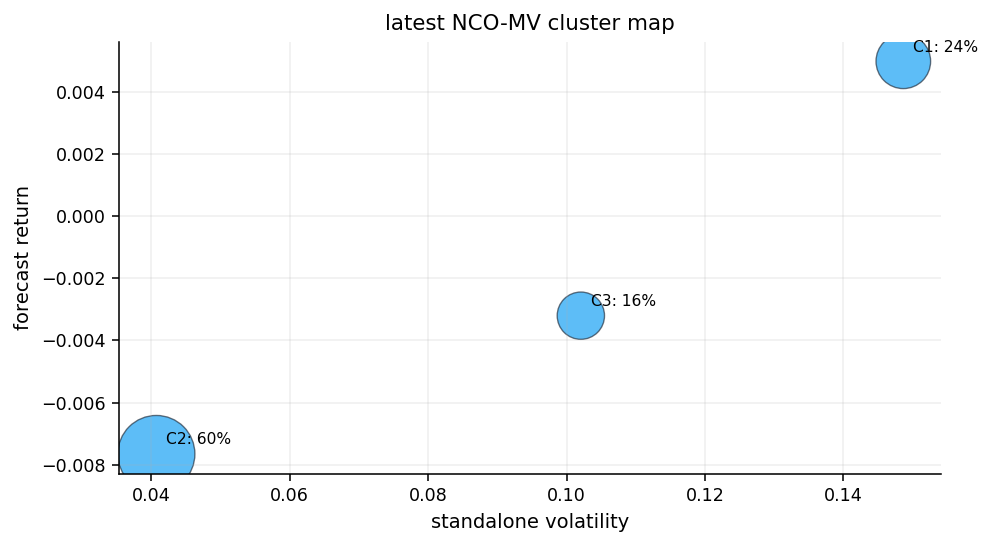

In [21]:
def solve_mv_vector(mu_arr, cov_arr, cap=0.40, lam=3.0):
    mu = np.asarray(mu_arr, dtype=float).reshape(-1)
    cov = make_psd(np.asarray(cov_arr, dtype=float), eps=1e-10)
    n = len(mu)
    cap_value = max(float(cap), 1.0 / n)
    caps = np.repeat(cap_value, n)
    w = cp.Variable(n)
    problem = cp.Problem(cp.Maximize(mu @ w - 0.5 * float(lam) * cp.quad_form(w, cp.psd_wrap(cov))), [cp.sum(w) == 1.0, w >= 0.0, w <= caps])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return clean_weight_array(np.ones(n, dtype=float), range(n), caps).values
    return clean_weight_array(w.value, range(n), caps).values

def nco_labels_from_cov(cov_ann, n_clusters=3):
    cov = make_psd(np.asarray(cov_ann, dtype=float), eps=1e-10)
    corr, distance, link = corr_distance_link(cov, method="average")
    labels = hierarchy.fcluster(link, t=int(n_clusters), criterion="maxclust")
    return labels, link

def nco_weight(dt, state, prev_w):
    tickers = list(state["tickers"])
    cov_ann = make_psd(np.asarray(state["cov_ann_map"][best_maxsharpe_cov], dtype=float), eps=1e-10)
    mu_ann = state["mu_ann_map"][best_maxsharpe_cov][best_maxsharpe_mu].reindex(tickers).fillna(0.0).astype(float)
    r_train = state["R_cov"].reindex(columns=tickers).astype(float).dropna(how="any")
    labels, link = nco_labels_from_cov(cov_ann, n_clusters=3)
    cluster_ids = sorted(pd.unique(labels))
    inner = {}
    cluster_returns = {}
    cluster_mu = []
    for cid in cluster_ids:
        locs = np.where(labels == cid)[0]
        names = [tickers[i] for i in locs]
        inner_cap = max(w_max, 1.0 / len(names))
        w_in = solve_mv_vector(mu_ann.reindex(names).values, cov_ann[np.ix_(locs, locs)], cap=inner_cap, lam=3.0)
        inner[cid] = pd.Series(w_in, index=names, dtype=float)
        cluster_returns[cid] = r_train[names] @ inner[cid].reindex(names).values
        cluster_mu.append(float(mu_ann.reindex(names).values @ inner[cid].reindex(names).values))
    cluster_frame = pd.DataFrame(cluster_returns).dropna(how="any")
    if cluster_frame.shape[1] < 2:
        return None
    cluster_cov = cluster_frame.cov().values * annualization
    outer = solve_mv_vector(np.asarray(cluster_mu, dtype=float), cluster_cov, cap=0.60, lam=3.0)
    final = pd.Series(0.0, index=tickers, dtype=float)
    for j, cid in enumerate(cluster_ids):
        final.loc[inner[cid].index] = outer[j] * inner[cid]
    return clean_weight_array(final, tickers)
nco_weights = make_weight_frame_from_func("NCO-MV", nco_weight)
nco_result = backtest_weight_frame("NCO-MV", nco_weights)
results["NCO-MV"] = nco_result
latest_nco_labels, latest_nco_link = nco_labels_from_cov(latest_hrp_state["cov_ann_map"][best_maxsharpe_cov], n_clusters=3)
cluster_membership = pd.DataFrame({"asset": assets, "cluster": latest_nco_labels}).sort_values(["cluster", "asset"])
hier_avg_weights = pd.concat({"HRP": hrp_weights.mean(), "NCO-MV": nco_weights.mean()}, axis=1).reindex(assets)
display(cluster_membership)
display(nco_weights.iloc[-1].sort_values(ascending=False).to_frame("NCO-MV").round(4))
display(compact_result_table({"HRP": hrp_result, "NCO-MV": nco_result}).round(4))
ax = hier_avg_weights.plot(kind="bar", figsize=(8.8, 3.6), width=0.78)
ax.set_title("HRP vs NCO-MV average weights")
ax.set_ylabel("average weight")
ax.legend(fontsize=7, ncol=2, frameon=True, framealpha=0.85)
plt.tight_layout()
plt.show()
latest_nco_state = walkforward_grid.cache[model_rebalance_dates[-1]]
latest_nco_cov = make_psd(np.asarray(latest_nco_state["cov_ann_map"][best_maxsharpe_cov], dtype=float), eps=1e-10)
latest_nco_mu = latest_nco_state["mu_ann_map"][best_maxsharpe_cov][best_maxsharpe_mu].reindex(assets).fillna(0.0).astype(float)
latest_nco_w = nco_weights.iloc[-1].reindex(assets).fillna(0.0)
nco_cluster_rows = []
for cid in sorted(pd.unique(latest_nco_labels)):
    names = [asset for asset, label in zip(assets, latest_nco_labels) if label == cid]
    weight = float(latest_nco_w.reindex(names).sum())
    if weight > 1e-12:
        within = latest_nco_w.reindex(names).fillna(0.0) / weight
    else:
        within = pd.Series(1.0 / len(names), index=names, dtype=float)
    locs = [assets.index(name) for name in names]
    sub_cov = latest_nco_cov[np.ix_(locs, locs)]
    vol = float(math.sqrt(max(within.values @ sub_cov @ within.values, 0.0)))
    ret = float(latest_nco_mu.reindex(names).values @ within.values)
    nco_cluster_rows.append({"cluster": int(cid), "assets": ", ".join(names), "cluster_weight": weight, "forecast_return": ret, "standalone_vol": vol})
nco_cluster_stats = pd.DataFrame(nco_cluster_rows).set_index("cluster")
display(nco_cluster_stats.round(4))
fig, ax = plt.subplots(figsize=(7.2, 4.0))
sizes = 250 + 2200 * nco_cluster_stats["cluster_weight"].clip(lower=0.02)
ax.scatter(nco_cluster_stats["standalone_vol"], nco_cluster_stats["forecast_return"], s=sizes, color=colors[0], alpha=0.65, edgecolor="#1f2937", linewidth=0.7)
for cid, row in nco_cluster_stats.iterrows():
    ax.annotate(f"C{cid}: {row['cluster_weight']:.0%}", (row["standalone_vol"], row["forecast_return"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_title("latest NCO-MV cluster map")
ax.set_xlabel("standalone volatility")
ax.set_ylabel("forecast return")
plt.tight_layout()
plt.show()


The latest NCO cluster table is economically clean:

- Cluster 1: GLD and DBC, the real-asset/diversifier group.
- Cluster 2: TLT, IEF, SHY, AGG, LQD, the duration and investment-grade bond group.
- Cluster 3: SPY, QQQ, IWM, EFA, EEM, HYG, VNQ, the equity/credit/risky group.

The latest NCO weights allocate 60% to the bond cluster, 24.45% to the GLD/DBC cluster, and 15.55% to the risky cluster. Within the bond cluster, SHY and AGG each hit 24% in the latest output, while TLT and LQD get zero. Within the real-asset cluster, GLD and DBC split the allocation.

The cluster map makes the same point visually. The bond cluster has the lowest standalone volatility but a negative forecast return. The diversifier cluster has a higher forecast return and higher volatility. The risky cluster has medium volatility but also a negative forecast in the latest window. The optimizer therefore places most weight in the low-vol bond cluster and keeps a meaningful diversifier sleeve.

In the backtest, NCO-MV has the same CAGR as HRP, 5.19%, but higher volatility at 6.36% and lower Sharpe at 0.2128. It also has much higher turnover, 16.45% average monthly turnover versus 1.86% for HRP. That makes HRP the better hierarchical model in this application.

In [22]:
hier_summary = compact_result_table({"HRP": hrp_result, "NCO-MV": nco_result})
best_hier_name = hier_summary.sort_values(["sharpe", "max_drawdown", "avg_turnover", "cagr"], ascending=[False, False, True, False]).index[0]
print("selected hierarchical model:", best_hier_name)
display(hier_summary.round(4))


selected hierarchical model: HRP


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
HRP,0.0519,0.0504,0.2547,0.3247,-0.1446,0.3586,0.0186,2.3204,0.0017,5.0967,0.4000
NCO-MV,0.0519,0.0636,0.2128,0.2538,-0.1509,0.3435,0.1645,20.5595,0.0155,5.7432,0.2467


The selected hierarchical model is HRP because it has higher Sharpe, better drawdown behavior, and much lower turnover than NCO-MV. This doesn't mean NCO is theoretically weak. It means that in this cross-asset universe and sample, the extra optimization layer didn't create enough return to justify the additional turnover and risk.

The HRP versus NCO comparison is useful because it separates two ideas:

- **Clustering** helps us understand portfolio structure.
- **Optimizing inside and across clusters** can add return-seeking behavior, but it can also reintroduce mean-estimation risk.

HRP mostly avoids expected-return forecasts. NCO uses them. When the expected-return signal is noisy or when the universe has a very defensive low-volatility cluster, the NCO optimizer can still become unstable. HRP is simpler and slower-moving, which is exactly why it wins the hierarchical selection here.

## 10) Robust Optimization: Estimation Error as a Portfolio Risk

Robust optimization is the most important conceptual block in this project. The starting point is that $\hat{\mu}$ is an estimate, not the truth. In mean-variance optimization, small changes in $\hat{\mu}$ can cause large changes in weights, especially when the covariance matrix has correlated assets and the optimizer is trying to rank similar opportunities.

A standard mean-variance objective is:

$$
\max_w\; \hat{\mu}^\top w - \frac{\lambda}{2}w^\top\hat{\Sigma}w
$$

where $\lambda$ controls risk aversion. The problem is that the optimizer behaves as if $\hat{\mu}$ is exact. Robust optimization changes the objective to say: choose a portfolio that still looks acceptable under a bad but plausible version of the expected-return vector.

The general robust form is:

$$
\max_w\; \min_{\mu \in \mathcal{U}} \left(\mu^\top w - \frac{\lambda}{2}w^\top\Sigma w\right)
$$

where $\mathcal{U}$ is an uncertainty set around the estimated mean vector. The inner minimization is the adversary. It asks: if the true expected return is somewhere inside this plausible set, which version hurts the chosen portfolio the most?

This turns estimation uncertainty into a direct cost. A portfolio with large exposure to uncertain return forecasts gets penalized more than a portfolio whose expected return is more reliable.

Expected-return uncertainty is usually more damaging than covariance uncertainty. A rough reason is that portfolio variance is quadratic and constrained by $\Sigma$, while expected return enters linearly:

$$
\hat{\mu}^\top w
$$

If one asset's expected return estimate is too high by only a few percent annualized, a mean-variance optimizer may allocate heavily to it because the linear reward looks attractive. The optimizer doesn't know that the estimate is noisy. It just sees a higher number.

The sampling error of a mean estimate is also large. For asset $i$, if daily returns have volatility $\sigma_i$ and the mean is estimated from $T$ independent observations, the standard error is approximately:

$$
SE(\hat{\mu}_i) \approx \frac{\sigma_i}{\sqrt{T}}
$$

After annualization, the uncertainty can still be large relative to the expected return itself. If an asset has an annual expected return estimate of 5% but the standard error is also several percent, the sign and rank of the forecast are not very reliable.

Robust optimization makes this uncertainty explicit. Instead of pretending $\hat{\mu}$ is the truth, it asks the optimizer to survive a pessimistic adjustment to $\hat{\mu}$. The stronger the uncertainty set, the less the optimizer can exploit fragile forecast differences.

### 10.1 Box Uncertainty

The first robust model uses a box uncertainty set. Each expected return can move independently within a range:

$$
\mathcal{U}_{\text{box}} = \left\{\mu : |\mu_i-\hat{\mu}_i| \le \rho s_i,\; i=1,\ldots,N \right\}
$$

Here:

- $\hat{\mu}_i$ is the estimated annualized expected return of asset $i$.
- $s_i$ is the standard error of that return estimate.
- $\rho$ is the radius of the uncertainty box.
- Larger $\rho$ means we trust the mean estimate less.

For a long-only portfolio, the worst-case mean is simple. The adversary lowers every asset's expected return by its uncertainty allowance:

$$
\mu_i^{\text{worst}} = \hat{\mu}_i - \rho s_i
$$

So the robust return becomes:

$$
(\mu^{\text{worst}})^\top w = \sum_{i=1}^{N}(\hat{\mu}_i-\rho s_i)w_i
$$

The optimization is then:

$$
\max_w\; (\hat{\mu}-\rho s)^\top w - \frac{\lambda}{2}w^\top\Sigma w
$$

subject to the portfolio constraints.

The box model is intuitive and easy to explain: every asset's forecast return is haircut by its own estimation uncertainty before the optimizer sees it. Assets with noisy high returns lose more of their appeal.

For a long-only portfolio, the box robust derivation is especially simple. The worst-case return is:

$$
\min_{\mu_i\in[\hat{\mu}_i-\rho s_i,\hat{\mu}_i+\rho s_i]}\sum_{i=1}^{N}\mu_i w_i
$$

Since every $w_i\ge 0$, the adversary lowers every $\mu_i$ to its lower bound. So:

$$
\min_{\mu\in\mathcal{U}_{\text{box}}}\mu^\top w = \sum_{i=1}^{N}(\hat{\mu}_i-\rho s_i)w_i
$$

If shorting were allowed, the adversary would behave differently. For a negative weight, lowering $\mu_i$ would help the portfolio, so the adversary would raise $\mu_i$ instead. The general penalty would involve $|w_i|$:

$$
\hat{\mu}^\top w - \rho\sum_{i=1}^{N}s_i|w_i|
$$

Because this project is long-only, the simpler haircut form is enough. This is also why box robustness can be interpreted as **forecast haircutting**. We create a conservative expected-return vector first, then run a standard constrained mean-variance optimizer on that conservative vector.

The box radius controls how skeptical we are. If $\rho=0$, the model becomes standard MV. If $\rho$ is large, only assets with very strong forecasts survive the haircut.

In [23]:
robust_cov_model = "LedoitWolf"
robust_mu_model = "Momentum"
robust_mv_lambda = 2.0
box_radius = 0.25

def selected_mv_inputs(state):
    tickers = list(state["tickers"])
    cov_ann = make_psd(np.asarray(state["cov_ann_map"][robust_cov_model], dtype=float), eps=1e-10)
    mu_ann = state["mu_ann_map"][robust_cov_model][robust_mu_model].reindex(tickers).fillna(0.0).astype(float)
    t_mu = int(len(state["R_mu"]))
    return tickers, mu_ann, cov_ann, t_mu
box_rows = []
def box_robust_weight(dt, state, prev_w):
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    caps = cap_array(tickers).to_numpy(dtype=float)
    n = len(tickers)
    se_ann = np.sqrt(np.maximum(np.diag(cov_ann), 0.0)) / math.sqrt(max(t_mu, 1))
    robust_mu = mu_ann.to_numpy(dtype=float) - box_radius * se_ann
    w = cp.Variable(n)
    problem = cp.Problem(cp.Maximize(robust_mu @ w - 0.5 * robust_mv_lambda * cp.quad_form(w, cp.psd_wrap(cov_ann))), [cp.sum(w) == 1.0, w >= 0.0, w <= caps])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return None
    out = clean_weight_array(w.value, tickers)
    box_rows.append({"date": dt, "status": status, "robust_return": float(robust_mu @ out.reindex(tickers).values)})
    return out
box_robust_weights = make_weight_frame_from_func("Box Robust MV", box_robust_weight)
box_robust_result = backtest_weight_frame("Box Robust MV", box_robust_weights)
results["Box Robust MV"] = box_robust_result
latest_box_state = walkforward_grid.cache[model_rebalance_dates[-1]]
latest_tickers, latest_mu_ann, latest_cov_ann, latest_t_mu = selected_mv_inputs(latest_box_state)
latest_se_ann = np.sqrt(np.maximum(np.diag(latest_cov_ann), 0.0)) / math.sqrt(max(latest_t_mu, 1))
latest_box_table = pd.DataFrame({"asset": latest_tickers, "mu_ann": latest_mu_ann.values, "se_ann": latest_se_ann, "robust_mu": latest_mu_ann.values - box_radius * latest_se_ann, "weight": box_robust_weights.iloc[-1].reindex(latest_tickers).values})
display(latest_box_table.round(4))
display(compact_result_table({"Box Robust MV": box_robust_result}).round(4))


,asset,mu_ann,se_ann,robust_mu,weight
0,SPY,-0.0019,0.0095,-0.0043,0.0000
1,QQQ,0.0017,0.0124,-0.0014,0.0000
2,IWM,0.0129,0.0133,0.0096,0.0282
3,EFA,0.0059,0.0096,0.0035,0.0000
4,EEM,0.0306,0.0114,0.0277,0.4000
5,TLT,-0.0254,0.0088,-0.0276,0.0000
6,IEF,-0.0213,0.0044,-0.0224,0.0000
7,SHY,-0.0165,0.0018,-0.0170,0.0193
8,AGG,-0.0192,0.0037,-0.0201,0.0000
9,LQD,-0.0224,0.0048,-0.0236,0.0000


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Box Robust MV,0.0992,0.1118,0.552,0.686,-0.1557,0.637,0.3462,43.2746,0.0247,3.1317,0.3922


The latest box-robust table shows exactly how this works. The raw momentum-based expected returns are reduced asset by asset:

$$
\mu_i^{\text{robust}} = \mu_i - 0.25 \cdot SE_i
$$

For SPY, the estimated return is slightly negative and becomes more negative after the haircut. For QQQ, a small positive raw forecast becomes slightly negative. EEM still has a strong positive robust forecast: 3.06% raw, 2.77% after the haircut. DBC remains the strongest, 5.41% raw and 5.16% robust. GLD also stays positive after the haircut.

The resulting latest portfolio is concentrated:

- EEM at 40%.
- DBC at 40%.
- GLD at 15.25%.
- IWM at 2.82%.
- SHY at 1.93%.
- Most assets receive zero.

This is an important detail. Robust doesn't automatically mean diversified. If a few assets keep strong forecasts even after the uncertainty haircut, the model can still concentrate in them. The robust adjustment changes the expected-return vector; the cap constraint still determines how concentrated the solution can be.

Box Robust MV performs much better than the defensive parity models. It earns 9.92% CAGR with 11.18% volatility, 0.5520 Sharpe, -15.57% max drawdown, and ES of 1.72%. That is close to Mean-CVaR and Ellipsoid Robust MV, but with slightly weaker Sharpe.

The model's cost is turnover. Average turnover is 34.62% per month, and total turnover reaches 43.27 over the sample. The reason is that the robust expected-return vector still changes with the momentum forecast and standard errors. When the robust forecast ranking changes, the optimizer moves capital between the few names with positive robust expected returns.

So Box Robust MV is not a low-turnover defensive model. It is a return-seeking model with conservative mean estimates. This distinction matters because the word "robust" can sound like it should automatically produce smooth weights. In this implementation, robustness is about **mean-estimation uncertainty**, not about minimizing trading.

### 10.2 Ellipsoidal Uncertainty

The second robust model uses an ellipsoid uncertainty set. Instead of allowing each expected return to move independently inside a box, it allows the whole vector to move inside a covariance-shaped region:

$$
\mathcal{U}_{\text{ellipsoid}} = \left\{\mu = \hat{\mu} + \Omega^{1/2}z : \|z\|_2 \le \rho \right\}
$$

Here:

- $\Omega$ is the uncertainty covariance of the mean estimate.
- $\Omega^{1/2}$ is its matrix square root.
- $z$ is a standardized shock vector.
- $\rho$ controls the size of the uncertainty region.

The worst-case expected return for a portfolio has a closed form:

$$
\min_{\mu \in \mathcal{U}_{\text{ellipsoid}}} \mu^\top w = \hat{\mu}^\top w - \rho\|\Omega^{1/2}w\|_2
$$

This formula is worth slowing down. The term $\hat{\mu}^\top w$ is the normal estimated portfolio return. The penalty term $\rho\|\Omega^{1/2}w\|_2$ is the amount the adversary can subtract from that return. The penalty is larger when the portfolio loads on directions where the mean estimate is more uncertain.

If $\Omega=\Sigma/T$, then uncertainty is larger for assets and combinations with higher return variance and smaller sample size. So the model is saying: we trust expected returns less when they come from volatile assets or unstable directions.

The ellipsoid penalty comes from Cauchy-Schwarz. Write the uncertain mean as:

$$
\mu = \hat{\mu}+\Omega^{1/2}z
$$

with $\|z\|_2\le \rho$. Portfolio return under this mean is:

$$
\mu^\top w = \hat{\mu}^\top w + z^\top \Omega^{1/2}w
$$

The adversary chooses $z$ to make the second term as negative as possible. The most negative possible value is:

$$
\min_{\|z\|_2\le \rho} z^\top \Omega^{1/2}w = -\rho\|\Omega^{1/2}w\|_2
$$

So the worst-case return is:

$$
\hat{\mu}^\top w - \rho\|\Omega^{1/2}w\|_2
$$

This is useful because it turns a difficult "min over all plausible means" problem into a convex norm penalty. The penalty is portfolio-level, not asset-by-asset. If the portfolio loads on an uncertain combination of assets, the norm gets large. If it spreads across directions where forecast error cancels or is less severe, the norm is smaller.

This is why ellipsoid robustness is often more elegant mathematically than box robustness. It respects the covariance structure of estimation error.

The ellipsoid robust objective becomes:

$$
\max_w\; \hat{\mu}^\top w - \rho\|\Omega^{1/2}w\|_2 - \frac{\lambda}{2}w^\top\Sigma w
$$

subject to:

$$
\mathbf{1}^\top w=1,\qquad 0\le w_i\le \bar{w}_i
$$

This has a different behavior than box robustness. Box uncertainty penalizes each asset independently. Ellipsoid uncertainty penalizes the **portfolio's exposure to uncertain directions**. If two assets have correlated estimation errors, the ellipsoid penalty sees that. This is one reason ellipsoid robust optimization can be more realistic for portfolios: return-estimation errors are rarely independent across related assets.

For example, if SPY and QQQ both look attractive because the same growth regime has performed well, a box model may haircut them separately. An ellipsoid model can also recognize that their forecast errors are related. Loading on both doesn't give two independent forecasts. It creates one larger exposure to a common uncertain direction.

,radius,empirical_return,uncertainty_penalty,robust_return,volatility,effective_n,max_weight,status
0,0.00,0.0372,0.0000,0.0372,0.1261,2.8771,0.4,optimal
1,0.05,0.0372,0.0004,0.0368,0.1261,2.8779,0.4,optimal
2,0.10,0.0372,0.0008,0.0364,0.1261,2.8786,0.4,optimal
3,0.25,0.0371,0.0020,0.0351,0.1260,2.8824,0.4,optimal
4,0.50,0.0359,0.0038,0.0321,0.1216,2.9334,0.4,optimal
5,0.75,0.0348,0.0056,0.0292,0.1176,2.9497,0.4,optimal
6,1.00,0.0338,0.0072,0.0266,0.1142,2.9410,0.4,optimal
7,1.25,0.0332,0.0088,0.0243,0.1120,2.9324,0.4,optimal
8,1.50,0.0326,0.0104,0.0222,0.1100,2.9133,0.4,optimal


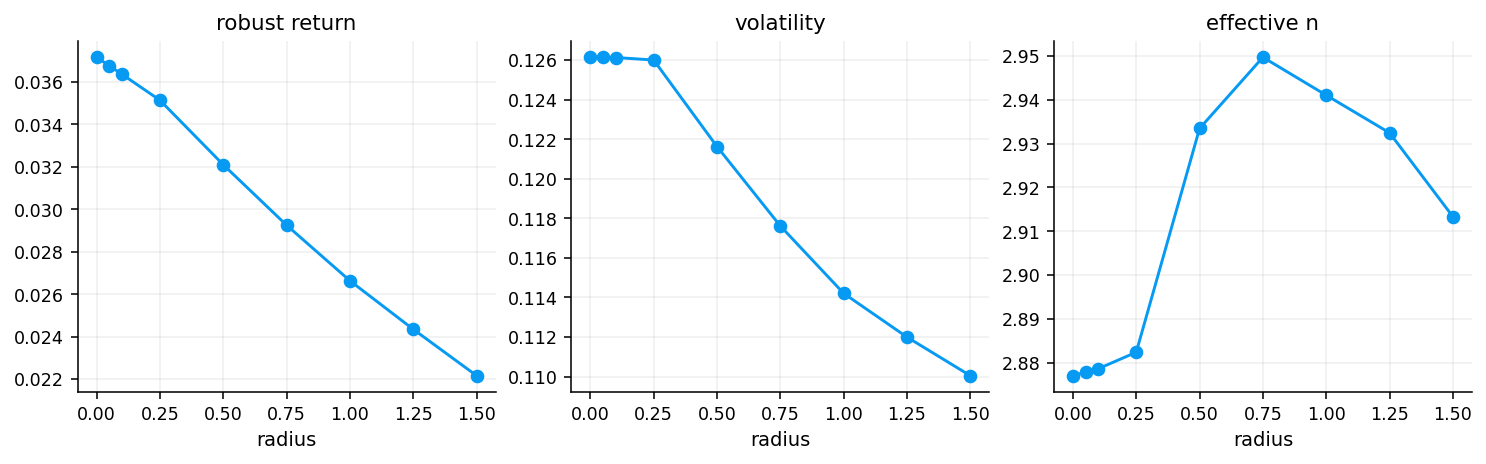

,asset,mu_ann,box_robust_mu,box_weight,ellipsoid_weight
0,SPY,-0.0019,-0.0043,0.0000,0.0000
1,QQQ,0.0017,-0.0014,0.0000,0.0000
2,IWM,0.0129,0.0096,0.0282,0.0392
3,EFA,0.0059,0.0035,0.0000,0.0000
4,EEM,0.0306,0.0277,0.4000,0.4000
5,TLT,-0.0254,-0.0276,0.0000,0.0000
6,IEF,-0.0213,-0.0224,0.0000,0.0000
7,SHY,-0.0165,-0.0170,0.0193,0.0000
8,AGG,-0.0192,-0.0201,0.0000,0.0000
9,LQD,-0.0224,-0.0236,0.0000,0.0000


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Box Robust MV,0.0992,0.1118,0.5520,0.6860,-0.1557,0.6370,0.3462,43.2746,0.0247,3.1317,0.3922
Ellipsoid Robust MV,0.1001,0.1133,0.5533,0.6901,-0.1559,0.6421,0.3401,42.5105,0.0243,3.1440,0.3922


In [24]:
ellipsoid_radius = 0.10
ellipsoid_rows = []
def solve_ellipsoid_portfolio(state, radius):
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    caps = cap_array(tickers).to_numpy(dtype=float)
    n = len(tickers)
    omega_sqrt = psd_sqrt(cov_ann / max(t_mu, 1))
    w = cp.Variable(n)
    penalty = float(radius) * cp.norm(omega_sqrt @ w, 2)
    problem = cp.Problem(cp.Maximize(mu_ann.values @ w - penalty - 0.5 * robust_mv_lambda * cp.quad_form(w, cp.psd_wrap(cov_ann))), [cp.sum(w) == 1.0, w >= 0.0, w <= caps])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return None, status
    return clean_weight_array(w.value, tickers), status

def ellipsoid_robust_weight(dt, state, prev_w):
    out, status = solve_ellipsoid_portfolio(state, ellipsoid_radius)
    if out is None:
        return None
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    omega_sqrt = psd_sqrt(cov_ann / max(t_mu, 1))
    wv = out.reindex(tickers).values
    ellipsoid_rows.append({"date": dt, "status": status, "empirical_return": float(mu_ann.values @ wv), "uncertainty_penalty": float(ellipsoid_radius * np.linalg.norm(omega_sqrt @ wv))})
    return out
ellipsoid_robust_weights = make_weight_frame_from_func("Ellipsoid Robust MV", ellipsoid_robust_weight)
ellipsoid_robust_result = backtest_weight_frame("Ellipsoid Robust MV", ellipsoid_robust_weights)
results["Ellipsoid Robust MV"] = ellipsoid_robust_result
radius_rows = []
for radius in [0.0, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50]:
    w_radius, status = solve_ellipsoid_portfolio(latest_box_state, radius)
    if w_radius is None:
        radius_rows.append({"radius": radius, "status": status})
        continue
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(latest_box_state)
    omega_sqrt = psd_sqrt(cov_ann / max(t_mu, 1))
    wv = w_radius.reindex(tickers).values
    empirical_return = float(mu_ann.values @ wv)
    uncertainty_penalty = float(radius * np.linalg.norm(omega_sqrt @ wv))
    radius_rows.append({"radius": radius, "empirical_return": empirical_return, "uncertainty_penalty": uncertainty_penalty, "robust_return": empirical_return - uncertainty_penalty, "volatility": float(math.sqrt(max(wv @ cov_ann @ wv, 0.0))), "effective_n": float(1.0 / np.square(wv).sum()), "max_weight": float(w_radius.max()), "status": status})
ellipsoid_radius_path = pd.DataFrame(radius_rows)
display(ellipsoid_radius_path.round(4))
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)
for ax, col, title in zip(axes, ["robust_return", "volatility", "effective_n"], ["robust return", "volatility", "effective n"]):
    ax.plot(ellipsoid_radius_path["radius"], ellipsoid_radius_path[col], marker="o", color=colors[0])
    ax.set_title(title)
    ax.set_xlabel("radius")
plt.show()
box_ellipsoid_latest = pd.DataFrame({"asset": latest_tickers, "mu_ann": latest_mu_ann.values, "box_robust_mu": latest_mu_ann.values - box_radius * latest_se_ann, "box_weight": box_robust_weights.iloc[-1].reindex(latest_tickers).values, "ellipsoid_weight": ellipsoid_robust_weights.iloc[-1].reindex(latest_tickers).values})
display(box_ellipsoid_latest.round(4))
display(compact_result_table({"Box Robust MV": box_robust_result, "Ellipsoid Robust MV": ellipsoid_robust_result}).round(4))


The ellipsoid radius path shows how the penalty changes as uncertainty aversion rises. With radius 0.00, there is no robust penalty, and empirical return is about 3.72% in the latest state. As the radius increases to 1.50, the robust return falls to about 2.22%. Volatility also declines modestly from about 12.61% to 11.00%, and effective $N$ stays around 2.9.

The latest allocation comparison between box and ellipsoid is very close. Both models hold:

- EEM at 40%.
- DBC at 40%.
- GLD around 15-16%.
- small IWM exposure.
- little or no allocation to the rest.

The ellipsoid model drops SHY to zero and gives a slightly larger weight to IWM and GLD. The difference is not dramatic because the latest forecast environment is very directional: EEM and DBC dominate even after robust penalties. When the top forecasts are that strong, both box and ellipsoid uncertainty still point to a similar constrained solution.

In the backtest, Ellipsoid Robust MV slightly beats Box Robust MV: CAGR 10.01% versus 9.92%, Sharpe 0.5533 versus 0.5520, and turnover 34.01% versus 34.62%. The difference is small, but enough for the selection rule to choose Ellipsoid Robust MV.

In [25]:
robust_summary = compact_result_table({"Box Robust MV": box_robust_result, "Ellipsoid Robust MV": ellipsoid_robust_result})
best_robust_name = robust_summary.sort_values(["sharpe", "max_drawdown", "avg_turnover", "cagr"], ascending=[False, False, True, False]).index[0]
print("selected robust model:", best_robust_name)
display(robust_summary.round(4))


selected robust model: Ellipsoid Robust MV


,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,
Box Robust MV,0.0992,0.1118,0.5520,0.6860,-0.1557,0.6370,0.3462,43.2746,0.0247,3.1317,0.3922
Ellipsoid Robust MV,0.1001,0.1133,0.5533,0.6901,-0.1559,0.6421,0.3401,42.5105,0.0243,3.1440,0.3922


The robust-model comparison confirms that the two uncertainty sets are close in this implementation. Both models have:

- CAGR around 10%.
- Annualized volatility around 11.2-11.3%.
- Sharpe around 0.55.
- Max drawdown around -15.6%.
- High turnover above 34% average monthly.
- Effective $N$ around 3.1.

This tells us that most of the robust model's behavior comes from the shared inputs: Ledoit-Wolf covariance, momentum expected returns, risk-aversion $\lambda=2.0$, and the asset caps. The choice between box and ellipsoid affects the penalty geometry, but the latest and historical allocations still respond to the same broad signal.

The useful interpretation is that robust MV becomes a middle ground between MaxSharpe and Mean-CVaR. It is more return-seeking than tail-risk-only methods, but more cautious than a raw aggressive frontier model. Its drawdown is better than BL and MaxSharpe, but its ES is not as low as Risk Parity or HRP.

## 11) Wasserstein Distributionally Robust Mean-Variance

Box and ellipsoid robust optimization protect against uncertainty in the expected-return vector. Wasserstein distributionally robust optimization goes deeper. It protects against uncertainty in the **entire return distribution**.

We start with the empirical distribution of historical returns:

$$
\hat{P}_T = \frac{1}{T}\sum_{s=1}^{T}\delta_{r_s}
$$

where $\delta_{r_s}$ is a point mass at historical return vector $r_s$. Standard empirical optimization trusts this distribution exactly. Wasserstein DRO says the true distribution may be near the empirical distribution but not equal to it.

The ambiguity set is:

$$
\mathcal{P}_\varepsilon = \left\{P : W(P,\hat{P}_T) \le \varepsilon \right\}
$$

where $W(P,\hat{P}_T)$ is the Wasserstein distance between distributions, and $\varepsilon$ is the radius. A larger radius means we admit more distributional uncertainty.

The model then optimizes worst-case performance over all distributions in that ball. In this implementation, the robust mean-variance form creates two penalties:

1. A return penalty that subtracts a term proportional to $\|w\|_2$.
2. A volatility inflation that adds the same uncertainty term to empirical volatility.

The resulting objective is:

$$
\max_w\; \hat{\mu}^\top w - \sqrt{\delta}\|w\|_2 - \frac{\lambda}{2}\left(\|\Sigma^{1/2}w\|_2+\sqrt{\delta}\|w\|_2\right)^2
$$

where $\sqrt{\delta}$ is the radius-scaled uncertainty penalty used by the implementation.

Every term in the Wasserstein objective has a clear role:

$$
\hat{\mu}^\top w
$$

is the empirical expected return estimate.

$$
\sqrt{\delta}\|w\|_2
$$

is the distributional uncertainty tax on return. It penalizes concentrated portfolios because $\|w\|_2$ is larger when weights are concentrated. For equal weights over $N$ assets, $\|w\|_2=1/\sqrt{N}$. For a single-asset portfolio, $\|w\|_2=1$.

$$
\|\Sigma^{1/2}w\|_2
$$

is empirical portfolio volatility.

$$
\|\Sigma^{1/2}w\|_2+\sqrt{\delta}\|w\|_2
$$

is robust volatility. The model behaves as if the true volatility may be larger than the sample volatility by an amount tied to distributional uncertainty and concentration.

So Wasserstein DRO attacks two common optimizer problems at once:

- It doesn't fully trust the mean estimate.
- It doesn't fully trust the empirical risk estimate.
- It penalizes portfolios that depend too heavily on a few positions.

That is why this model is often more stable than an aggressive return optimizer, but still more return-seeking than pure risk parity.

The Wasserstein penalty also has an intuitive concentration effect. The norm $\|w\|_2$ behaves like an inverse diversification measure:

$$
\|w\|_2 = \sqrt{\sum_{i=1}^{N}w_i^2}
$$

For equal weight over 14 assets:

$$
\|w_{\text{EW}}\|_2 = \sqrt{14\left(\frac{1}{14}\right)^2} = \frac{1}{\sqrt{14}} \approx 0.267
$$

For a portfolio with 40%, 40%, and 20% in three assets:

$$
\|w\|_2 = \sqrt{0.4^2+0.4^2+0.2^2}=0.60
$$

So the same Wasserstein radius creates a much larger tax for the concentrated portfolio. This is exactly what we want from a distributionally robust model. If we are unsure about the true return distribution, relying on a small number of bets is more dangerous than spreading across many exposures.

The penalty doesn't force equal weight at the radius used here, but it changes the economics of concentration. A concentrated portfolio must have enough estimated return advantage to pay the ambiguity tax and still look attractive after robust risk inflation.

,radius,sqrt_delta,empirical_return,dro_penalty,robust_return,volatility,robust_volatility,risk_penalty,objective,effective_n,max_weight,status
0,0.00,0.0000,0.0372,0.0000,0.0372,0.1264,0.1264,0.0120,0.0252,2.8536,0.4000,optimal
1,0.05,0.0005,0.0372,0.0003,0.0369,0.1263,0.1266,0.0120,0.0249,2.8568,0.4000,optimal
2,0.10,0.0009,0.0372,0.0005,0.0367,0.1263,0.1268,0.0121,0.0246,2.8598,0.4000,optimal
3,0.25,0.0023,0.0372,0.0013,0.0358,0.1262,0.1276,0.0122,0.0236,2.8679,0.4000,optimal
4,0.50,0.0046,0.0372,0.0027,0.0345,0.1261,0.1288,0.0124,0.0220,2.8789,0.4000,optimal
5,1.00,0.0091,0.0371,0.0054,0.0318,0.1260,0.1314,0.0129,0.0188,2.8946,0.4000,optimal
6,2.00,0.0182,0.0370,0.0106,0.0264,0.1258,0.1365,0.0140,0.0124,2.9333,0.4000,optimal
7,5.00,0.0456,0.0310,0.0223,0.0088,0.1129,0.1352,0.0137,-0.0050,4.1869,0.4000,optimal
8,10.00,0.0912,0.0148,0.0302,-0.0154,0.0924,0.1225,0.0113,-0.0266,9.1402,0.2306,optimal


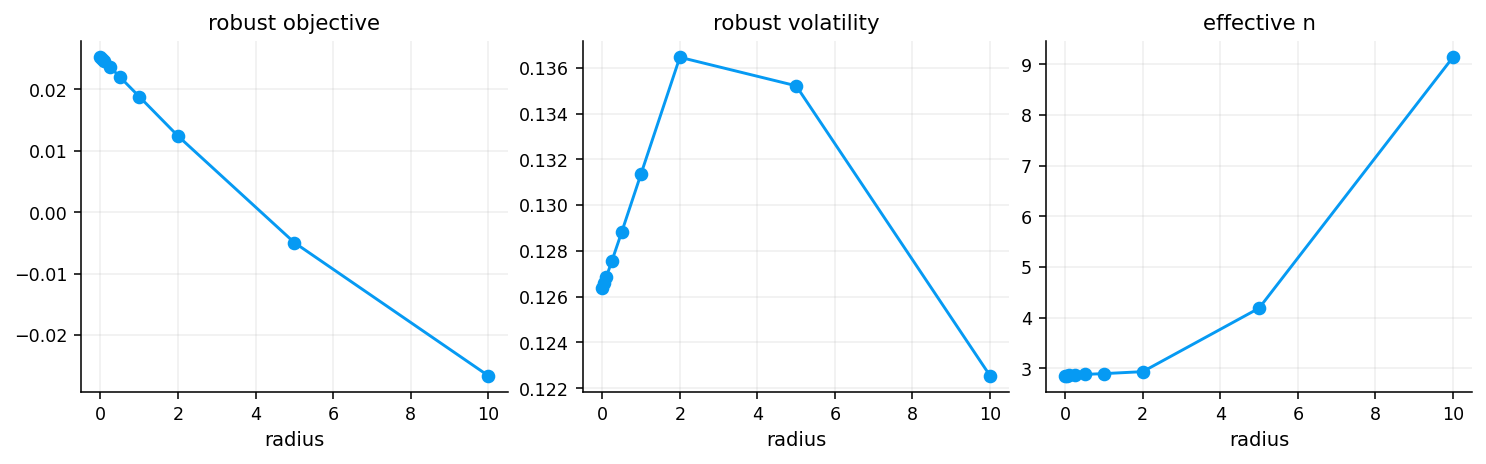

,Wasserstein DRMV
DBC,0.4000
EEM,0.4000
GLD,0.1523
IWM,0.0477
EFA,0.0000
VNQ,0.0000
SHY,0.0000
SPY,0.0000
HYG,0.0000
QQQ,0.0000


,sqrt_delta,empirical_return,dro_penalty,robust_return,volatility,robust_volatility,risk_penalty,objective,effective_n,max_weight,status
date,,,,,,,,,,,
2026-03-31,0.0090,0.0339,0.0053,0.0286,0.1349,0.1402,0.0147,0.0139,2.8711,0.4,optimal
2026-04-30,0.0091,0.0663,0.0053,0.0610,0.1271,0.1324,0.0131,0.0478,2.9312,0.4,optimal
2026-05-29,0.0091,0.0371,0.0054,0.0318,0.1260,0.1314,0.0129,0.0188,2.8946,0.4,optimal


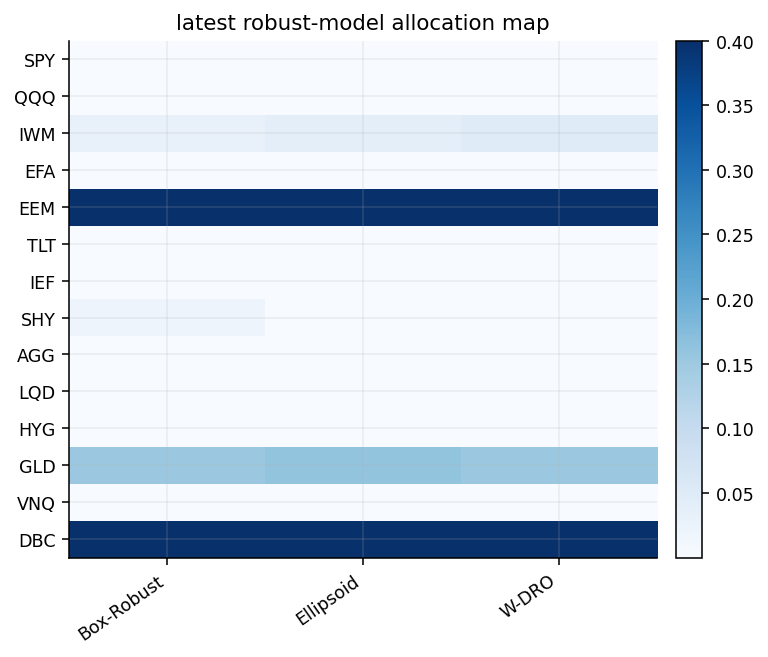

In [26]:
dro_radius = 1.0
wasserstein_mv_lambda = 1.5
wasserstein_rows = []
def solve_wasserstein_utility(state, radius):
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    caps = cap_array(tickers).to_numpy(dtype=float)
    n = len(tickers)
    sqrt_delta = float(radius) * math.sqrt(float(np.trace(cov_ann)) / n) / math.sqrt(max(t_mu, 1))
    w = cp.Variable(n)
    sigma_sqrt = psd_sqrt(cov_ann)
    dro_penalty = sqrt_delta * cp.norm(w, 2)
    empirical_volatility = cp.norm(sigma_sqrt @ w, 2)
    robust_volatility = empirical_volatility + dro_penalty
    objective = cp.Maximize(mu_ann.values @ w - dro_penalty - 0.5 * wasserstein_mv_lambda * cp.square(robust_volatility))
    problem = cp.Problem(objective, [cp.sum(w) == 1.0, w >= 0.0, w <= caps])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return None, status, sqrt_delta
    return clean_weight_array(w.value, tickers), status, sqrt_delta

def wasserstein_weight(dt, state, prev_w):
    out, status, sqrt_delta = solve_wasserstein_utility(state, dro_radius)
    if out is None:
        return None
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    wv = out.reindex(tickers).values
    empirical_return = float(mu_ann.values @ wv)
    wasserstein_penalty = float(sqrt_delta * np.linalg.norm(wv))
    empirical_volatility = float(math.sqrt(max(wv @ cov_ann @ wv, 0.0)))
    robust_volatility = empirical_volatility + wasserstein_penalty
    risk_penalty = 0.5 * wasserstein_mv_lambda * robust_volatility ** 2
    wasserstein_rows.append({"date": dt, "sqrt_delta": sqrt_delta, "empirical_return": empirical_return, "dro_penalty": wasserstein_penalty, "robust_return": empirical_return - wasserstein_penalty, "volatility": empirical_volatility, "robust_volatility": robust_volatility, "risk_penalty": risk_penalty, "objective": empirical_return - wasserstein_penalty - risk_penalty, "effective_n": float(1.0 / np.square(wv).sum()), "max_weight": float(out.max()), "status": status})
    return out
wasserstein_weights = make_weight_frame_from_func("Wasserstein DRMV", wasserstein_weight)
wasserstein_result = backtest_weight_frame("Wasserstein DRMV", wasserstein_weights)
results["Wasserstein DRMV"] = wasserstein_result
wasserstein_diag = pd.DataFrame(wasserstein_rows).set_index("date")
dro_rows = []
latest_tickers, latest_mu_w, latest_cov_w, latest_t_mu_w = selected_mv_inputs(latest_box_state)
for radius in [0.0, 0.05, 0.10, 0.25, 0.50, 1.00, 2.00, 5.00, 10.00]:
    w_radius, status, sqrt_delta = solve_wasserstein_utility(latest_box_state, radius)
    if w_radius is None:
        dro_rows.append({"radius": radius, "sqrt_delta": sqrt_delta, "status": status})
        continue
    wv = w_radius.reindex(latest_tickers).values
    empirical_return = float(latest_mu_w.values @ wv)
    dro_penalty = float(sqrt_delta * np.linalg.norm(wv))
    empirical_volatility = float(math.sqrt(max(wv @ latest_cov_w @ wv, 0.0)))
    robust_volatility = empirical_volatility + dro_penalty
    risk_penalty = 0.5 * wasserstein_mv_lambda * robust_volatility ** 2
    dro_rows.append({"radius": radius, "sqrt_delta": sqrt_delta, "empirical_return": empirical_return, "dro_penalty": dro_penalty, "robust_return": empirical_return - dro_penalty, "volatility": empirical_volatility, "robust_volatility": robust_volatility, "risk_penalty": risk_penalty, "objective": empirical_return - dro_penalty - risk_penalty, "effective_n": float(1.0 / np.square(wv).sum()), "max_weight": float(w_radius.max()), "status": status})
wasserstein_radius_path = pd.DataFrame(dro_rows)
display(wasserstein_radius_path.round(4))
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), constrained_layout=True)
for ax, col, title in zip(axes, ["objective", "robust_volatility", "effective_n"], ["robust objective", "robust volatility", "effective n"]):
    ax.plot(wasserstein_radius_path["radius"], wasserstein_radius_path[col], marker="o", color=colors[0])
    ax.set_title(title)
    ax.set_xlabel("radius")
plt.show()
display(wasserstein_weights.iloc[-1].sort_values(ascending=False).to_frame("Wasserstein DRMV").round(4))
display(wasserstein_diag.tail(3).round(4))
robust_latest_weights = pd.concat({"Box-Robust": box_robust_weights.iloc[-1], "Ellipsoid": ellipsoid_robust_weights.iloc[-1], "W-DRO": wasserstein_weights.iloc[-1]}, axis=1).reindex(assets).fillna(0.0)
fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(robust_latest_weights.values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(robust_latest_weights.columns)))
ax.set_xticklabels(robust_latest_weights.columns, rotation=35, ha="right")
ax.set_yticks(range(len(robust_latest_weights.index)))
ax.set_yticklabels(robust_latest_weights.index)
ax.set_title("latest robust-model allocation map")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
plt.tight_layout()
plt.show()


The Wasserstein radius path gives a clean sensitivity analysis. At radius 0, the model behaves close to empirical robust MV: empirical return about 3.72%, volatility around 12.64%, effective $N$ around 2.85, max weight 40%.

As the radius rises:

- The return penalty increases.
- Robust return falls.
- Robust volatility becomes larger than empirical volatility.
- Effective $N$ eventually rises.
- The max weight finally starts falling at very large radii.

At radius 10, the model has effective $N$ around 9.14 and max weight about 23.06%. That is a very different portfolio from the radius 0 or 1 solution. The model is being forced to diversify because distributional uncertainty is now expensive enough that concentrated weights are unattractive.

The project uses radius 1.0. At that level, the latest portfolio is still concentrated in DBC, EEM, GLD, and IWM. The model hasn't become a defensive equal-weight portfolio. It remains return-seeking, but with an explicit distributional penalty.

The latest Wasserstein DRMV weights are:

- DBC at 40%.
- EEM at 40%.
- GLD at 15.23%.
- IWM at 4.77%.
- zero in most other assets.

This resembles the box/ellipsoid robust allocation because the current return signals are strongly concentrated in the same assets. The difference is in the objective accounting. Wasserstein DRMV tracks its uncertainty tax, robust volatility, robust return, risk penalty, and objective through time.

The latest three rows show a fairly stable $\sqrt{\delta}$ around 0.009. Empirical return changes month by month, from 3.39% to 6.63% to 3.71%, while the DRO penalty stays around 0.53-0.54%. This means the uncertainty tax is meaningful, but it doesn't dominate the expected-return forecast at radius 1.0.

The backtest result is strong relative to other new models: 10.54% CAGR, 11.86% volatility, Sharpe 0.5743, and -17.61% max drawdown. It beats Box and Ellipsoid on return and Sharpe, but it also has a larger ES and higher drawdown than Mean-CVaR. That is the expected personality of the model: robust, but still return-seeking.

### 11.1 Wasserstein Target-Return Diagnostic

The target-return diagnostic asks a slightly different question. Instead of maximizing robust utility, we set a required robust return and minimize robust risk.

The problem is:

$$
\min_w\; \|\Sigma^{1/2}w\|_2 + \sqrt{\delta}\|w\|_2
$$

subject to:

$$
\hat{\mu}^\top w - \sqrt{\delta}\|w\|_2 \ge r^\star
$$

$$
\mathbf{1}^\top w=1,\qquad 0\le w_i\le \bar{w}_i
$$

where $r^\star$ is the target robust return. The left side of the return constraint is the expected return after the Wasserstein tax. The objective is robust risk, empirical volatility plus the same distributional concentration penalty.

This diagnostic produces a robust frontier. For each target return, we see how much empirical volatility and robust risk are needed. It is similar in spirit to an efficient frontier, but the risk axis includes distributional uncertainty.

,target,empirical_status,target_status,empirical_mv_vol,empirical_effective_n,wasserstein_empirical_vol,wasserstein_tax,wasserstein_robust_risk,wasserstein_effective_n
0,-0.0185,optimal,optimal,0.0345,3.2614,0.0346,0.0049,0.0395,3.4839
1,-0.0145,optimal,optimal,0.0345,3.2614,0.0349,0.0048,0.0397,3.5962
2,-0.0104,optimal,optimal,0.0346,3.3194,0.0374,0.0047,0.0420,3.8402
3,-0.0064,optimal,optimal,0.0367,3.4875,0.0415,0.0046,0.0461,4.0133
4,-0.0023,optimal,optimal,0.0407,3.7090,0.0468,0.0045,0.0514,4.0136
5,0.0017,optimal,optimal,0.0460,3.7888,0.0531,0.0046,0.0577,3.8673
6,0.0058,optimal,optimal,0.0521,3.7079,0.0603,0.0046,0.0648,4.0084
7,0.0098,optimal,optimal,0.0587,3.4857,0.0678,0.0046,0.0724,3.9461
8,0.0139,optimal,optimal,0.0658,3.2278,0.0757,0.0047,0.0804,3.7208
9,0.0179,optimal,optimal,0.0732,2.9883,0.0844,0.0048,0.0892,3.5460


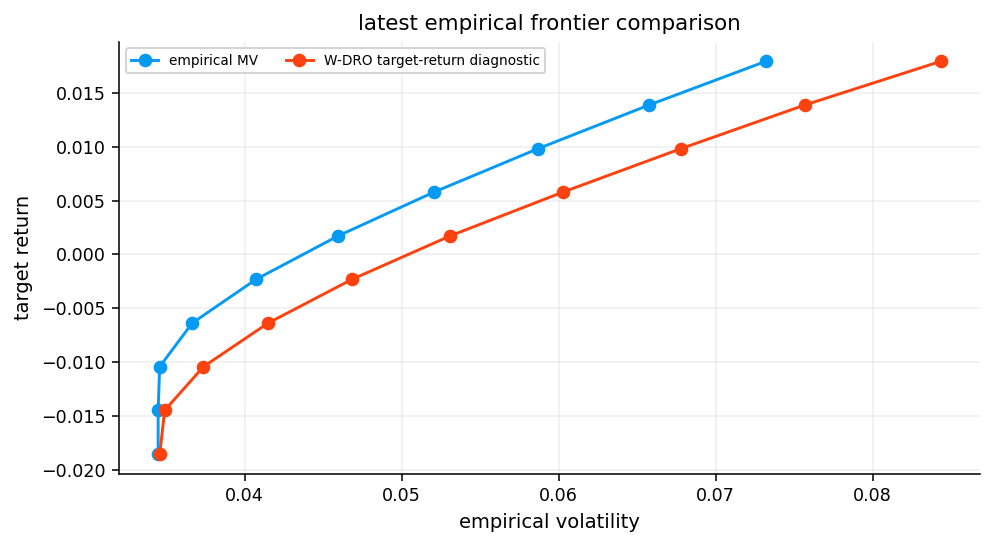

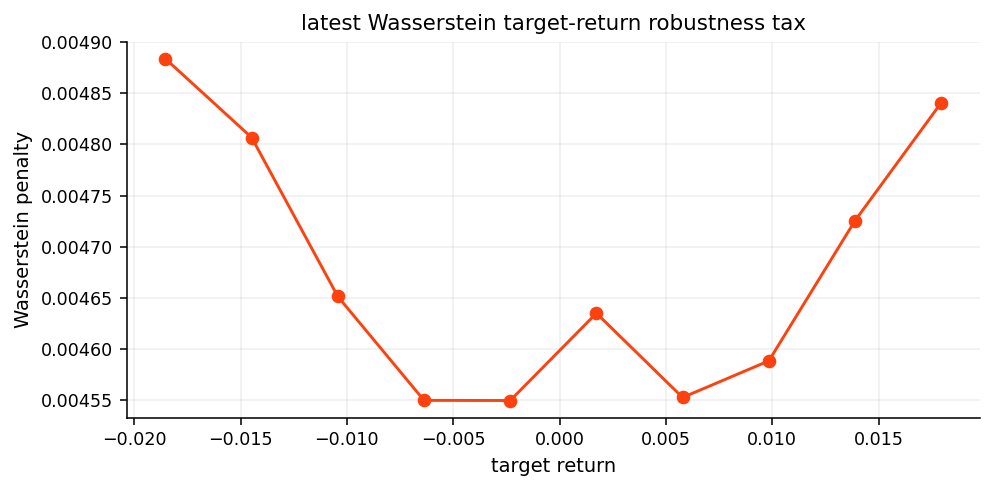

In [27]:
def solve_wasserstein_target_return(state, radius, target_return):
    tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(state)
    caps = cap_array(tickers).to_numpy(dtype=float)
    n = len(tickers)
    sigma_sqrt = psd_sqrt(cov_ann)
    sqrt_delta = float(radius) * math.sqrt(float(np.trace(cov_ann)) / n) / math.sqrt(max(t_mu, 1))
    w = cp.Variable(n)
    empirical_risk = cp.norm(sigma_sqrt @ w, 2)
    penalty = sqrt_delta * cp.norm(w, 2)
    problem = cp.Problem(cp.Minimize(empirical_risk + penalty), [cp.sum(w) == 1.0, w >= 0.0, w <= caps, mu_ann.values @ w - penalty >= float(target_return)])
    status = solve_cvx_problem(problem)
    if w.value is None or status not in ["optimal", "optimal_inaccurate"]:
        return None, status, sqrt_delta
    return clean_weight_array(w.value, tickers), status, sqrt_delta
latest_state = walkforward_grid.cache[model_rebalance_dates[-1]]
tickers, mu_ann, cov_ann, t_mu = selected_mv_inputs(latest_state)
caps = cap_array(tickers).to_numpy(dtype=float)
sigma_sqrt = psd_sqrt(cov_ann)
target_grid = np.linspace(float(np.nanpercentile(mu_ann.values, 25)), float(np.nanpercentile(mu_ann.values, 85)), 10)
frontier_rows = []
for target in target_grid:
    n = len(tickers)
    w = cp.Variable(n)
    empirical_risk = cp.norm(sigma_sqrt @ w, 2)
    empirical_problem = cp.Problem(cp.Minimize(empirical_risk), [cp.sum(w) == 1.0, w >= 0.0, w <= caps, mu_ann.values @ w >= float(target)])
    empirical_status = solve_cvx_problem(empirical_problem)
    empirical_w = clean_weight_array(w.value, tickers) if w.value is not None and empirical_status in ["optimal", "optimal_inaccurate"] else None
    w2, target_status, sqrt_delta_used = solve_wasserstein_target_return(latest_state, dro_radius, float(target))
    row = {"target": float(target), "empirical_status": empirical_status, "target_status": target_status}
    if empirical_w is not None:
        ev = empirical_w.reindex(tickers).values
        row.update({"empirical_mv_vol": float(math.sqrt(max(ev @ cov_ann @ ev, 0.0))), "empirical_effective_n": float(1.0 / np.square(ev).sum())})
    if w2 is not None:
        wv = w2.reindex(tickers).values
        vol = float(math.sqrt(max(wv @ cov_ann @ wv, 0.0)))
        tax = float(sqrt_delta_used * np.linalg.norm(wv))
        row.update({"wasserstein_empirical_vol": vol, "wasserstein_tax": tax, "wasserstein_robust_risk": vol + tax, "wasserstein_effective_n": float(1.0 / np.square(wv).sum())})
    frontier_rows.append(row)
frontier_table = pd.DataFrame(frontier_rows)
display(frontier_table.round(4))
frontier_plot = frontier_table.dropna(subset=["empirical_mv_vol", "wasserstein_empirical_vol"], how="all")
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(frontier_plot["empirical_mv_vol"], frontier_plot["target"], marker="o", label="empirical MV")
ax.plot(frontier_plot["wasserstein_empirical_vol"], frontier_plot["target"], marker="o", label="W-DRO target-return diagnostic")
ax.set_title("latest empirical frontier comparison")
ax.set_xlabel("empirical volatility")
ax.set_ylabel("target return")
ax.legend(fontsize=7, ncol=2, frameon=True, framealpha=0.85)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(frontier_table["target"], frontier_table["wasserstein_tax"], marker="o", color=colors[1])
ax.set_title("latest Wasserstein target-return robustness tax")
ax.set_xlabel("target return")
ax.set_ylabel("Wasserstein penalty")
plt.tight_layout()
plt.show()


The target-return table shows both empirical and Wasserstein-adjusted portfolios are feasible across the target grid. As target return increases from about -1.85% to 1.79%, empirical volatility rises from about 3.45% to 7.32%. The Wasserstein robust risk rises from about 3.95% to 8.92%.

The robust frontier lies above the empirical frontier because it adds the Wasserstein tax. That gap is useful. It shows how much risk the model attributes to distributional ambiguity rather than observed covariance alone.

The tax is lowest near the middle of the target range and rises near the extremes. That makes sense because extreme low- or high-return targets can require more concentrated or less natural allocations. The effective number of positions also moves with the target, rising toward the middle and falling when the target becomes more return-seeking.

This plot is not a strategy by itself. It is a diagnostic for the chosen DRO radius. It helps us see whether the radius is too small to matter, too large to make return targets impossible, or moderate enough to reshape the efficient frontier without destroying feasibility. In this implementation, radius 1.0 looks moderate.

## 12) Full Model Table and Feasibility Checks

After all local models are built, we combine them with the baselines into one table. This is where the project becomes a genuine model-comparison exercise.

The full table includes:

- Equal Weight.
- MinVar.
- MV.
- MaxSharpe.
- Learned-Confidence BL.
- Min-CVaR.
- Mean-CVaR.
- Risk Parity.
- HRP.
- NCO-MV.
- Box Robust MV.
- Ellipsoid Robust MV.
- Wasserstein DRMV.

The feasibility check is also important. Every local model has:

$$
\max_t |\mathbf{1}^\top w_t - 1| = 0
$$

and no cap violations. Fallback count is zero for every local model. So when models perform differently, we don't need to explain it through failed optimization or invalid weights. The solvers found valid portfolios under the common constraints.

This matters especially for CVaR and robust objectives. Convex formulations are powerful, but portfolio constraints, cap constraints, and numerical tolerances can still create failures. Here the implementation is stable enough that the comparison is clean.

A good comparison here needs more than one metric because the models optimize different things. The clean way to compare them is to group metrics into four families:

| Family | Metrics | What it reveals |
|---|---|---|
| Return quality | CAGR, Sharpe, Sortino, Calmar | whether risk is being rewarded |
| Tail safety | max drawdown, VaR, ES, worst month | whether losses are controlled |
| Implementation cost | turnover, cost drag | whether the strategy can survive trading frictions |
| Allocation structure | effective $N$, max weight, sleeve exposure | whether the model is diversified or concentrated |

This matters because a model can win one family and lose another. Risk Parity wins tail safety but loses return quality. BL wins return quality but has high turnover and higher ES. Mean-CVaR has a strong middle position: not the highest return, not the lowest tail risk, but a good blend. W-DRO is stronger on return than Mean-CVaR, but weaker on tail risk.

The comparison is strongest when we keep these families separate. A single rank is useful at the end, but the model personality comes from the full metric profile.

In [28]:
def full_result_table(result_dict):
    table = compact_result_table(result_dict)
    var_rows = []
    for name, result in result_dict.items():
        r = result.net_returns.dropna()
        var = var_es_table(r.to_frame(name), alpha=0.05, methods=("hist",))
        var_rows.append({
            "Strategy": name,
            "var_95": float(var.loc[name, "hist_var5"]),
            "es_95": float(var.loc[name, "hist_es5"]),
            "worst_month": float(r.resample("ME").apply(lambda x: (1.0 + x).prod() - 1.0).min()),
            "avg_max_weight": float(result.weights.max(axis=1).mean()),
        })
    var_rows = pd.DataFrame(var_rows).set_index("Strategy")
    out = table.drop(columns=[c for c in var_rows.columns if c in table.columns], errors="ignore").join(var_rows, how="left")
    out = out.rename(columns={"vol": "ann_vol", "effective_n": "avg_effective_n"})
    out["ann_return"] = out["cagr"]
    cols = ["cagr", "ann_return", "ann_vol", "sharpe", "sortino", "calmar", "max_drawdown", "var_95", "es_95", "worst_month", "avg_turnover", "total_turnover", "cost_drag", "avg_effective_n", "avg_max_weight"]
    return out[[c for c in cols if c in out.columns]]

full_summary = full_result_table(results)
display(full_summary.sort_values(["sharpe", "max_drawdown", "cagr"], ascending=[False, False, False]).round(4))

local_model_names = ["Min-CVaR 95", "Mean-CVaR 95", "Risk Parity", "HRP", "NCO-MV", "Box Robust MV", "Ellipsoid Robust MV", "Wasserstein DRMV"]
weight_check_rows = []
for name in local_model_names:
    if name not in results:
        continue
    w = results[name].weights.reindex(columns=assets).fillna(0.0)
    weight_check_rows.append({"model": name, "max_sum_error": float((w.sum(axis=1) - 1.0).abs().max()), "max_cap_excess": float((w - w_max).max(axis=1).clip(lower=0.0).max()), "fallback_count": int(local_fallback_counts.get(name, 0))})
weight_checks = pd.DataFrame(weight_check_rows).set_index("model")
display(weight_checks.round(8))


,cagr,ann_return,ann_vol,sharpe,sortino,calmar,max_drawdown,var_95,es_95,worst_month,avg_turnover,total_turnover,cost_drag,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,,,,,,
Learned-Confidence BL,0.1253,0.1253,0.1150,0.7458,0.9287,0.6888,-0.1820,0.0109,0.0176,-0.0742,0.3147,39.3320,0.0226,5.2021,0.2724
"MaxSharpe (Sample, BayesSteinMomentum)",0.1168,0.1168,0.1189,0.6553,0.8164,0.7065,-0.1653,0.0115,0.0186,-0.0976,0.2177,27.4264,0.0158,3.2046,0.3897
Wasserstein DRMV,0.1054,0.1054,0.1186,0.5743,0.7120,0.5986,-0.1761,0.0118,0.0184,-0.0859,0.3119,38.9873,0.0223,3.7144,0.3632
Mean-CVaR 95,0.0921,0.0921,0.0955,0.5609,0.7014,0.6305,-0.1461,0.0090,0.0145,-0.0552,0.3077,38.4629,0.0223,3.3662,0.3887
Ellipsoid Robust MV,0.1001,0.1001,0.1133,0.5533,0.6901,0.6421,-0.1559,0.0112,0.0174,-0.0821,0.3401,42.5105,0.0243,3.1440,0.3922
Box Robust MV,0.0992,0.0992,0.1118,0.5520,0.6860,0.6370,-0.1557,0.0110,0.0172,-0.0835,0.3462,43.2746,0.0247,3.1317,0.3922
"MV (LedoitWolf, BayesStein)",0.0814,0.0814,0.0847,0.4949,0.6049,0.5904,-0.1378,0.0083,0.0132,-0.0659,0.0369,4.6481,0.0028,5.0557,0.3212
Equal Weight,0.0848,0.0848,0.0935,0.4842,0.5934,0.4159,-0.2038,0.0086,0.0139,-0.0806,0.0114,1.4385,0.0010,14.0000,0.0714
MinVar (OAS),0.0665,0.0665,0.0754,0.3543,0.4044,0.3370,-0.1973,0.0066,0.0111,-0.0761,0.0031,0.3897,0.0003,9.1680,0.2394


,max_sum_error,max_cap_excess,fallback_count
model,,,
Min-CVaR 95,0.0,0.0,0
Mean-CVaR 95,0.0,0.0,0
Risk Parity,0.0,0.0,0
HRP,0.0,0.0,0
NCO-MV,0.0,0.0,0
Box Robust MV,0.0,0.0,0
Ellipsoid Robust MV,0.0,0.0,0
Wasserstein DRMV,0.0,0.0,0


The full ranking by Sharpe tells the story:

| Model type | Strongest representative | Main result |
|---|---|---|
| Active Bayesian views | Learned-Confidence BL | highest Sharpe and CAGR |
| Aggressive frontier | MaxSharpe | highest Calmar, strong CAGR, high concentration |
| Distributionally robust | Wasserstein DRMV | best of the new robust models by Sharpe |
| Tail-budgeted | Mean-CVaR 95 | strong balance of return and tail control |
| Classical robust MV | Ellipsoid Robust MV | slightly better than box robust |
| Pure tail/risk parity | Min-CVaR, RP, HRP | strongest risk control, weaker return |

Learned-Confidence BL remains the top model overall by Sharpe at 0.7458 and CAGR at 12.53%. MaxSharpe is second by Sharpe at 0.6553 and has the best Calmar at 0.7065. Wasserstein DRMV is the best new robust model by Sharpe at 0.5743. Mean-CVaR is close behind at 0.5609 with lower volatility and lower drawdown.

Risk Parity and HRP have the best tail metrics. Risk Parity has ES of 0.73% and max drawdown of -13.74%, the best among finalists. HRP has ES of 0.75% and very low volatility. Their weakness is return, not risk.

In [29]:
def rank_for_choice(names, table, columns, ascending):
    available = [name for name in names if name in table.index]
    return table.loc[available].sort_values(columns, ascending=ascending).index[0]

best_cvar_name = rank_for_choice(
    ["Min-CVaR 95", "Mean-CVaR 95"],
    full_summary,
    ["sharpe", "calmar", "es_95", "max_drawdown", "cagr"],
    [False, False, True, False, False],
)

benchmark_models = [
    "Equal Weight",
    best_minvar_name,
    best_mv_name,
    best_maxsharpe_name,
    "Learned-Confidence BL",
]

selected_models_raw = benchmark_models + [best_cvar_name, "Risk Parity", best_hier_name, best_robust_name, "Wasserstein DRMV"]
selected_models = list(dict.fromkeys([name for name in selected_models_raw if name in results]))
short_label_map = {"Equal Weight": "EW", best_minvar_name: "MinVar", best_mv_name: "MV", best_maxsharpe_name: "MaxSharpe", "Learned-Confidence BL": "BL", "Min-CVaR 95": "Min-CVaR", "Mean-CVaR 95": "Mean-CVaR", "Risk Parity": "RP", "HRP": "HRP", "NCO-MV": "NCO-MV", "Box Robust MV": "Box-Robust", "Ellipsoid Robust MV": "Ellipsoid", "Wasserstein DRMV": "W-DRO"}
def short_labels(names):
    return [short_label_map.get(name, name) for name in names]
def small_legend(ax, loc="best"):
    ax.legend(fontsize=7, ncol=2, frameon=True, framealpha=0.85, loc=loc)

reason_rows = []
for name in selected_models:
    if name == "Equal Weight":
        role = "baseline"
        selected_from = "project 2 grid"
    elif name == best_minvar_name:
        role = "minimum variance benchmark"
        selected_from = "project 2 grid"
    elif name == best_mv_name:
        role = "mean-variance benchmark"
        selected_from = "project 2 grid"
    elif name == best_maxsharpe_name:
        role = "sharpe/frontier benchmark"
        selected_from = "project 2 grid"
    elif name == "Learned-Confidence BL":
        role = "black-litterman benchmark"
        selected_from = "project 6 rebuild"
    elif name == best_cvar_name:
        role = "tail-risk allocation"
        selected_from = "Min-CVaR 95 vs Mean-CVaR 95"
    elif name == "Risk Parity":
        role = "risk budget allocation"
        selected_from = "single specified model"
    elif name == best_hier_name:
        role = "hierarchical allocation"
        selected_from = "HRP vs NCO-MV"
    elif name == best_robust_name:
        role = "robust mean-variance"
        selected_from = "Box Robust MV vs Ellipsoid Robust MV"
    else:
        role = "distributionally robust allocation"
        selected_from = "single specified model"
    reason_rows.append({"model": name, "role": role, "selected_from": selected_from})

selected_reason = pd.DataFrame(reason_rows).set_index("model")
display(pd.Series(selected_models, name="model").to_frame())
display(selected_reason)
print("selected CVaR model:", best_cvar_name)


,model
0,Equal Weight
1,MinVar (OAS)
2,"MV (LedoitWolf, BayesStein)"
3,"MaxSharpe (Sample, BayesSteinMomentum)"
4,Learned-Confidence BL
5,Mean-CVaR 95
6,Risk Parity
7,HRP
8,Ellipsoid Robust MV
9,Wasserstein DRMV


,role,selected_from
model,,
Equal Weight,baseline,project 2 grid
MinVar (OAS),minimum variance benchmark,project 2 grid
"MV (LedoitWolf, BayesStein)",mean-variance benchmark,project 2 grid
"MaxSharpe (Sample, BayesSteinMomentum)",sharpe/frontier benchmark,project 2 grid
Learned-Confidence BL,black-litterman benchmark,project 6 rebuild
Mean-CVaR 95,tail-risk allocation,Min-CVaR 95 vs Mean-CVaR 95
Risk Parity,risk budget allocation,single specified model
HRP,hierarchical allocation,HRP vs NCO-MV
Ellipsoid Robust MV,robust mean-variance,Box Robust MV vs Ellipsoid Robust MV


selected CVaR model: Mean-CVaR 95


The selection cell chooses a compact finalist set so the plots stay readable. The selected models are:

- Equal Weight.
- MinVar with OAS.
- MV with Ledoit-Wolf and Bayes-Stein.
- MaxSharpe with sample covariance and Bayes-Stein Momentum.
- Learned-Confidence BL.
- Mean-CVaR 95.
- Risk Parity.
- HRP.
- Ellipsoid Robust MV.
- Wasserstein DRMV.

The selected CVaR model is Mean-CVaR 95. This is exactly the right choice because Min-CVaR's low tail loss comes with negative Sharpe. The selected hierarchical model is HRP because it beats NCO-MV on Sharpe, drawdown, and turnover. The selected classical robust model is Ellipsoid Robust MV because it slightly beats Box Robust MV.

This filtered set now covers the main philosophical choices:

- simple diversification,
- variance minimization,
- expected-return optimization,
- Bayesian active views,
- tail-risk budgeting,
- risk-budgeting,
- hierarchy-based allocation,
- mean-uncertainty robustness,
- distributional robustness.

In [30]:

selected_scoreboard = full_summary.loc[selected_models, ["cagr", "ann_vol", "sharpe", "sortino", "calmar", "max_drawdown", "es_95", "avg_turnover", "avg_effective_n", "avg_max_weight"]]
display(selected_scoreboard.sort_values("sharpe", ascending=False).round(4))


,cagr,ann_vol,sharpe,sortino,calmar,max_drawdown,es_95,avg_turnover,avg_effective_n,avg_max_weight
Strategy,,,,,,,,,,
Learned-Confidence BL,0.1253,0.1150,0.7458,0.9287,0.6888,-0.1820,0.0176,0.3147,5.2021,0.2724
"MaxSharpe (Sample, BayesSteinMomentum)",0.1168,0.1189,0.6553,0.8164,0.7065,-0.1653,0.0186,0.2177,3.2046,0.3897
Wasserstein DRMV,0.1054,0.1186,0.5743,0.7120,0.5986,-0.1761,0.0184,0.3119,3.7144,0.3632
Mean-CVaR 95,0.0921,0.0955,0.5609,0.7014,0.6305,-0.1461,0.0145,0.3077,3.3662,0.3887
Ellipsoid Robust MV,0.1001,0.1133,0.5533,0.6901,0.6421,-0.1559,0.0174,0.3401,3.1440,0.3922
"MV (LedoitWolf, BayesStein)",0.0814,0.0847,0.4949,0.6049,0.5904,-0.1378,0.0132,0.0369,5.0557,0.3212
Equal Weight,0.0848,0.0935,0.4842,0.5934,0.4159,-0.2038,0.0139,0.0114,14.0000,0.0714
MinVar (OAS),0.0665,0.0754,0.3543,0.4044,0.3370,-0.1973,0.0111,0.0031,9.1680,0.2394
HRP,0.0519,0.0504,0.2547,0.3247,0.3586,-0.1446,0.0075,0.0186,5.0967,0.4000


## 13) Finalist Scoreboard

The finalist scoreboard gives the clearest numeric comparison.

Learned-Confidence BL leads the table with:

$$
\text{CAGR}=12.53\%,\quad \text{Sharpe}=0.7458,\quad \text{Sortino}=0.9287
$$

Its weakness is drawdown and tail size compared with defensive models:

$$
\text{Max Drawdown}=-18.20\%,\quad ES_{95}=1.76\%
$$

MaxSharpe is close in return, 11.68% CAGR, and has the best Calmar at 0.7065, but it has the worst ES among finalists at 1.86% and a very low effective $N$ of 3.20. This is a high-conviction, high-turnover model.

Wasserstein DRMV earns 10.54% CAGR with Sharpe 0.5743. That is a good result for a robust model. It doesn't beat BL or MaxSharpe, but it does beat classical MV, Equal Weight, MinVar, Risk Parity, and HRP on Sharpe.

Mean-CVaR 95 is one of the best balanced new models: 9.21% CAGR, 9.55% volatility, Sharpe 0.5609, and max drawdown -14.61%. Its ES is 1.45%, meaning it gives up some return to improve tail behavior.

Risk Parity wins risk control: ES 0.73% and max drawdown -13.74%. Its Sharpe is only 0.1320 because the portfolio is too defensive relative to the 4% risk-free rate.

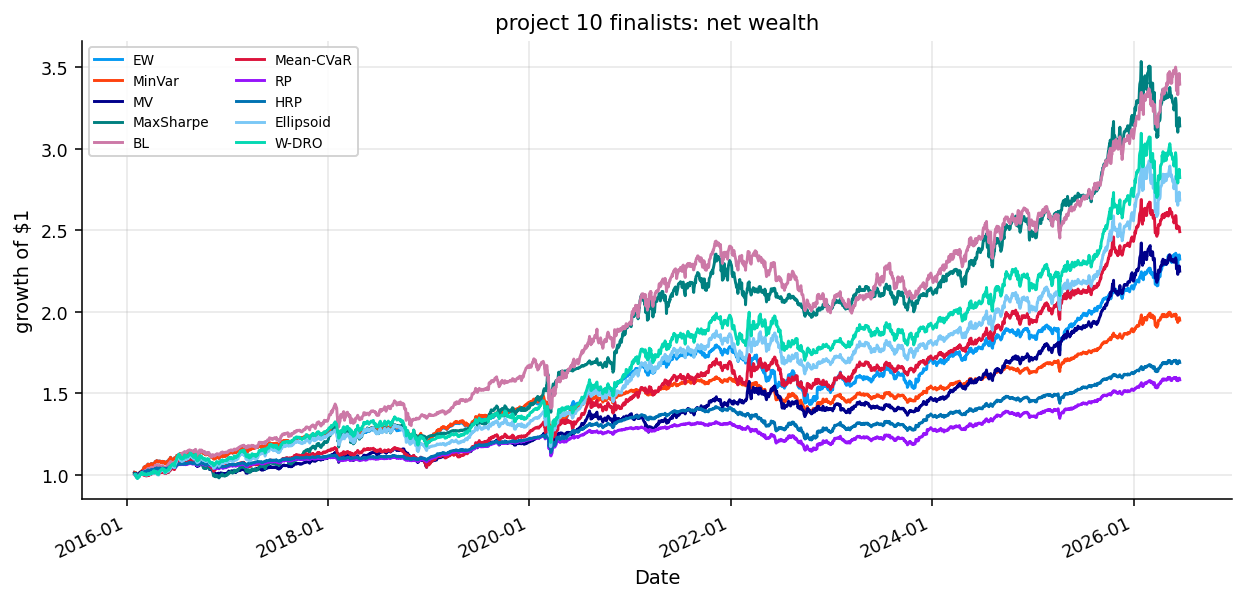

In [31]:
selected_nav = pd.DataFrame({name: results[name].net_values for name in selected_models}).dropna(how="all")
fig, ax = plt.subplots(figsize=(9.0, 4.4))
plot_strategy_nav(selected_nav[selected_models], ax=ax, title="project 10 finalists: net wealth", labels=short_labels(selected_models))
ax.set_ylabel("growth of $1")
small_legend(ax, loc="upper left")
plt.tight_layout()
plt.show()


The net-wealth plot shows the practical version of the table. Learned-Confidence BL and MaxSharpe finish near the top, with Wasserstein DRMV and Ellipsoid Robust MV also compounding well. Mean-CVaR grows more slowly but with less severe tail exposure. Risk Parity and HRP trail because their defensive allocations don't earn enough return in this sample.

The drawdown plot shows the other side. The active models that grow faster also accept deeper drawdowns. BL, MaxSharpe, and W-DRO all experience drawdowns around the mid-to-high teens. Mean-CVaR keeps drawdown closer to -14.6%. Risk Parity and HRP control drawdowns best.

This plot is where the model personalities become visible:

- BL and MaxSharpe behave like return engines.
- W-DRO and Ellipsoid Robust MV behave like return engines with robust penalties.
- Mean-CVaR behaves like a tail-budgeted growth model.
- Risk Parity and HRP behave like defensive allocation models.
- Equal Weight is a neutral reference that gets outperformed by active/robust models but keeps broad diversification.

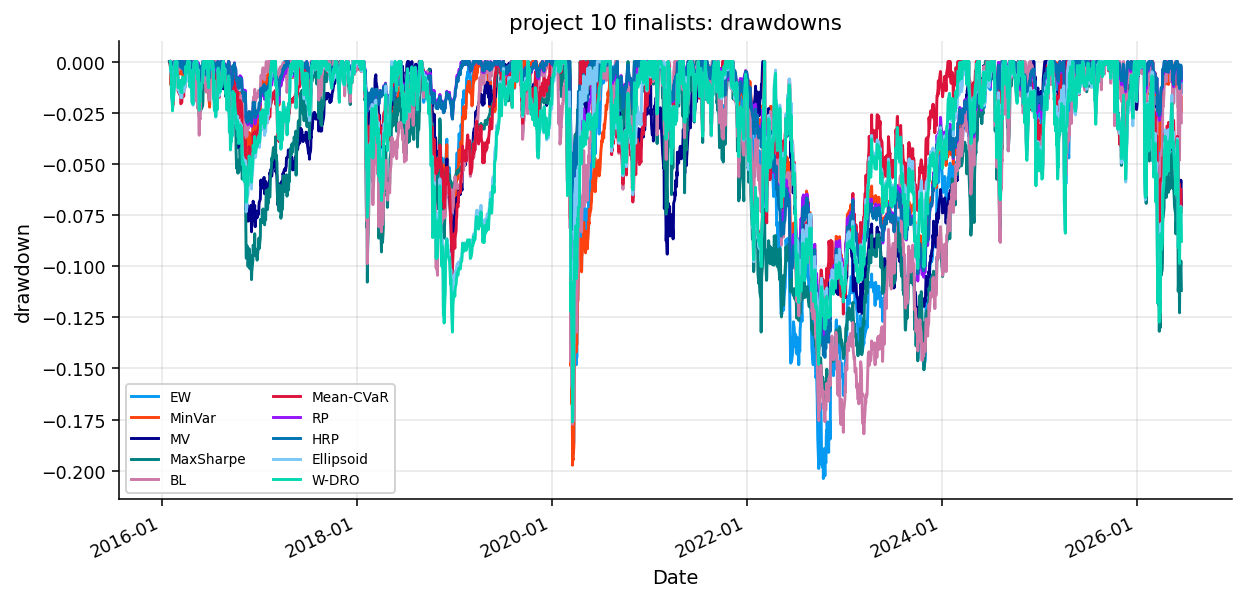

In [32]:
selected_nav = pd.DataFrame({name: results[name].net_values for name in selected_models}).dropna(how="all")
fig, ax = plt.subplots(figsize=(9.0, 4.4))
plot_strategy_drawdowns(selected_nav[selected_models], ax=ax, title="project 10 finalists: drawdowns", labels=short_labels(selected_models))
ax.set_ylabel("drawdown")
small_legend(ax, loc="lower left")
plt.tight_layout()
plt.show()


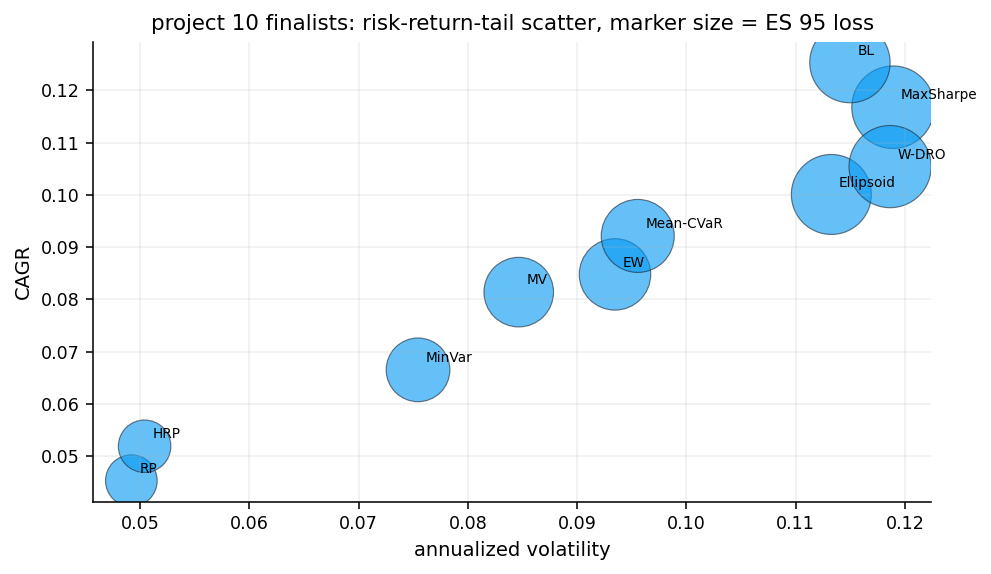

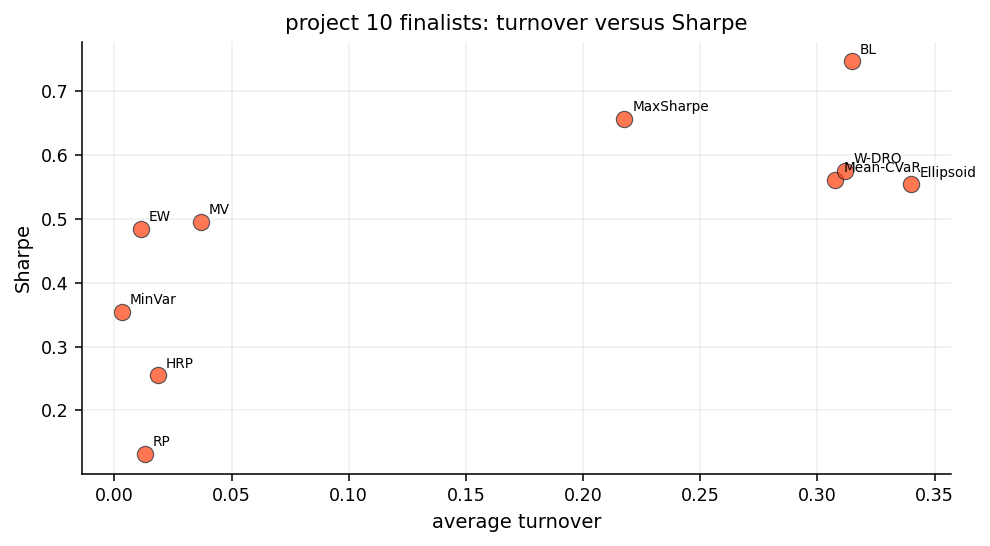

In [33]:
scatter_data = selected_scoreboard.copy()
fig, ax = plt.subplots(figsize=(7.2, 4.2))
size = 1800 * scatter_data["es_95"].abs() / scatter_data["es_95"].abs().max()
ax.scatter(scatter_data["ann_vol"], scatter_data["cagr"], s=size, alpha=0.62, color=colors[0], edgecolor="#1f2937", linewidth=0.6)
for name, row in scatter_data.iterrows():
    ax.annotate(short_label_map.get(name, name), (row["ann_vol"], row["cagr"]), xytext=(4, 4), textcoords="offset points", fontsize=7)
ax.set_title("project 10 finalists: risk-return-tail scatter, marker size = ES 95 loss")
ax.set_xlabel("annualized volatility")
ax.set_ylabel("CAGR")
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.scatter(scatter_data["avg_turnover"], scatter_data["sharpe"], s=70, alpha=0.72, color=colors[1], edgecolor="#1f2937", linewidth=0.6)
for name, row in scatter_data.iterrows():
    ax.annotate(short_label_map.get(name, name), (row["avg_turnover"], row["sharpe"]), xytext=(4, 4), textcoords="offset points", fontsize=7)
ax.set_title("project 10 finalists: turnover versus Sharpe")
ax.set_xlabel("average turnover")
ax.set_ylabel("Sharpe")
plt.tight_layout()
plt.show()


The risk-return-tail scatter is useful because marker size represents ES 95 loss. Models in the upper-right deliver more return but also carry larger tail losses. Models in the lower-left are safer but less rewarding.

The scatter makes three groups visible:

1. **Return-oriented group:** BL, MaxSharpe, W-DRO, Ellipsoid Robust. These have higher CAGR and higher volatility, with larger tail markers.
2. **Balanced tail-budget group:** Mean-CVaR and MV. They sit lower in return than BL but have more controlled drawdown and ES.
3. **Defensive group:** Risk Parity, HRP, MinVar. These control volatility and ES but give up too much return.

The turnover-versus-Sharpe plot adds implementation realism. BL has the highest Sharpe but also high turnover. W-DRO and Ellipsoid Robust MV also have high turnover. MinVar, Equal Weight, Risk Parity, and HRP have much lower turnover, but lower Sharpe.

Trading cost is already included, but turnover still matters. A model with high turnover needs liquid assets, low slippage, and stable execution. In ETFs this is more plausible than in small stocks, but it is still a real implementation cost.

## 14) Average Weights and Sleeve Exposures

Average holdings reveal the mechanism behind each model.

Equal Weight holds 7.14% in every asset by construction. MinVar and MV both allocate heavily to SHY, with MV also holding GLD and QQQ. MaxSharpe holds QQQ, GLD, and SHY as its top average positions. BL is more equity-oriented, with top average holdings in SPY, QQQ, and EFA.

Mean-CVaR holds SHY, GLD, and DBC as its top average positions. This makes sense: it wants return, but under a tail constraint, so it uses assets that have historically helped tail behavior or inflation regimes. Risk Parity and HRP are both dominated by SHY and bond-like exposures. Ellipsoid Robust and Wasserstein DRMV both hold GLD, DBC, and QQQ as major average positions, consistent with robust return-seeking behavior.

The sleeve table summarizes this even better:

- BL has the largest equity sleeve at 56.33%.
- Risk Parity has 57.90% duration.
- HRP has 60.45% duration.
- Mean-CVaR has 31.45% diversifiers and 36.25% duration.
- Ellipsoid Robust and W-DRO have the largest diversifier exposure, around 35-36%.

This tells us the models aren't just changing weights randomly. Their objectives map into clear economic sleeve preferences.

,model,asset,avg_weight
0,Equal Weight,SPY,0.0714
1,Equal Weight,QQQ,0.0714
2,Equal Weight,IWM,0.0714
3,MinVar (OAS),SHY,0.2284
4,MinVar (OAS),SPY,0.0840
5,MinVar (OAS),GLD,0.0826
6,"MV (LedoitWolf, BayesStein)",SHY,0.2388
7,"MV (LedoitWolf, BayesStein)",GLD,0.1740
8,"MV (LedoitWolf, BayesStein)",QQQ,0.1152
9,"MaxSharpe (Sample, BayesSteinMomentum)",QQQ,0.1702


,avg_equities,avg_duration,avg_credit,avg_diversifiers,avg_effective_n,avg_max_weight
Equal Weight,0.3571,0.2857,0.1429,0.2143,14.0000,0.0714
MinVar (OAS),0.2668,0.4135,0.1298,0.1900,9.1680,0.2394
"MV (LedoitWolf, BayesStein)",0.2137,0.4676,0.0399,0.2788,5.0557,0.3212
"MaxSharpe (Sample, BayesSteinMomentum)",0.4261,0.2697,0.0540,0.2502,3.2046,0.3897
Learned-Confidence BL,0.5633,0.2203,0.0231,0.1932,5.2021,0.2724
Mean-CVaR 95,0.2208,0.3625,0.1023,0.3145,3.3662,0.3887
Risk Parity,0.0999,0.5790,0.1928,0.1283,5.9635,0.3498
HRP,0.1462,0.6045,0.1337,0.1156,5.0967,0.4000
Ellipsoid Robust MV,0.3221,0.2604,0.0636,0.3540,3.1440,0.3922
Wasserstein DRMV,0.3617,0.2186,0.0592,0.3604,3.7144,0.3632


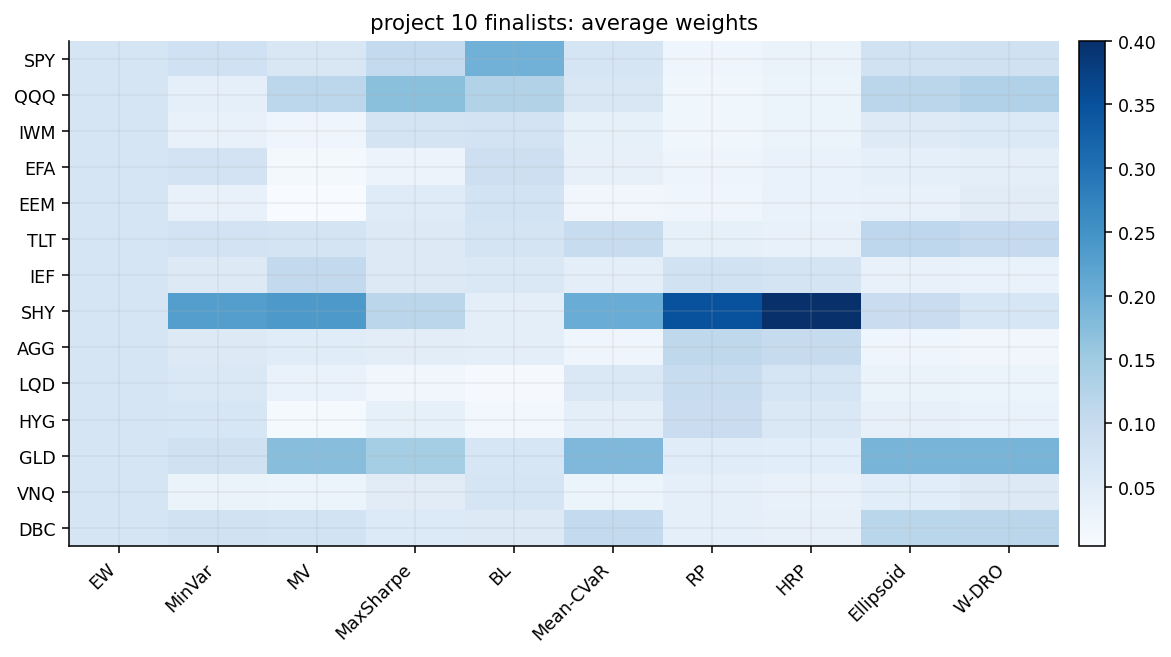

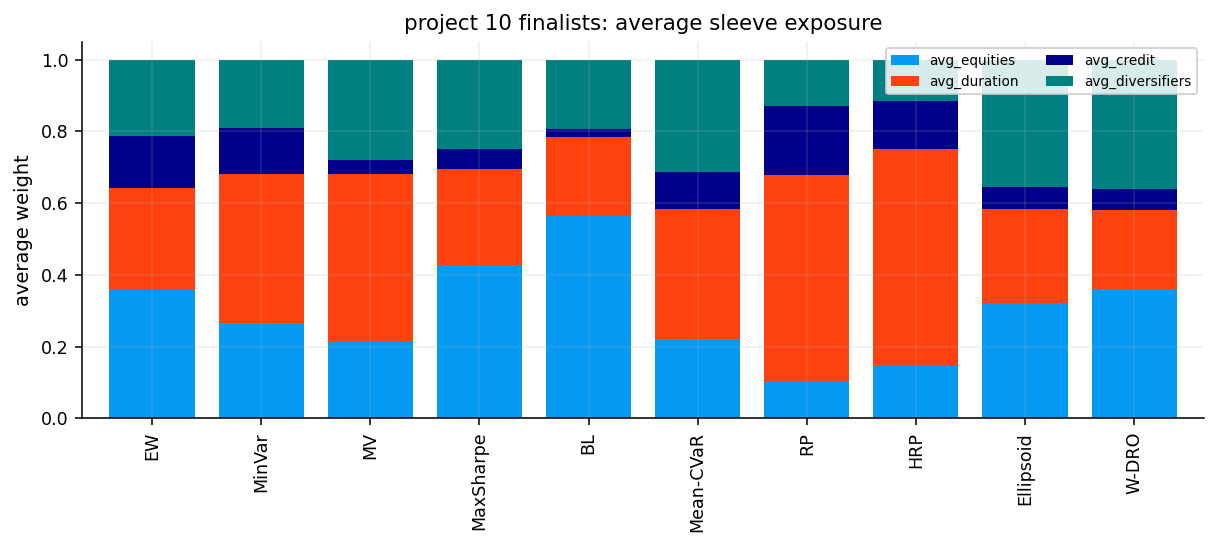

In [34]:
average_weights = pd.DataFrame({name: results[name].weights.reindex(columns=assets).mean() for name in selected_models}).reindex(assets)

def average_sleeves(result):
    w = result.weights.reindex(columns=assets).fillna(0.0)
    row = {}
    for sleeve, members in sleeve_groups.items():
        row[f"avg_{sleeve}"] = float(w[members].sum(axis=1).mean())
    row["avg_effective_n"] = float((1.0 / (w.pow(2).sum(axis=1))).replace([np.inf, -np.inf], np.nan).mean())
    row["avg_max_weight"] = float(w.max(axis=1).mean())
    return row

sleeve_exposure = pd.DataFrame({name: average_sleeves(results[name]) for name in selected_models}).T
top_average_holdings = []
for name in selected_models:
    for asset, value in average_weights[name].nlargest(3).items():
        top_average_holdings.append({"model": name, "asset": asset, "avg_weight": value})
top_average_holdings = pd.DataFrame(top_average_holdings)
display(top_average_holdings.round(4))
display(sleeve_exposure.round(4))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
im = ax.imshow(average_weights.fillna(0.0).values, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(average_weights.columns)))
ax.set_xticklabels(short_labels(average_weights.columns), rotation=45, ha="right")
ax.set_yticks(range(len(average_weights.index)))
ax.set_yticklabels(average_weights.index)
ax.set_title("project 10 finalists: average weights")
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
plt.tight_layout()
plt.show()
sleeve_cols = [f"avg_{s}" for s in sleeve_groups]
sleeve_plot = sleeve_exposure[sleeve_cols].copy()
sleeve_plot.index = short_labels(sleeve_plot.index)
ax = sleeve_plot.plot(kind="bar", stacked=True, figsize=(8.8, 4.0), width=0.78)
ax.set_title("project 10 finalists: average sleeve exposure")
ax.set_ylabel("average weight")
small_legend(ax, loc="upper right")
plt.tight_layout()
plt.show()


The average-weight heatmap reinforces the concentration story. Risk Parity and HRP place major weight in SHY and bond assets. Robust models put large average weight in GLD, DBC, QQQ, and sometimes EEM. BL distributes more across equity names and avoids the extremely defensive structure of parity models.

Effective $N$ helps quantify concentration:

$$
N_{\text{eff}}=\frac{1}{\sum_{i=1}^{N}w_i^2}
$$

Equal Weight has $N_{\text{eff}}=14$ because all weights are equal. If a model holds only three or four large positions, effective $N$ falls. MaxSharpe has effective $N$ around 3.20, Mean-CVaR around 3.37, Ellipsoid around 3.14, and W-DRO around 3.71. BL is more diversified at 5.20.

This is one of the clearest practical differences between BL and robust MV. BL is active and high-turnover, but it keeps more positions alive because the view structure and constraints distribute active bets. Robust MV models are more concentrated because a few assets survive the expected-return penalty and then hit caps.

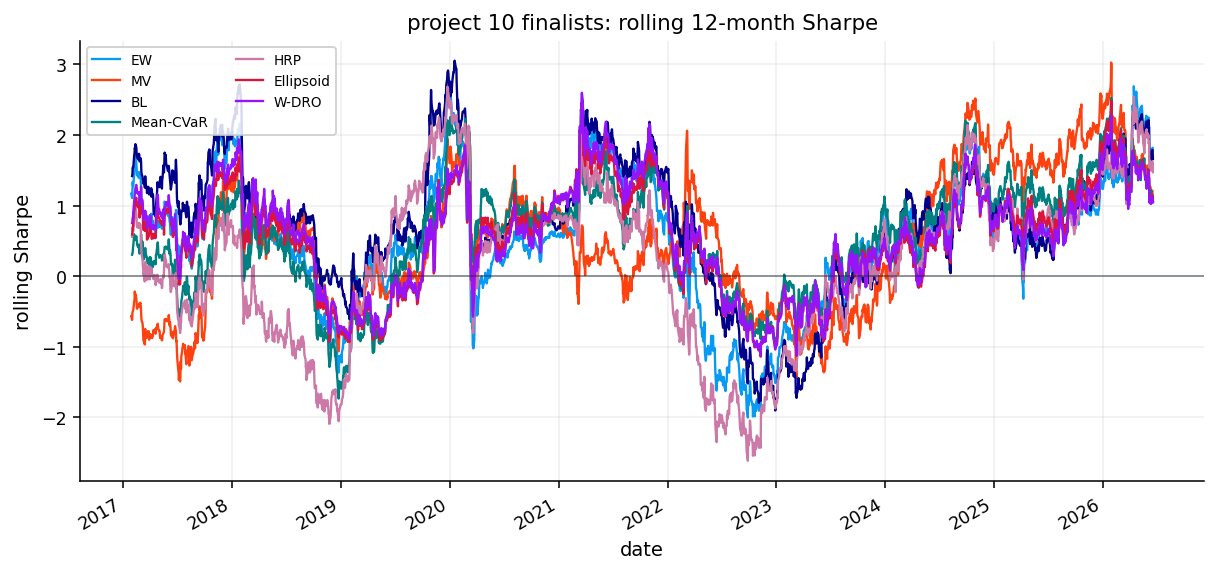

date,latest_12m_return
Equal Weight,0.1883
"MV (LedoitWolf, BayesStein)",0.1811
Learned-Confidence BL,0.2702
Mean-CVaR 95,0.1702
HRP,0.1092
Ellipsoid Robust MV,0.2274
Wasserstein DRMV,0.2256


In [35]:
selected_returns = pd.DataFrame({name: results[name].net_returns for name in selected_models}).dropna(how="all")
rolling_return_252 = (1.0 + selected_returns).rolling(252).apply(np.prod, raw=True) - 1.0
rolling_vol_252 = selected_returns.rolling(252).std() * np.sqrt(annualization)
rolling_mean_252 = selected_returns.rolling(252).mean() * annualization
rolling_sharpe_252 = (rolling_mean_252 - risk_free_rate_annual) / rolling_vol_252

rolling_plot_names = selected_models
if len(rolling_plot_names) > 7:
    rolling_plot_names = list(dict.fromkeys(["Equal Weight", best_mv_name, "Learned-Confidence BL", best_cvar_name, best_hier_name, best_robust_name, "Wasserstein DRMV"]))

fig, ax = plt.subplots(figsize=(8.8, 4.2))
rolling_sharpe_252[rolling_plot_names].rename(columns=dict(zip(rolling_plot_names, short_labels(rolling_plot_names)))).plot(ax=ax, linewidth=1.2)
ax.axhline(0.0, color="#1f2937", linewidth=0.8, alpha=0.6)
ax.set_title("project 10 finalists: rolling 12-month Sharpe")
ax.set_ylabel("rolling Sharpe")
small_legend(ax, loc="upper left")
plt.tight_layout()
plt.show()

display(rolling_return_252[rolling_plot_names].tail(1).T.rename(columns={rolling_return_252.index[-1]: "latest_12m_return"}).round(4))


The rolling 12-month Sharpe plot shows that no model dominates every regime. Around the COVID crash and 2022 inflation shock, Sharpe ratios shift quickly. Models that looked good during equity rallies can deteriorate when inflation or rates dominate. Defensive models can lag badly during strong risk-on recoveries.

The latest 12-month return table shows BL leading at 27.02%, followed by Wasserstein DRMV at 22.56% and Ellipsoid Robust MV at 22.74%. Equal Weight is at 18.83%, MV at 18.11%, Mean-CVaR at 17.02%, and HRP at 10.92%.

This recent period is clearly favorable to active and robust return-seeking models. The robust models are not simply defensive. In the recent window, they participate strongly because their selected exposures, especially GLD/DBC/QQQ/EEM-type positions, performed well. HRP lags because the duration-heavy defensive allocation doesn't match the current return environment.

Rolling Sharpe is useful because it prevents a single full-sample metric from hiding regime changes. A model can have a good full-sample Sharpe but still be very weak in a specific macro regime.

,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
BL,0.0109,0.0176,0.0119,0.0230,0.0199,0.0290
EW,0.0086,0.0139,0.0091,0.0243,0.0119,0.0182
Ellipsoid,0.0112,0.0174,0.0120,0.0220,0.0229,0.0331
HRP,0.0047,0.0075,0.0048,0.0110,0.0060,0.0091
MV,0.0083,0.0132,0.0089,0.0170,0.0144,0.0209
MaxSharpe,0.0115,0.0186,0.0122,0.0223,0.0213,0.0314
Mean-CVaR,0.0090,0.0145,0.0099,0.0198,0.0123,0.0180
MinVar,0.0066,0.0111,0.0072,0.0276,0.0086,0.0132
RP,0.0045,0.0073,0.0047,0.0121,0.0060,0.0090


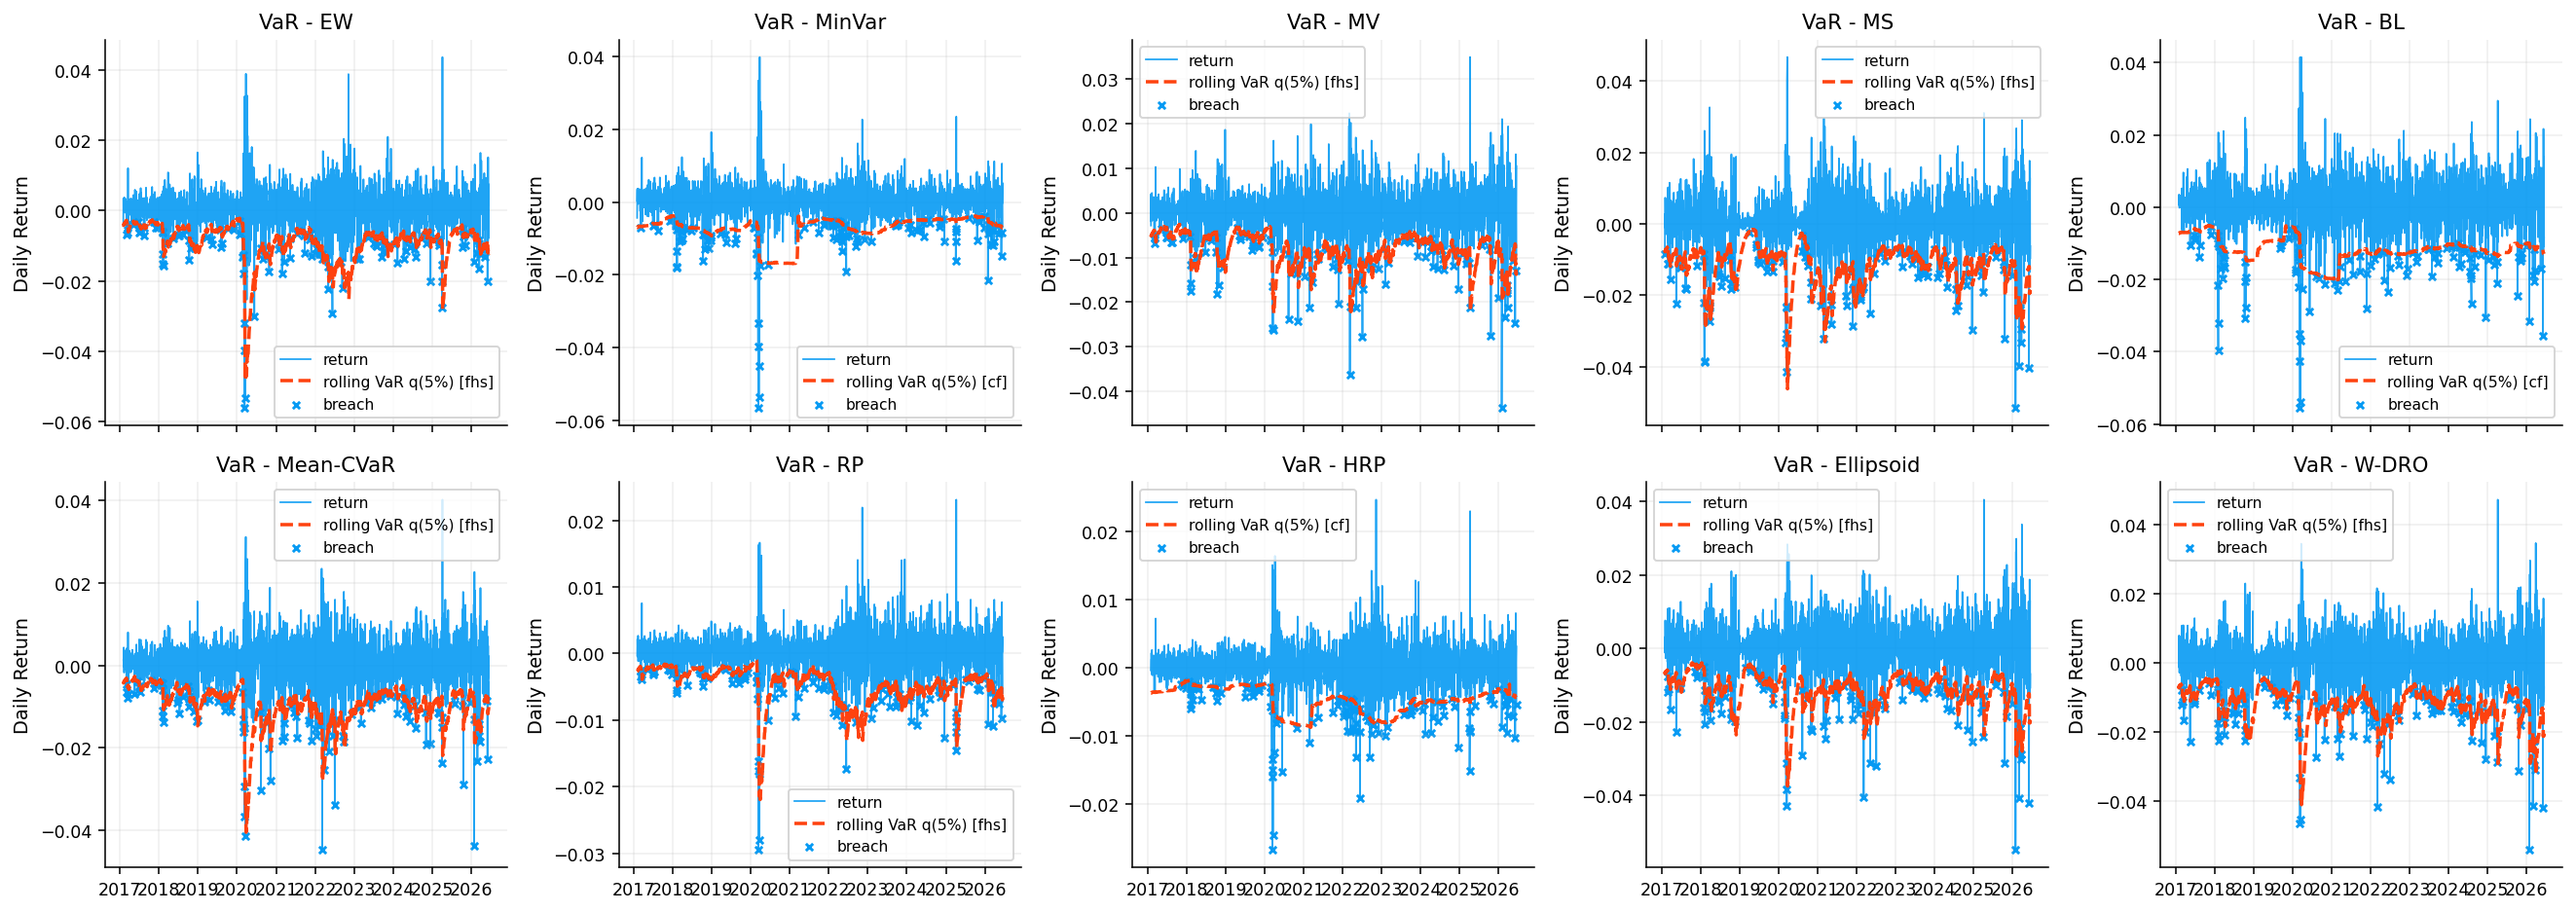

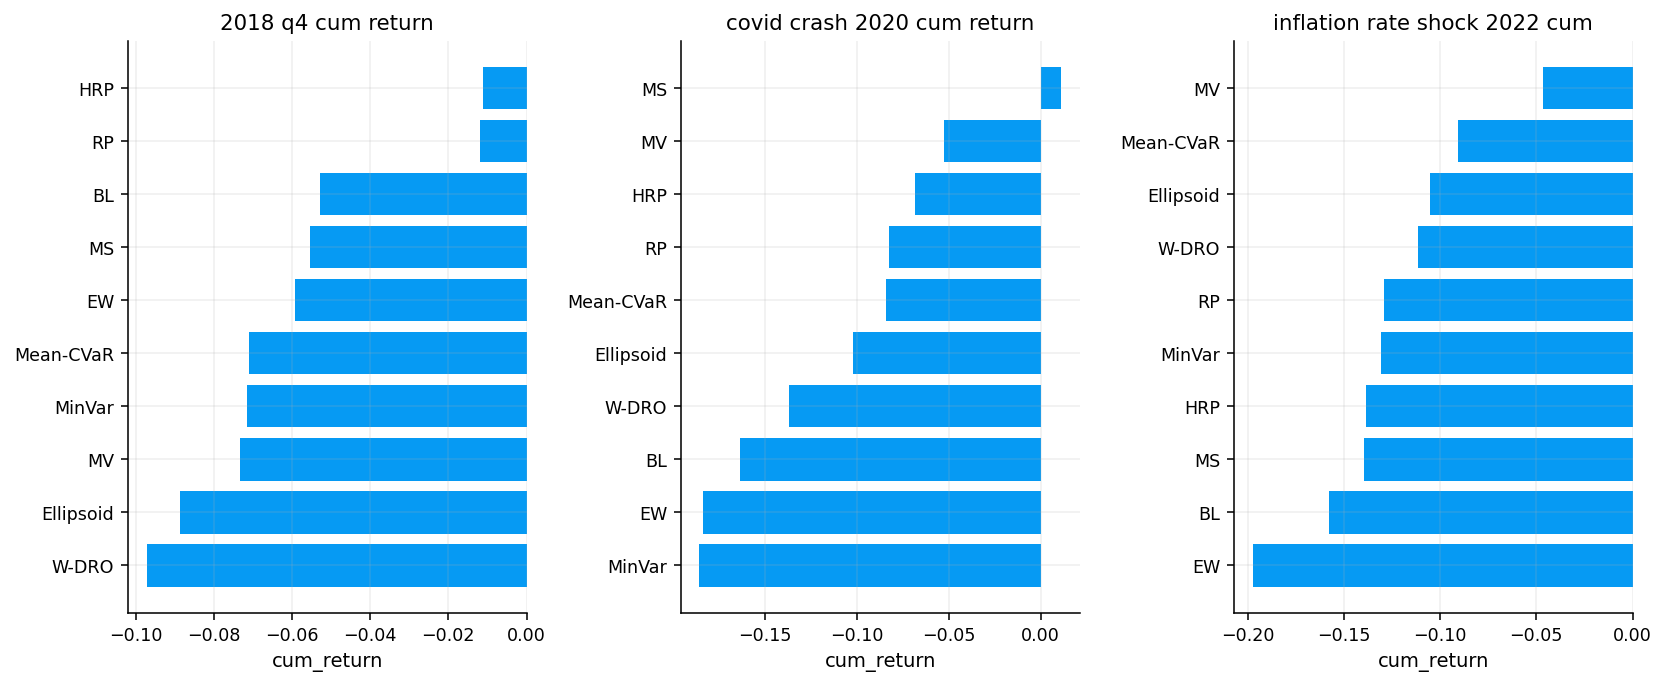

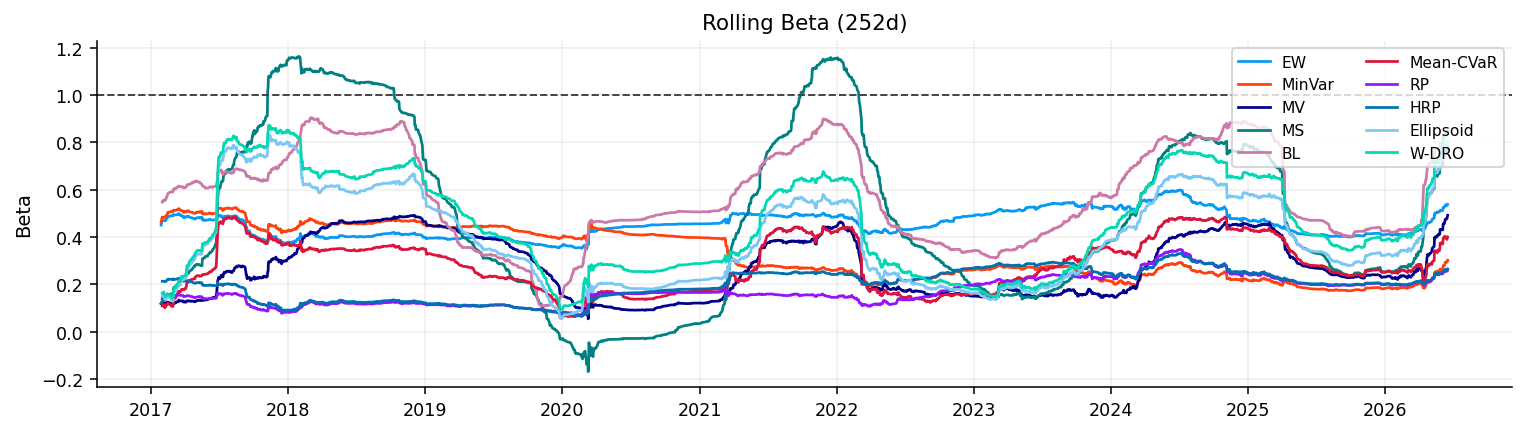

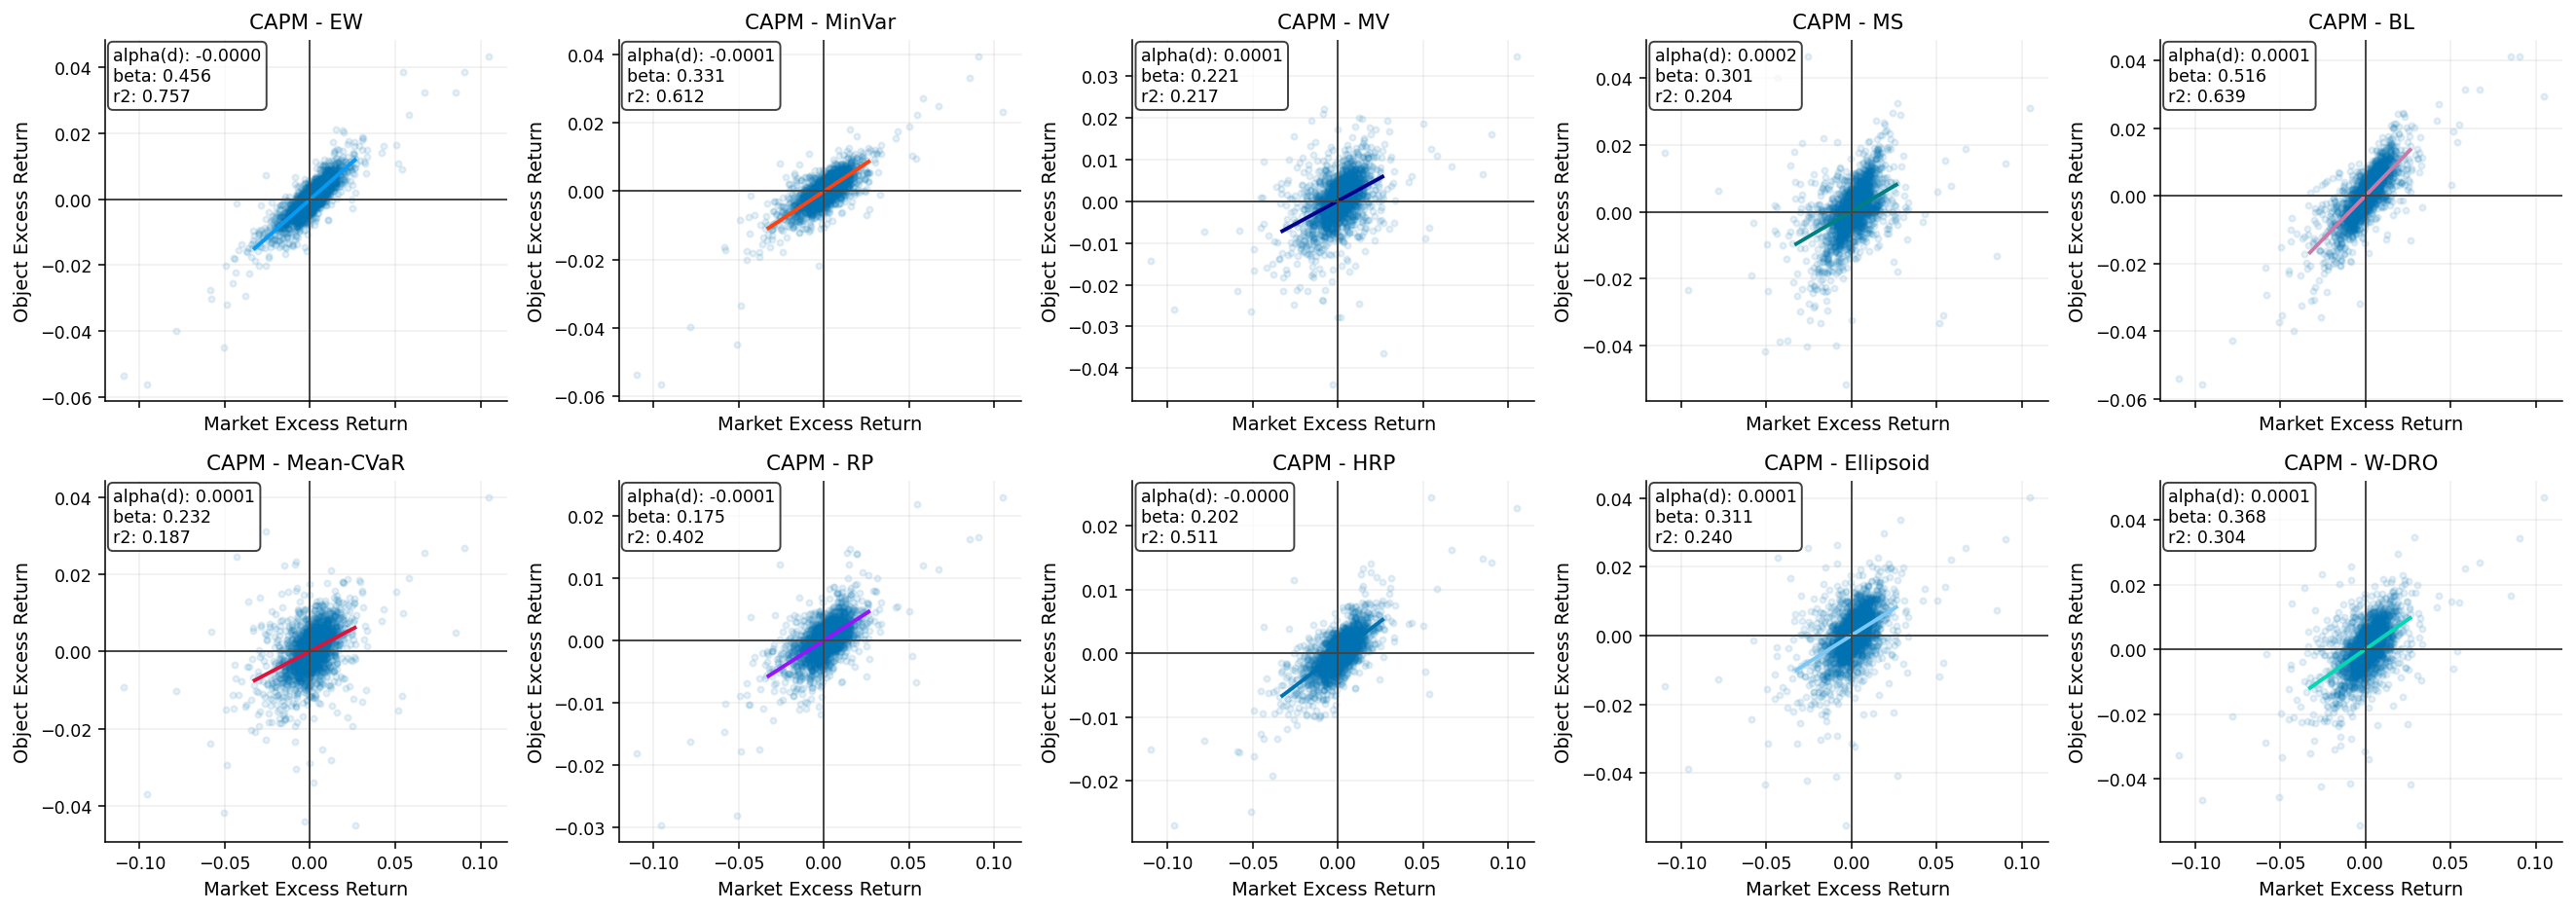

In [36]:
risk_returns = selected_returns.dropna(how="all")
stress_windows = {
    "2018_q4": ("2018-10-01", "2018-12-31"),
    "covid_crash_2020": ("2020-02-19", "2020-03-23"),
    "inflation_rate_shock_2022": ("2022-01-03", "2022-10-14"),
}

spy_ref = returns["SPY"].reindex(risk_returns.index).dropna()
label_overrides = dict(zip(selected_models, short_labels(selected_models)))
risk_report_artifacts = risk_report(
    objects={name: risk_returns[name] for name in selected_models},
    market_ret=spy_ref,
    rf_daily=risk_free_daily,
    include={"performance_tables": False, "shape_tables": False, "drawdowns": False, "drawdown_episodes": False, "var_es": True, "var_backtest": True, "stress": True, "capm": True, "rolling_beta": True, "correlation": False, "attribution": False, "exec_bullets": False},
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    rolling_settings={"vol_windows": [252], "beta_windows": [252]},
    stress_settings={"windows": stress_windows, "worst_only": False},
    layout={"ncols": 5, "sharex": True, "sharey": False},
    output={"display_table_keys": ["var_es"], "round_tables": 4, "print_exec_bullets": False, "show_figures": False, "short_labels": True, "label_max_len": 12, "label_map": label_overrides},
)
risk_report_tables = risk_report_artifacts.tables
stress = risk_report_artifacts.series.get("stress_full", risk_report_tables.get("stress"))
var_es = risk_report_tables["var_es"]
var_backtest = risk_report_tables["var_backtest"]
for key in ["var_backtest", "stress", "rolling_beta"]:
    for fig in risk_report_artifacts.figures.get(key, []):
        display(fig)
        plt.close(fig)


## 15) Risk Report: VaR, ES, Stress, and Beta

The risk report gives a more formal tail and stress comparison. The historical VaR/ES table confirms the earlier ranking:

- Risk Parity has the lowest historical ES at 0.73%.
- HRP is next at 0.75%.
- MinVar has ES 1.11%.
- MV has ES 1.32%.
- Mean-CVaR has ES 1.45%.
- BL, Ellipsoid, MaxSharpe, and W-DRO have ES around 1.74-1.86%.

The filtered historical simulation (FHS) ES is more severe for the aggressive and robust return-seeking models. BL has FHS ES 2.90%, MaxSharpe 3.14%, Ellipsoid 3.31%, and W-DRO 3.30%. This tells us that when recent volatility is used to scale historical returns, the tail risk of the aggressive models looks larger.

That doesn't mean those models are bad. It means their return advantage comes with genuine downside exposure. Mean-CVaR's FHS ES is much lower at 1.80%, and Risk Parity/HRP remain below 1%. The tail-aware models are doing their job in risk units.

The stress-window plots compare models across 2018 Q4, the COVID crash, and the 2022 inflation/rate shock. These windows are useful because they stress different portfolio weaknesses:

- **2018 Q4** stresses equity beta and growth exposure.
- **COVID crash** stresses sudden liquidity-driven cross-asset selling.
- **2022 inflation/rate shock** stresses both stocks and duration bonds at the same time.

Risk Parity and HRP usually look better in pure equity drawdowns because they carry more duration and lower equity risk. However, 2022 is more complicated because duration itself was under pressure. Mean-CVaR is often more balanced because its tail budget can shift toward assets that helped in recent tail windows, but it still depends on the rolling scenarios.

BL and MaxSharpe have more upside capture but can lose more in sharp shocks. W-DRO and Ellipsoid Robust MV are meant to reduce input fragility, not eliminate market exposure. So they can still experience large stress losses if the assets they select are hit together.

The rolling beta plots show the same theme. Defensive models have lower market beta. Active return-seeking models have higher and more variable beta. A model's Sharpe ratio alone doesn't show this exposure path.

In [37]:

criterion_rows = []
criteria = [
    ("highest cagr", "cagr", False),
    ("highest sharpe", "sharpe", False),
    ("highest sortino", "sortino", False),
    ("highest calmar", "calmar", False),
    ("lowest max drawdown", "max_drawdown", False),
    ("lowest es 95", "es_95", True),
    ("lowest avg turnover", "avg_turnover", True),
    ("highest avg effective n", "avg_effective_n", False),
]
for criterion, column, ascending in criteria:
    values = selected_scoreboard[column].dropna()
    winner = values.sort_values(ascending=ascending).index[0]
    criterion_rows.append({"criterion": criterion, "winner": winner, "value": values.loc[winner]})

rank_data = selected_scoreboard.copy()
rank_table = pd.DataFrame(index=rank_data.index)
rank_table["sharpe_rank"] = rank_data["sharpe"].rank(ascending=False, method="min")
rank_table["calmar_rank"] = rank_data["calmar"].rank(ascending=False, method="min")
rank_table["es_95_rank"] = rank_data["es_95"].rank(ascending=True, method="min")
rank_table["max_drawdown_rank"] = rank_data["max_drawdown"].rank(ascending=False, method="min")
rank_table["avg_turnover_rank"] = rank_data["avg_turnover"].rank(ascending=True, method="min")
rank_table["avg_effective_n_rank"] = rank_data["avg_effective_n"].rank(ascending=False, method="min")
rank_table["balanced_rank_score"] = (
    0.25 * rank_table["sharpe_rank"]
    + 0.20 * rank_table["calmar_rank"]
    + 0.20 * rank_table["es_95_rank"]
    + 0.15 * rank_table["max_drawdown_rank"]
    + 0.10 * rank_table["avg_turnover_rank"]
    + 0.10 * rank_table["avg_effective_n_rank"]
)
rank_table = rank_table.sort_values("balanced_rank_score")
criterion_rows.append({"criterion": "best balanced rank", "winner": rank_table.index[0], "value": rank_table.iloc[0]["balanced_rank_score"]})

display(pd.DataFrame(criterion_rows).set_index("criterion").round(4))
display(rank_table.round(3))


,winner,value
criterion,,
highest cagr,Learned-Confidence BL,0.1253
highest sharpe,Learned-Confidence BL,0.7458
highest sortino,Learned-Confidence BL,0.9287
highest calmar,"MaxSharpe (Sample, BayesSteinMomentum)",0.7065
lowest max drawdown,Risk Parity,-0.1374
lowest es 95,Risk Parity,0.0073
lowest avg turnover,MinVar (OAS),0.0031
highest avg effective n,Equal Weight,14.0000
best balanced rank,Learned-Confidence BL,4.7500


,sharpe_rank,calmar_rank,es_95_rank,max_drawdown_rank,avg_turnover_rank,avg_effective_n_rank,balanced_rank_score
Strategy,,,,,,,
Learned-Confidence BL,1.0,2.0,8.0,8.0,9.0,4.0,4.75
"MV (LedoitWolf, BayesStein)",6.0,6.0,4.0,2.0,5.0,6.0,4.90
Mean-CVaR 95,4.0,4.0,6.0,4.0,7.0,8.0,5.10
"MaxSharpe (Sample, BayesSteinMomentum)",2.0,1.0,10.0,6.0,6.0,9.0,5.10
Risk Parity,10.0,10.0,1.0,1.0,3.0,3.0,5.45
HRP,9.0,8.0,2.0,3.0,4.0,5.0,5.60
Equal Weight,7.0,7.0,5.0,10.0,2.0,1.0,5.95
Ellipsoid Robust MV,5.0,3.0,7.0,5.0,10.0,10.0,6.00
MinVar (OAS),8.0,9.0,3.0,9.0,1.0,2.0,6.05


## 16) Balanced Ranking

The criterion table gives winners by specific objective:

- Highest CAGR: Learned-Confidence BL.
- Highest Sharpe: Learned-Confidence BL.
- Highest Sortino: Learned-Confidence BL.
- Highest Calmar: MaxSharpe.
- Lowest max drawdown: Risk Parity.
- Lowest ES 95: Risk Parity.
- Lowest turnover: MinVar.
- Highest effective $N$: Equal Weight.
- Best balanced rank: Learned-Confidence BL.

The balanced rank score combines Sharpe, Calmar, ES, drawdown, turnover, and diversification. BL wins because its return quality is strong enough to overcome its weaker tail and turnover ranks. MV comes second in balanced rank because it has excellent drawdown and reasonable turnover even though it doesn't lead return metrics. Mean-CVaR and MaxSharpe tie closely after that, but for different reasons: Mean-CVaR is better on risk control, MaxSharpe is better on return and Calmar.

This ranking is useful because there is no universal "best" portfolio. A pension-style allocator might prefer Mean-CVaR or MV because drawdown and ES matter more. A return-seeking ETF strategy might prefer BL or W-DRO. A defensive allocation sleeve might prefer Risk Parity or HRP. The table makes those tradeoffs explicit rather than hiding them behind one metric.

In [38]:

selected_reason_lookup = selected_reason["role"].to_dict()
selected_from_lookup = selected_reason["selected_from"].to_dict()
final_comparison = selected_scoreboard[["cagr", "sharpe", "calmar", "max_drawdown", "es_95", "avg_turnover", "avg_effective_n"]].copy()
final_comparison.insert(0, "role", [selected_reason_lookup[name] for name in final_comparison.index])
final_comparison.insert(0, "model", final_comparison.index)
final_comparison["selected_reason"] = [selected_from_lookup[name] for name in final_comparison["model"]]
final_comparison = final_comparison.reset_index(drop=True)
display(final_comparison.round(4))


,model,role,cagr,sharpe,calmar,max_drawdown,es_95,avg_turnover,avg_effective_n,selected_reason
0,Equal Weight,baseline,0.0848,0.4842,0.4159,-0.2038,0.0139,0.0114,14.0000,project 2 grid
1,MinVar (OAS),minimum variance benchmark,0.0665,0.3543,0.3370,-0.1973,0.0111,0.0031,9.1680,project 2 grid
2,"MV (LedoitWolf, BayesStein)",mean-variance benchmark,0.0814,0.4949,0.5904,-0.1378,0.0132,0.0369,5.0557,project 2 grid
3,"MaxSharpe (Sample, BayesSteinMomentum)",sharpe/frontier benchmark,0.1168,0.6553,0.7065,-0.1653,0.0186,0.2177,3.2046,project 2 grid
4,Learned-Confidence BL,black-litterman benchmark,0.1253,0.7458,0.6888,-0.1820,0.0176,0.3147,5.2021,project 6 rebuild
5,Mean-CVaR 95,tail-risk allocation,0.0921,0.5609,0.6305,-0.1461,0.0145,0.3077,3.3662,Min-CVaR 95 vs Mean-CVaR 95
6,Risk Parity,risk budget allocation,0.0453,0.1320,0.3295,-0.1374,0.0073,0.0131,5.9635,single specified model
7,HRP,hierarchical allocation,0.0519,0.2547,0.3586,-0.1446,0.0075,0.0186,5.0967,HRP vs NCO-MV
8,Ellipsoid Robust MV,robust mean-variance,0.1001,0.5533,0.6421,-0.1559,0.0174,0.3401,3.1440,Box Robust MV vs Ellipsoid Robust MV
9,Wasserstein DRMV,distributionally robust allocation,0.1054,0.5743,0.5986,-0.1761,0.0184,0.3119,3.7144,single specified model


The final comparison table is the cleanest version of the project result.

BL is the strongest all-around performer in this sample: 12.53% CAGR, 0.7458 Sharpe, 0.6888 Calmar. Its cost is turnover and meaningful tail risk. MaxSharpe is the best pure frontier-style baseline, with 11.68% CAGR and 0.7065 Calmar, but it has the highest ES among finalists.

Mean-CVaR earns a smaller 9.21% CAGR but gives a much better max drawdown than BL and a lower ES. That makes it the strongest tail-aware growth model. Risk Parity and HRP are defensive risk-control models. They reduce ES and drawdown, but their returns are too low to win in a risk-free-rate-aware Sharpe comparison.

Ellipsoid Robust MV and Wasserstein DRMV sit between MaxSharpe and Mean-CVaR. They preserve return better than the defensive models while adding uncertainty penalties to the optimizer. W-DRO is the stronger robust model by Sharpe and CAGR, while Ellipsoid has slightly better drawdown and Calmar.

This is the main result of Project 10: changing the risk definition changes the economic personality of the portfolio. Variance, tail loss, risk contribution, clustering, mean uncertainty, and distributional ambiguity all produce different portfolios, and those differences are visible in performance, drawdown, turnover, concentration, and sleeve exposure.

There is also a useful design lesson in the ranking. The models that explicitly optimize a risk measure are not automatically the best full-portfolio strategies. Min-CVaR, Risk Parity, and HRP all optimize or organize risk very carefully, but they underperform because they don't take enough rewarded risk in this sample.

The models that use expected returns more aggressively, BL, MaxSharpe, robust MV, and W-DRO, perform better on CAGR and Sharpe. But their tails are larger and their turnover is higher. The successful models are the ones that balance a return engine with a risk-control mechanism:

- BL uses Bayesian priors, learned confidence, constraints, and active views.
- MaxSharpe uses the frontier but accepts concentration.
- Mean-CVaR uses expected returns but caps the tail.
- Robust MV uses expected returns but haircuts uncertainty.
- W-DRO uses expected returns but taxes distributional ambiguity and concentration.

This is why Project 10 is a natural bridge between classical portfolio theory and more modern robust allocation. It doesn't replace mean-variance with one superior model. It shows how each objective creates a different definition of "reasonable" portfolio behavior.

## 17) Sector ETF Repeat with the Library

The final cell repeats the same model families on a sector ETF universe using library-level functions. This secondary application matters because the sector universe has a different structure from cross-asset ETFs.

The cross-asset universe contains equities, bonds, credit, gold, real estate, and commodities. Sector ETFs are all equity sectors. They share a common market beta, and diversification comes mostly from sector rotation rather than asset-class diversification.

The data is reproduced from the [`sector_etfs`](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/sector_etfs) folder, with cross-asset signal data coming from [`core_cross_asset_etfs`](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/core_cross_asset_etfs). We don't link to direct generated files because the repository's data layer is organized by source folders, each with its own reproducibility notes and scripts.

The sector tradable universe is:

$$
\{XLK, XLC, XLY, XLF, XLI, XLE, XLB, XLV, XLP, XLU, XLRE\}
$$

The sector run starts in 2018-07-03 and has 2,000 return rows, with monthly rebalances from 2020-07-31 to 2026-06-17. The shorter history is caused by sector ETF availability, especially XLC.

The sector repeat uses the same model families, but the interpretation changes.

In the cross-asset universe, Risk Parity can diversify across stocks, bonds, credit, and real assets. In the sector universe, Risk Parity can only diversify across sectors that all still have equity beta. So risk control is less powerful. A defensive sector like XLP or XLV may fall less than XLK in a crash, but it is still an equity ETF.

The BL sector views are also sector-specific:

- sector momentum,
- growth leadership,
- defensive rotation,
- cyclical breadth,
- credit beta,
- inflation beneficiaries,
- duration-sensitive sectors,
- small-cap risk-on,
- quality defensive,
- sector reversal.

The sector BL run generates 310 candidate views and 280 selected views. This confirms that the view engine is active, but the benchmark is equal weight across sectors rather than a multi-asset strategic benchmark. That makes the secondary run closer to a sector-rotation experiment than a full asset-allocation experiment.

Sector ETFs also make the robust-model question harder. In the cross-asset universe, a robust model can move toward gold, commodities, short duration, or emerging markets when those exposures survive the uncertainty penalty. In sectors, all assets are still claims on US equity cash flows. Even Energy and Utilities are different sectors, not different asset classes.

This reduces the value of some risk models. Risk parity can lower sector concentration, but it can't create a Treasury hedge. CVaR can favor defensive sectors, but those sectors can still fall with the market. Wasserstein DRO can penalize concentration, but if all sectors become correlated in a crash, the distributional ambiguity doesn't magically create an uncorrelated asset.

At the same time, sector rotation is a better environment for MaxSharpe when the winning sectors have persistent leadership. Technology, Communication Services, Consumer Discretionary, and Energy can dominate certain periods, and a return-seeking optimizer can capture that leadership if the signal is stable enough.

So the secondary application is not just a replication. It checks whether the model family survives when the diversification mechanism changes from asset-class allocation to intra-equity rotation.

sector returns: (2000, 11) 2018-07-03 to 2026-06-17
rebalance dates: 72 2020-07-31 to 2026-06-17
selected grid models: {'MinVar': 'MinVar (LedoitWolf)', 'MV': 'MV (EWMA, BayesStein)', 'MaxSharpe': 'MaxSharpe (Sample, BayesStein)'}
selected robust models: {'cov': 'EWMA', 'mu': 'BayesStein', 'lambda': 1.5, 'wasserstein_lambda': 1.0, 'box_radius': 0.1, 'ellipsoid_radius': 0.05, 'wasserstein_radius': 2.0}
BL view rows: 310 candidate, 280 selected


,CAGR,Vol,Sharpe,Sortino,Calmar,Max Drawdown,Turnover,Effective N
Strategy,,,,,,,,
Equal Weight,0.1471,0.1475,0.7352,1.0058,0.7650,-0.1923,0.0136,11.0000
MinVar,0.0961,0.1283,0.4729,0.6577,0.5150,-0.1867,0.0069,5.2647
MV,0.1457,0.1522,0.7049,0.9502,0.9112,-0.1599,0.1008,3.6762
MaxSharpe,0.1809,0.1626,0.8550,1.1656,1.0872,-0.1664,0.1729,3.2425
Learned-Confidence BL,0.1519,0.1522,0.7497,1.0631,0.9169,-0.1657,0.4647,5.0931


,CAGR,Vol,Sharpe,Sortino,Calmar,Max Drawdown,Turnover,Effective N
Strategy,,,,,,,,
Equal Weight,0.1471,0.1475,0.7352,1.0058,0.7650,-0.1923,0.0136,11.0000
MinVar,0.0961,0.1283,0.4729,0.6577,0.5150,-0.1867,0.0069,5.2647
MV,0.1457,0.1522,0.7049,0.9502,0.9112,-0.1599,0.1008,3.6762
MaxSharpe,0.1809,0.1626,0.8550,1.1656,1.0872,-0.1664,0.1729,3.2425
Learned-Confidence BL,0.1519,0.1522,0.7497,1.0631,0.9169,-0.1657,0.4647,5.0931
Mean-CVaR 95,0.0979,0.1332,0.4601,0.6322,0.6194,-0.1581,0.2246,3.7279
Risk Parity,0.1316,0.1414,0.6681,0.9119,0.6791,-0.1938,0.0209,10.4816
NCO-MV,0.1309,0.1421,0.6568,0.9132,0.7840,-0.1670,0.1699,5.1084
Ellipsoid Robust MV,0.1764,0.1608,0.8355,1.1300,1.0334,-0.1707,0.2515,3.1838


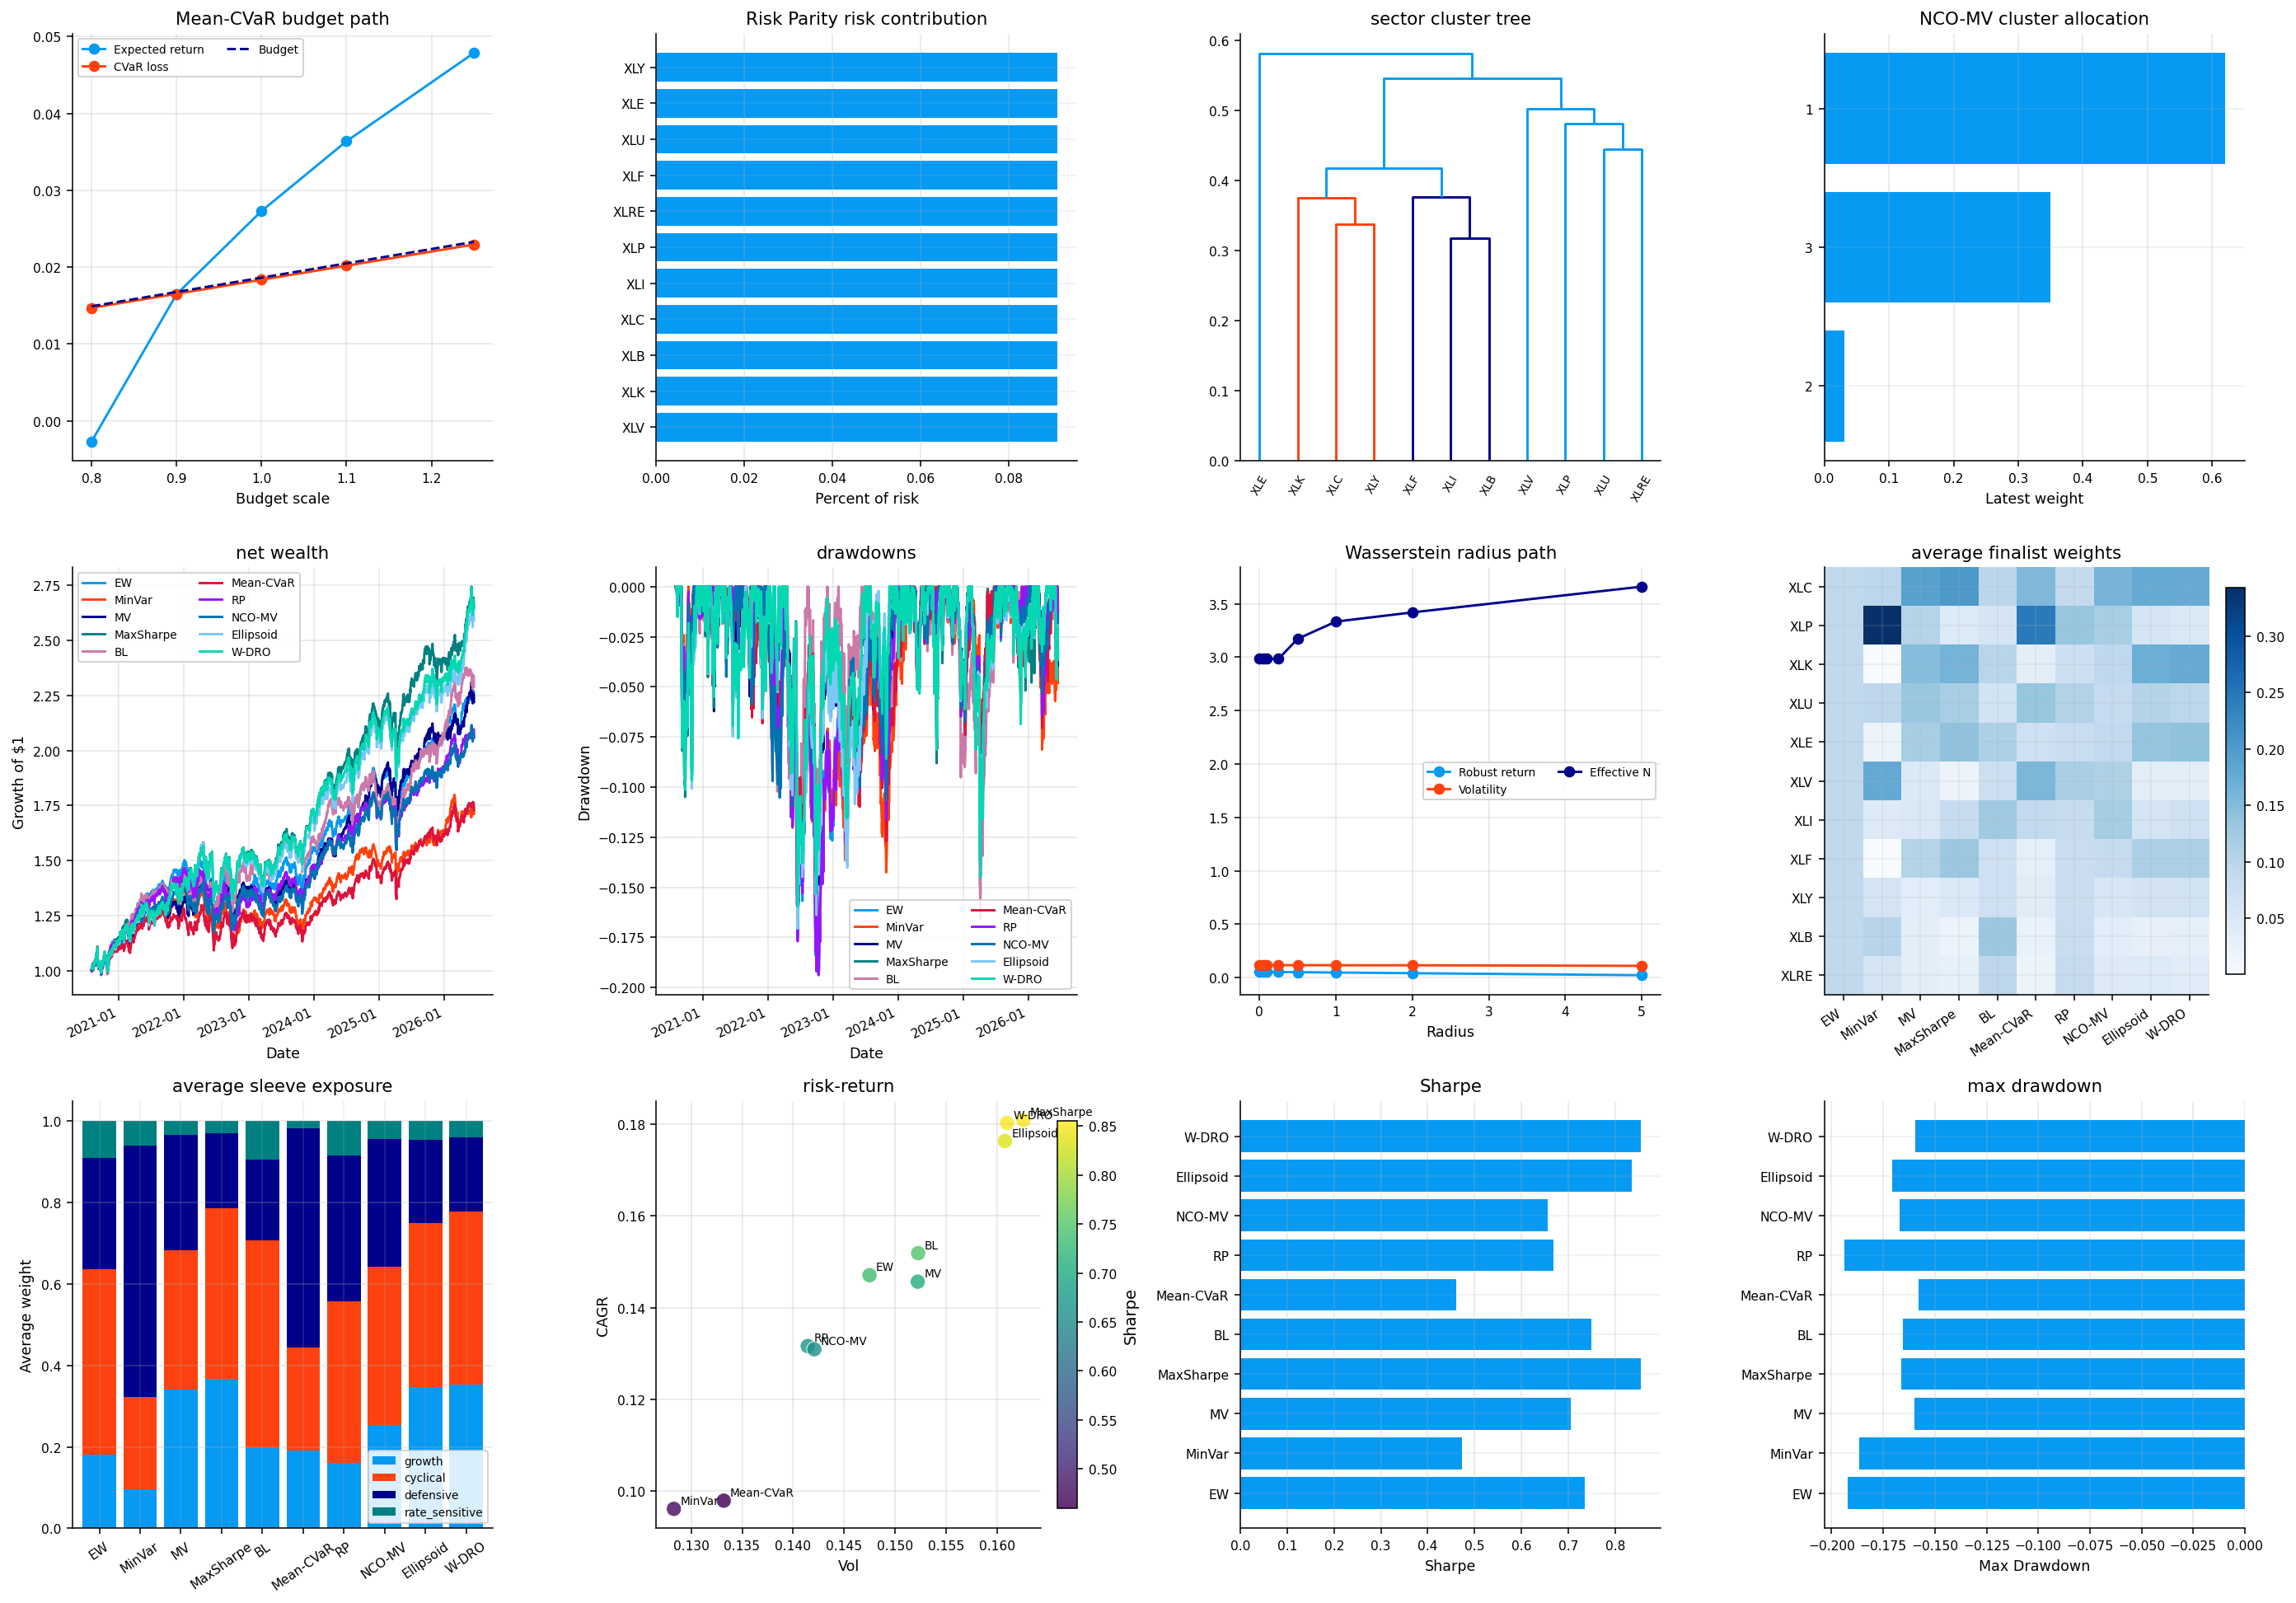

,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
BL,0.0149,0.0219,0.0150,0.0246,0.0127,0.0186
EW,0.0141,0.0214,0.0139,0.0268,0.0102,0.0143
Ellipsoid,0.0159,0.0237,0.0164,0.0270,0.0178,0.0263
MV,0.0151,0.0224,0.0153,0.0266,0.0153,0.0228
MaxSharpe,0.0162,0.0237,0.0164,0.0269,0.0168,0.0243
Mean-CVaR,0.0132,0.0195,0.0135,0.0229,0.0088,0.0128
MinVar,0.0124,0.0186,0.0128,0.0225,0.0098,0.0141
NCO-MV,0.0142,0.0203,0.0139,0.0240,0.0145,0.0204
RP,0.0136,0.0206,0.0135,0.0257,0.0089,0.0129


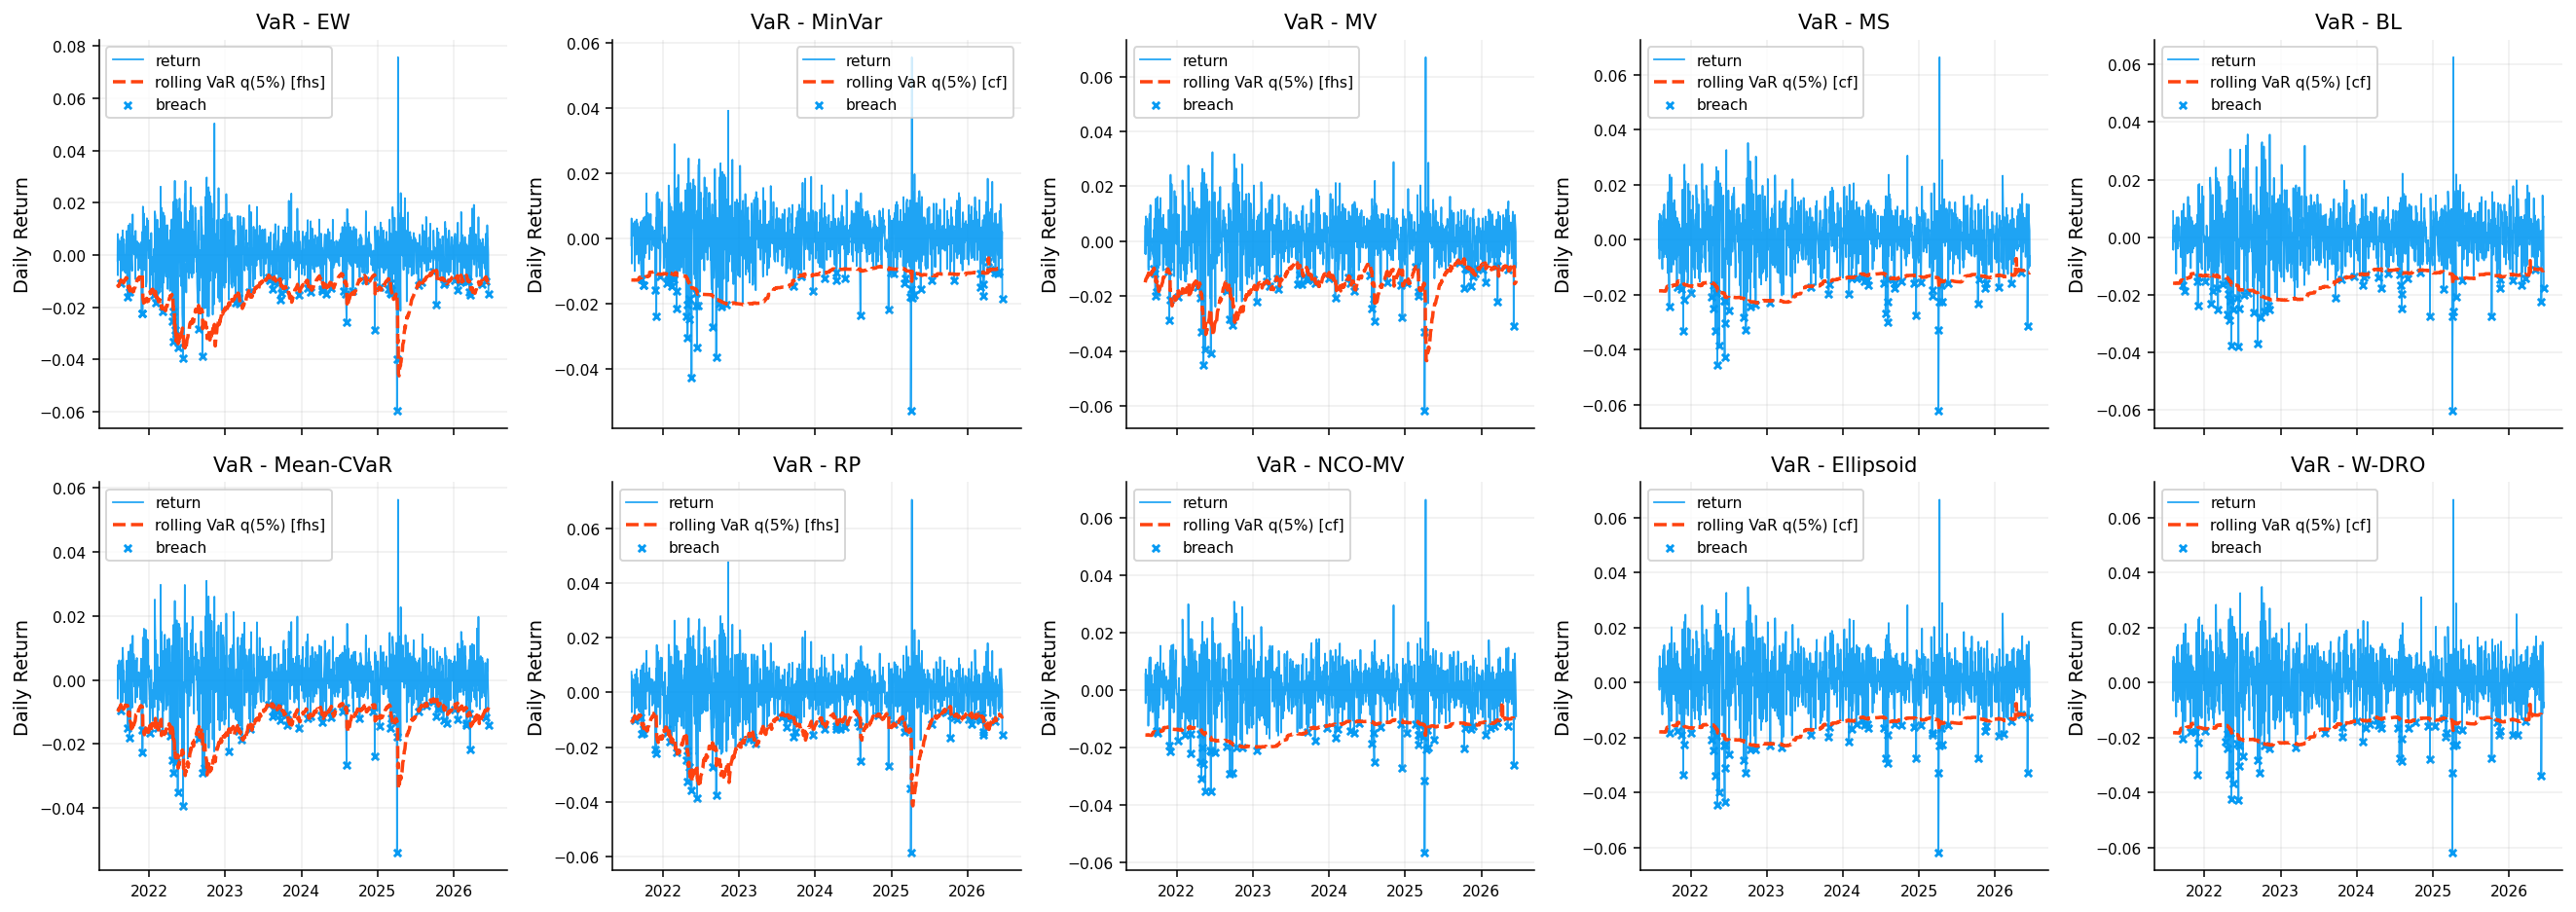

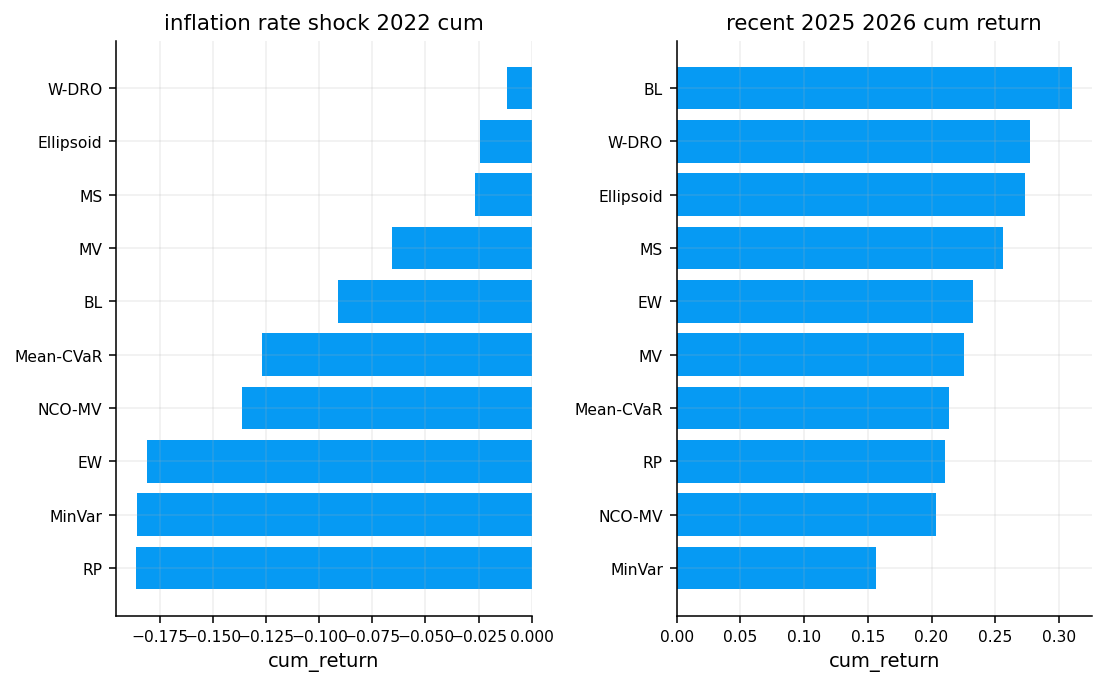

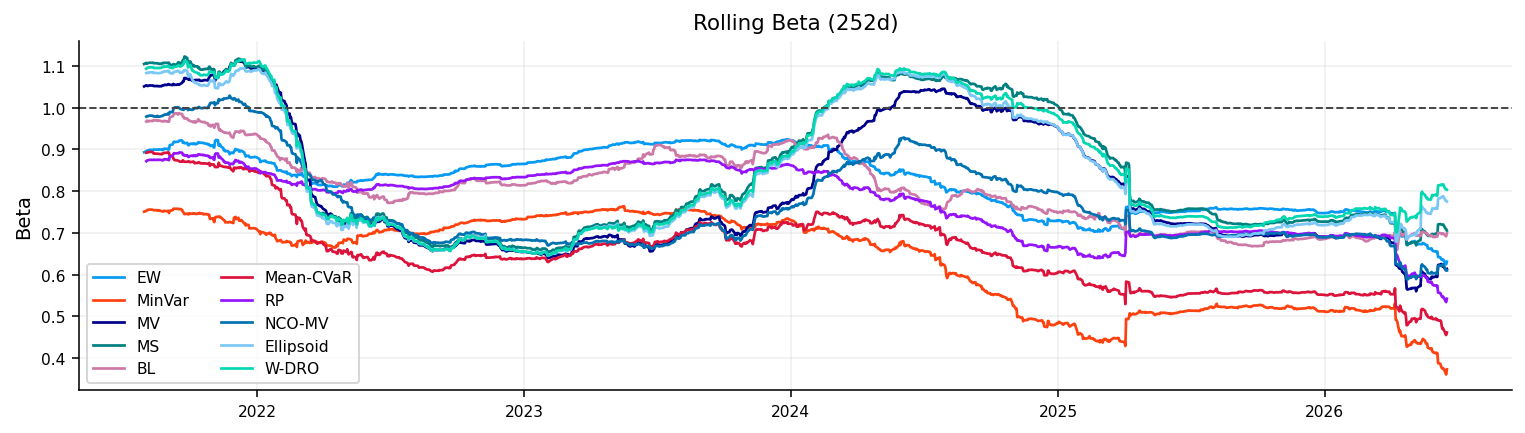

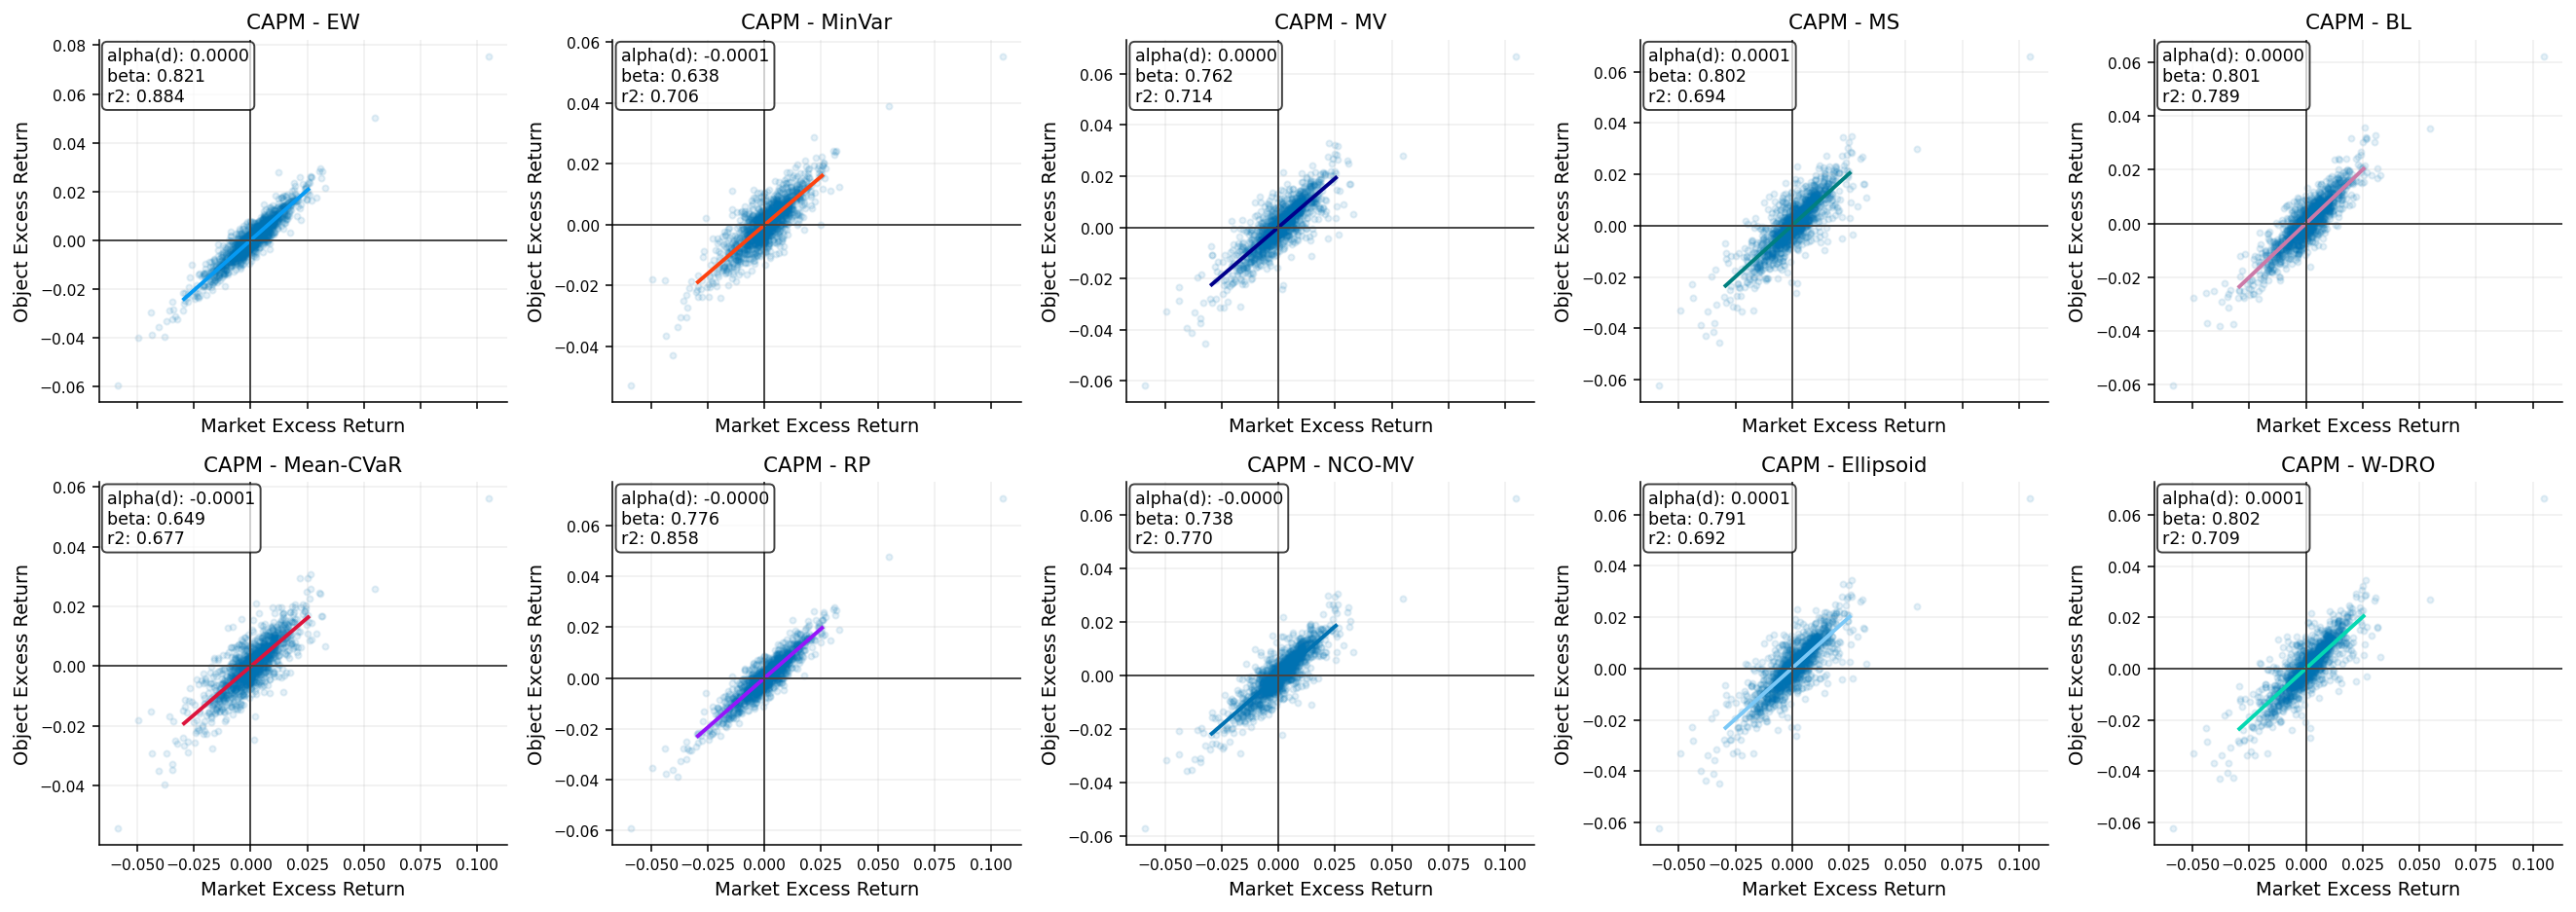

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cycler import cycler
from IPython.display import display

from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.portfolio import prices_to_returns, make_rebalance_dates, selection
from quantfinlab.portfolio.walkforward import run_walkforward_grid, append_frontiergrid_from_best_maxsharpe
from quantfinlab.portfolio import black_litterman as bl
from quantfinlab.portfolio import views as bl_views
from quantfinlab.portfolio.cvar import min_cvar_weight_frame, mean_cvar_weight_frame, cvar_budget_path
from quantfinlab.portfolio.risk_parity import risk_parity_weight_frame, risk_contribution_table
from quantfinlab.portfolio.hrp import hrp_weight_frame, nco_mv_weight_frame, cluster_membership_table
from quantfinlab.portfolio.robust import robust_weight_frames, robust_radius_path
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.reports import risk_report
from quantfinlab.plotting.portfolio import (
    plot_average_weight_heatmap,
    plot_cvar_budget_path,
    plot_finalist_drawdowns,
    plot_finalist_metric_bar,
    plot_finalist_nav,
    plot_hrp_dendrogram,
    plot_nco_cluster_weights,
    plot_risk_contribution_bar,
    plot_risk_return_scatter,
    plot_sleeve_exposure_bar,
    plot_wasserstein_radius_path,
)

warnings.filterwarnings("ignore")

colors = [
    "#069AF3", "#FE420F", "#00008B", "#008080",
    "#CC79A7", "#DC143C", "#9614fa", "#0072B2",
    "#7BC8F6", "#04D8B2", "#800080", "#FF8072",
]

plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update(
    {
        "figure.figsize": (7, 3.5),
        "figure.dpi": 140,
        "savefig.dpi": 250,
        "axes.grid": True,
        "grid.alpha": 0.20,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 7,
    }
)

sector_start = "2018-07-01"
annualization = 252
rebal_freq = "ME"
cov_lookback = 504
mu_lookback = 252
ewma_lambda = 0.97
risk_free_rate_annual = 0.04
risk_free_daily = (1.0 + risk_free_rate_annual) ** (1.0 / annualization) - 1.0
cost_bps = 10.0
w_min = 0.0
w_max = 0.35
mv_lambda = 3.0
alt_mv_lambda = 3.0

assets = ["XLK", "XLC", "XLY", "XLF", "XLI", "XLE", "XLB", "XLV", "XLP", "XLU", "XLRE"]
signal_assets = ["SPY", "QQQ", "IWM", "TLT", "IEF", "SHY", "LQD", "HYG", "GLD", "DBC", "UUP"]

sleeve_map = {
    "XLK": "growth",
    "XLC": "growth",
    "XLY": "cyclical",
    "XLF": "cyclical",
    "XLI": "cyclical",
    "XLE": "cyclical",
    "XLB": "cyclical",
    "XLV": "defensive",
    "XLP": "defensive",
    "XLU": "defensive",
    "XLRE": "rate_sensitive",
}

label_map = {
    "Equal Weight": "EW",
    "MinVar": "MinVar",
    "MV": "MV",
    "MaxSharpe": "MaxSharpe",
    "Learned-Confidence BL": "BL",
    "Min-CVaR 95": "Min-CVaR",
    "Mean-CVaR 95": "Mean-CVaR",
    "Risk Parity": "RP",
    "HRP": "HRP",
    "NCO-MV": "NCO-MV",
    "Box Robust MV": "Box-Robust",
    "Ellipsoid Robust MV": "Ellipsoid",
    "Wasserstein DRMV": "W-DRO",
}

data_dir = Path("../data")
if not (data_dir / "sector_etfs.csv").exists():
    data_dir = Path("data")
data_paths = [data_dir / "sector_etfs.csv", data_dir / "core_cross_asset_etfs.csv"]

close_all = load_yfinance_panel(data_paths, fields=("close",), lowercase=False, source="yfinance_export")["close"]
available_assets = [ticker for ticker in assets if ticker in close_all.columns]
available_signals = [ticker for ticker in signal_assets if ticker in close_all.columns]
if len(available_assets) != len(assets):
    raise ValueError(f"missing sector ETF data: {sorted(set(assets) - set(available_assets))}")

close = close_all.loc[pd.Timestamp(sector_start):, assets].ffill(limit=3).dropna(how="any")
returns = prices_to_returns(close, kind="simple").replace([np.inf, -np.inf], np.nan).dropna(how="all").fillna(0.0)
close = close.reindex(returns.index).ffill(limit=3)

signal_tickers = list(dict.fromkeys(assets + available_signals))
signal_close = close_all.loc[returns.index.min():, signal_tickers].ffill(limit=3).reindex(returns.index).ffill(limit=3)
signal_returns = prices_to_returns(signal_close, kind="simple").replace([np.inf, -np.inf], np.nan).reindex(returns.index).fillna(0.0)

rebalance_dates = make_rebalance_dates(
    returns.index,
    freq=rebal_freq,
    min_history_days=max(cov_lookback, mu_lookback),
)

universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(assets), "avg_dollar_volume": pd.Series(1.0, index=assets)}
    for dt in rebalance_dates
}

print("sector returns:", returns.shape, returns.index.min().date(), "to", returns.index.max().date())
print("rebalance dates:", len(rebalance_dates), rebalance_dates[0].date(), "to", rebalance_dates[-1].date())

sector_grid = run_walkforward_grid(
    returns=returns,
    close=close,
    rebalance_dates=rebalance_dates,
    universe_by_date=universe_by_date,
    cov_lookback=cov_lookback,
    mu_lookback=mu_lookback,
    min_cov_observations=cov_lookback - 1,
    min_mu_observations=mu_lookback - 1,
    max_weight=w_max,
    min_weight=w_min,
    long_only=True,
    trading_cost_bps=cost_bps,
    turnover_penalty_bps=cost_bps,
    fallback="equal",
    rf_daily=risk_free_daily,
    annualization=annualization,
    ewma_lambda=ewma_lambda,
    optimizer_params={
        "MV": {"mv_lambda": mv_lambda},
        "RidgeMV": {"mv_lambda": mv_lambda},
        "FrontierGrid": {"grid_n": 15},
    },
)

sector_grid = append_frontiergrid_from_best_maxsharpe(sector_grid, metric="Sharpe", grid_n=25)
grid_summary = sector_grid.results.replace([np.inf, -np.inf], np.nan)

equal_grid_name = "EW" if "EW" in sector_grid.backtests else str(grid_summary.index[grid_summary["Optimizer"].eq("EW")][0])
minvar_name = str(grid_summary.loc[grid_summary["Optimizer"].eq("MinVar")].dropna(subset=["Sharpe"]).sort_values(["Sharpe", "Max Drawdown", "Turnover", "CAGR"], ascending=[False, False, True, False]).index[0])
mv_name = str(grid_summary.loc[grid_summary["Optimizer"].eq("MV")].dropna(subset=["Sharpe"]).sort_values(["Sharpe", "Max Drawdown", "Turnover", "CAGR"], ascending=[False, False, True, False]).index[0])
maxsharpe_candidates = grid_summary.loc[grid_summary["Optimizer"].eq("MaxSharpe")].dropna(subset=["Sharpe"])
if maxsharpe_candidates.empty:
    maxsharpe_candidates = grid_summary.loc[grid_summary["Optimizer"].eq("FrontierGrid")].dropna(subset=["Sharpe"])
maxsharpe_name = str(maxsharpe_candidates.sort_values(["Sharpe", "Max Drawdown", "Turnover", "CAGR"], ascending=[False, False, True, False]).index[0])

_, _, minvar_cov = selection.parse_strategy_spec(minvar_name, sector_grid.backtests[minvar_name])
_, mv_mu, mv_cov = selection.parse_strategy_spec(mv_name, sector_grid.backtests[mv_name])
_, maxsharpe_mu, maxsharpe_cov = selection.parse_strategy_spec(maxsharpe_name, sector_grid.backtests[maxsharpe_name])

robust_cov = "EWMA" if "EWMA" in sector_grid.metadata.get("cov_models", []) else maxsharpe_cov
robust_mu = "BayesStein" if "BayesStein" in sector_grid.metadata.get("mu_models", []) else maxsharpe_mu
robust_box_radius = 0.10
robust_ellipsoid_radius = 0.05
robust_wasserstein_radius = 2.0
robust_mv_lambda = 1.5
robust_wasserstein_lambda = 1.0

print("selected grid models:", {"MinVar": minvar_name, "MV": mv_name, "MaxSharpe": maxsharpe_name})
print("selected robust models:", {"cov": robust_cov, "mu": robust_mu, "lambda": robust_mv_lambda, "wasserstein_lambda": robust_wasserstein_lambda, "box_radius": robust_box_radius, "ellipsoid_radius": robust_ellipsoid_radius, "wasserstein_radius": robust_wasserstein_radius})

sector_benchmark_w = pd.Series(1.0 / len(assets), index=assets, dtype=float)
sector_roles_raw = {
    "assets": assets,
    "growth": ["XLK", "XLC", "XLY"],
    "defensive": ["XLP", "XLU", "XLV"],
    "cyclical": ["XLI", "XLF", "XLB", "XLE"],
    "inflation_beneficiaries": ["XLE", "XLB"],
    "rate_sensitive": ["XLU", "XLV", "XLRE"],
    "credit_sensitive": ["XLF", "XLY", "XLI"],
    "quality_defensive": ["XLV", "XLP"],
    "small_cap_sensitive": ["XLI", "XLF", "XLY"],
    "risky": assets,
    "sleeve_map": {ticker: "Sector" for ticker in assets},
}
sector_roles = {
    key: ([ticker for ticker in value if ticker in assets] if isinstance(value, list) else value)
    for key, value in sector_roles_raw.items()
}

sector_family_caps = {
    "sector_momentum": 0.08,
    "growth_leadership": 0.06,
    "defensive_rotation": 0.06,
    "cyclical_breadth": 0.80,
    "credit_beta": 0.07,
    "inflation_beneficiaries": 0.06,
    "duration_sensitive": 0.06,
    "small_cap_risk_on": 0.08,
    "quality_defensive": 0.05,
    "sector_reversal": 0.08,
}

sector_view_settings = bl_views.ViewSettings(
    family_q_caps=sector_family_caps,
    family_display_names=bl_views.DEFAULT_SECTOR_DISPLAY_NAMES,
    assets=assets,
    entry_z=0.50,
    q_strength_scale=1.25,
    annualization=annualization,
    view_horizon_days=21,
)

sector_bl_settings = bl.BLSettings(
    cov_lookback=504,
    mu_lookback=252,
    risk_free_rate_annual=risk_free_rate_annual,
    transaction_cost_bps=cost_bps,
    tau=0.05,
    ewma_lambda=ewma_lambda,
    max_weight=0.35,
    active_weight_limit=0.15,
    active_weight_relaxed=0.22,
    max_selected_views=7,
    redundancy_similarity=0.85,
    max_same_direction=5,
)

sector_view_functions = (
    bl_views.sector_momentum,
    bl_views.growth_leadership,
    bl_views.defensive_rotation,
    bl_views.cyclical_breadth,
    bl_views.credit_beta,
    bl_views.inflation_beneficiaries,
    bl_views.duration_sensitive,
    bl_views.small_cap_risk_on,
    bl_views.quality_defensive,
    bl_views.sector_reversal,
)

sector_asset_caps = pd.Series(sector_bl_settings.max_weight, index=assets, dtype=float)
sector_bl_run = bl.learned_confidence_bl(
    returns=returns,
    signal_returns=signal_returns,
    rebalance_dates=rebalance_dates,
    benchmark_weights=sector_benchmark_w,
    roles=sector_roles,
    view_functions=sector_view_functions,
    view_settings=sector_view_settings,
    settings=sector_bl_settings,
    constraints={"asset_caps": sector_asset_caps},
)

sector_bl_result = run_many_weights_backtests(
    {"Learned-Confidence BL": sector_bl_run.weights},
    returns=returns,
    cost_bps=cost_bps,
    rf_daily=risk_free_daily,
    w_min=sector_bl_settings.min_weight,
    w_max=sector_bl_settings.max_weight,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)["Learned-Confidence BL"]

print("BL view rows:", len(sector_bl_run.candidate_view_log), "candidate,", len(sector_bl_run.selected_view_log), "selected")

benchmark_results = {
    "Equal Weight": sector_grid.backtests[equal_grid_name],
    "MinVar": sector_grid.backtests[minvar_name],
    "MV": sector_grid.backtests[mv_name],
    "MaxSharpe": sector_grid.backtests[maxsharpe_name],
    "Learned-Confidence BL": sector_bl_result,
}

benchmark_table = selection.build_strategy_summary(
    benchmark_results,
    rf_daily=risk_free_daily,
    annualization=annualization,
)
display(benchmark_table[["CAGR", "Vol", "Sharpe", "Sortino", "Calmar", "Max Drawdown", "Turnover", "Effective N"]].round(4))

weights_min_cvar = min_cvar_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=minvar_cov,
    alpha=0.95,
    w_min=w_min,
    w_max=w_max,
)

weights_mean_cvar = mean_cvar_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=maxsharpe_cov,
    mu_model=maxsharpe_mu,
    reference="equal",
    alpha=0.95,
    budget_scale=0.90,
    w_min=w_min,
    w_max=w_max,
)

weights_rp = risk_parity_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=minvar_cov,
    w_min=w_min,
    w_max=w_max,
)

weights_hrp = hrp_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=minvar_cov,
    linkage_method="average",
    w_min=w_min,
    w_max=w_max,
)

weights_nco = nco_mv_weight_frame(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=maxsharpe_cov,
    mu_model=maxsharpe_mu,
    n_clusters=3,
    inner_lambda=alt_mv_lambda,
    outer_lambda=alt_mv_lambda,
    cluster_cap=0.75,
    linkage_method="average",
    w_min=w_min,
    w_max=w_max,
)

robust_weights = robust_weight_frames(
    cache=sector_grid.cache,
    rebalance_dates=rebalance_dates,
    cov_model=robust_cov,
    mu_model=robust_mu,
    box_radius=robust_box_radius,
    ellipsoid_radius=robust_ellipsoid_radius,
    wasserstein_radius=robust_wasserstein_radius,
    mv_lambda=robust_mv_lambda,
    wasserstein_mv_lambda=robust_wasserstein_lambda,
    w_min=w_min,
    w_max=w_max,
)
weights_box = robust_weights["Box Robust MV"]
weights_ellipsoid = robust_weights["Ellipsoid Robust MV"]
weights_wasserstein = robust_weights["Wasserstein DRMV"]

weights_by_name = {
    "Min-CVaR 95": weights_min_cvar,
    "Mean-CVaR 95": weights_mean_cvar,
    "Risk Parity": weights_rp,
    "HRP": weights_hrp,
    "NCO-MV": weights_nco,
    "Box Robust MV": weights_box,
    "Ellipsoid Robust MV": weights_ellipsoid,
    "Wasserstein DRMV": weights_wasserstein,
}

results = dict(benchmark_results)
results.update(
    run_many_weights_backtests(
        weights_by_name,
        returns=returns,
        cost_bps=cost_bps,
        rf_daily=risk_free_daily,
        w_min=w_min,
        w_max=w_max,
        long_only=True,
        normalize=True,
        weight_timing="next_close",
    )
)

summary = selection.build_strategy_summary(
    results,
    rf_daily=risk_free_daily,
    annualization=annualization,
).sort_values(["Sharpe", "Calmar", "CAGR"], ascending=[False, False, False])

best_cvar = summary.loc[["Min-CVaR 95", "Mean-CVaR 95"]].sort_values(["Sharpe", "Calmar", "CAGR"], ascending=[False, False, False]).index[0]
best_hier = summary.loc[["HRP", "NCO-MV"]].sort_values(["Sharpe", "Calmar", "CAGR"], ascending=[False, False, False]).index[0]
best_robust = summary.loc[["Box Robust MV", "Ellipsoid Robust MV"]].sort_values(["Sharpe", "Calmar", "CAGR"], ascending=[False, False, False]).index[0]

finalists = list(
    dict.fromkeys(
        [
            "Equal Weight",
            "MinVar",
            "MV",
            "MaxSharpe",
            "Learned-Confidence BL",
            best_cvar,
            "Risk Parity",
            best_hier,
            best_robust,
            "Wasserstein DRMV",
        ]
    )
)

final_table = summary.loc[finalists, ["CAGR", "Vol", "Sharpe", "Sortino", "Calmar", "Max Drawdown", "Turnover", "Effective N"]]
display(final_table.round(4))

nav = pd.concat({name: results[name].net_values for name in finalists}, axis=1)
returns_final = pd.concat({name: results[name].net_returns for name in finalists}, axis=1).dropna(how="all")
weights_final = {name: results[name].weights for name in finalists}

latest_dt = pd.Timestamp(weights_wasserstein.index[-1])
latest_state = sector_grid.cache[latest_dt]
latest_tickers = list(latest_state["tickers"])
latest_cov = pd.DataFrame(latest_state["cov_ann_map"][maxsharpe_cov], index=latest_tickers, columns=latest_tickers)
latest_mu = latest_state["mu_ann_map"][maxsharpe_cov][maxsharpe_mu].reindex(latest_tickers).fillna(0.0)
latest_robust_cov = pd.DataFrame(latest_state["cov_ann_map"][robust_cov], index=latest_tickers, columns=latest_tickers)
latest_robust_mu = latest_state["mu_ann_map"][robust_cov][robust_mu].reindex(latest_tickers).fillna(0.0)

cvar_path = cvar_budget_path(
    returns=latest_state["R_cov"].reindex(columns=latest_tickers),
    mu_ann=latest_mu,
    budget_scales=[0.80, 0.90, 1.00, 1.10, 1.25],
    alpha=0.95,
    w_min=w_min,
    w_max=w_max,
)

rp_table = risk_contribution_table(
    weights=weights_rp.iloc[-1].reindex(latest_tickers).fillna(0.0),
    cov_ann=latest_state["cov_ann_map"][minvar_cov],
)

cluster_table = cluster_membership_table(
    cov_ann=latest_state["cov_ann_map"][maxsharpe_cov],
    tickers=latest_tickers,
    n_clusters=3,
    linkage_method="average",
)

wasserstein_path = robust_radius_path(
    model="wasserstein",
    mu_ann=latest_robust_mu,
    cov_ann=latest_robust_cov,
    n_mu_obs=len(latest_state["R_mu"]),
    radii=[0.0, 0.05, 0.10, 0.25, 0.50, 1.00, 2.00, 5.00],
    mv_lambda=robust_wasserstein_lambda,
    w_min=w_min,
    w_max=w_max,
)

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.ravel()

plot_cvar_budget_path(cvar_path, ax=axes[0], title="Mean-CVaR budget path")
plot_risk_contribution_bar(rp_table, ax=axes[1], title="Risk Parity risk contribution")
plot_hrp_dendrogram(latest_state["cov_ann_map"][maxsharpe_cov], labels=latest_tickers, linkage_method="average", ax=axes[2], title="sector cluster tree")
plot_nco_cluster_weights(cluster_table, weights_nco.iloc[-1], ax=axes[3], title="NCO-MV cluster allocation")
plot_finalist_nav(nav, strategies=finalists, ax=axes[4], title="net wealth", short_labels=label_map)
plot_finalist_drawdowns(nav, strategies=finalists, ax=axes[5], title="drawdowns", short_labels=label_map)
plot_wasserstein_radius_path(wasserstein_path, ax=axes[6], title="Wasserstein radius path")
plot_average_weight_heatmap(weights_final, ax=axes[7], title="average finalist weights", short_labels=label_map)
plot_sleeve_exposure_bar(weights_final, sleeve_map, ax=axes[8], title="average sleeve exposure", short_labels=label_map)
plot_risk_return_scatter(final_table, ax=axes[9], title="risk-return", risk_col="Vol", return_col="CAGR", color_col="Sharpe", short_labels=label_map)
plot_finalist_metric_bar(final_table, metric="Sharpe", ax=axes[10], title="Sharpe", short_labels=label_map)
plot_finalist_metric_bar(final_table, metric="Max Drawdown", ax=axes[11], title="max drawdown", short_labels=label_map)

plt.tight_layout()
plt.show()

stress_windows = {
    "2018_q4": ("2018-10-01", "2018-12-31"),
    "covid_crash_2020": ("2020-02-19", "2020-03-23"),
    "inflation_rate_shock_2022": ("2022-01-03", "2022-10-14"),
}

if returns_final.index.max() >= pd.Timestamp("2025-01-01"):
    stress_windows["recent_2025_2026"] = ("2025-01-01", str(returns_final.index.max().date()))

market_ret = signal_returns["SPY"].reindex(returns_final.index) if "SPY" in signal_returns.columns else returns.mean(axis=1).reindex(returns_final.index)

sector_risk_report = risk_report(
    objects={name: returns_final[name].dropna() for name in finalists},
    market_ret=market_ret,
    rf_daily=risk_free_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": True,
        "rolling_beta": True,
        "correlation": False,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    rolling_settings={"vol_windows": [252], "beta_windows": [252]},
    stress_settings={"windows": stress_windows, "worst_only": False},
    layout={"ncols": 5, "sharex": True, "sharey": False},
    output={
        "display_table_keys": ["var_es"],
        "round_tables": 4,
        "print_exec_bullets": False,
        "show_figures": False,
        "short_labels": True,
        "label_max_len": 12,
        "label_map": label_map,
    },
)

for key in ["var_backtest", "stress", "rolling_beta"]:
    for fig in sector_risk_report.figures.get(key, []):
        display(fig)
        plt.close(fig)



The sector benchmark table shows strong equity-market returns over the sample. Equal Weight earns 14.71% CAGR with 14.75% volatility and 0.7352 Sharpe. MaxSharpe is the strongest model among the first five benchmarks: 18.09% CAGR, 16.26% volatility, 0.8550 Sharpe, and 1.0872 Calmar.

BL improves over equal weight, but doesn't beat MaxSharpe:

$$
\text{BL CAGR}=15.19\%,\qquad \text{BL Sharpe}=0.7497
$$

Its turnover is very high at 46.47% average monthly. That is a warning. Sector rotation views move allocations a lot, and when all assets share market beta, the benefit of those rotations must be large enough to pay for turnover.

MV has a strong Calmar of 0.9112 and a max drawdown of -15.99%, better than Equal Weight's -19.23%. MinVar lowers volatility but gives up too much return, similar to the main cross-asset application. This benchmark-only table is important because the robust and tail-risk models need to beat a serious sector MaxSharpe baseline, not just Equal Weight.

After adding the new Project 10 models, the sector finalist table changes materially. Wasserstein DRMV, now run with the sector-specific `EWMA` covariance and `BayesStein` expected-return inputs, is essentially tied with MaxSharpe by Sharpe and is better on Calmar and drawdown.

The sector results are:

- **MaxSharpe:** 18.09% CAGR, 0.8550 Sharpe, 1.0872 Calmar.
- **Wasserstein DRMV:** 18.03% CAGR, 0.8550 Sharpe, 1.1295 Calmar.
- **Ellipsoid Robust MV:** 17.64% CAGR, 0.8355 Sharpe, 1.0334 Calmar.
- **Learned-Confidence BL:** 15.19% CAGR, 0.7497 Sharpe.
- **Equal Weight:** 14.71% CAGR, 0.7352 Sharpe.
- **MV:** 14.57% CAGR, 0.7049 Sharpe.
- **NCO-MV:** 13.09% CAGR, 0.6568 Sharpe.
- **Risk Parity:** 13.16% CAGR, 0.6681 Sharpe.
- **Mean-CVaR 95:** 9.79% CAGR, 0.4601 Sharpe.

The important correction is that the robust models no longer lag. The weak sector result came from carrying the cross-asset `LedoitWolf + Momentum` recipe into a sector-only universe. With `EWMA + BayesStein`, the same W-DRO theory becomes competitive with the best sector MaxSharpe model while holding a slightly more diversified average portfolio: effective $N$ is 3.67 for W-DRO versus 3.24 for MaxSharpe. The cost is turnover, 22.05% versus MaxSharpe's 17.29%, but that is still far below BL's 46.47%.

The sector risk table shows the other side of the result. W-DRO is now one of the best return-adjusted sector models, but it is not the lowest-tail-risk model. That is the right interpretation: this is distributionally robust mean-variance, not a CVaR minimizer.

Historical ES values:

- MinVar: 1.86%.
- Mean-CVaR: 1.95%.
- NCO-MV: 2.03%.
- Risk Parity: 2.06%.
- Equal Weight: 2.14%.
- BL: 2.19%.
- MV: 2.24%.
- W-DRO: 2.36%.
- MaxSharpe: 2.37%.
- Ellipsoid Robust MV: 2.37%.

The filtered historical simulation ES ranking is even clearer. Mean-CVaR and Risk Parity are around 1.28%-1.29%, MinVar and Equal Weight are around 1.41%-1.43%, while W-DRO and Ellipsoid are around 2.64% and 2.63%. So the robust return-seeking models earn their higher Sharpe by accepting larger scaled tail exposure than the defensive models.

The range is narrower than in the cross-asset case because all sector ETFs still share equity beta. Sector rotation can reduce sector-specific drawdown, but it can't fully escape market shocks. The plots show this: sector models differ in wealth paths and drawdowns, but they stay much more correlated than cross-asset models.

The sector stress and rolling-beta plots need to be read with this common-beta structure in mind. In a cross-asset universe, a model can reduce equity beta by moving into duration, cash-like bonds, gold, or commodities. In a sector universe, the model can only choose **which kind of equity beta** it wants. That means sector tail control usually comes from avoiding the worst sector leadership, not from escaping the equity market.

During 2022, this distinction helps the sector models more than during COVID. The 2022 environment had clear cross-sectional sector dispersion: Energy benefited from the inflation and commodity shock, defensive sectors held up better than long-duration growth, and rate-sensitive sectors struggled. A sector allocation model can exploit that dispersion. During COVID's initial crash, sector dispersion existed, but the first-order move was broad market deleveraging. In that type of shock, all sector ETFs drop together and the model has less room to defend.

This is why sector Mean-CVaR has lower ES than the active return-seeking models but doesn't become dramatically safer. Its historical ES is 1.95%, better than BL, W-DRO, MaxSharpe, and Ellipsoid, but still far above the defensive tail levels seen in the cross-asset Risk Parity and HRP portfolios. The opportunity set defines the achievable tail reduction.

The sector rolling-beta plots also help diagnose model behavior. A sector strategy can lower beta by leaning toward Staples, Health Care, and Utilities, or increase beta by leaning toward Technology, Consumer Discretionary, Financials, Industrials, and Energy depending on the regime. W-DRO's better full-period drawdown comes from this rotation plus the Wasserstein diversification penalty, not from eliminating equity exposure. Beta rarely collapses toward zero because every tradable asset remains inside the equity market.

The sector diagnostic panel shows how the same model tools translate to an equity-only universe:

- The Mean-CVaR budget path still shows the return-tail tradeoff.
- Risk Parity spreads risk more evenly across sectors than equal capital weighting.
- The sector cluster tree separates growth, defensive, cyclicals, and rate-sensitive groups.
- NCO-MV turns those clusters into a nested allocation.
- The Wasserstein radius path shows robust diversification pressure as ambiguity increases.
- Average weight heatmaps reveal which sector exposures each model repeatedly favors.

This secondary run is a good stress test of portability. The library functions work, the same model families run, and the comparison metrics are consistent. But the estimation recipe has to change with the universe. Cross-asset allocation can use structurally different risk premia. Sector allocation mostly chooses different expressions of equity beta, so the model benefits from a faster covariance estimate and a shrunk expected-return estimate.

The Wasserstein radius path is especially useful after the retune. Radius 2.0 produces almost the same Sharpe as the more aggressive low-radius sector W-DRO setting, but with better drawdown, lower turnover, and a higher effective $N$. That is a good robust result: the ambiguity set is not just weakening the optimizer; it is buying a more stable version of a high-Sharpe sector allocation.

The sector plots also show a useful implementation lesson. The same library functions produce a consistent report, but the interpretation has to change with the asset universe.

The average-weight heatmap is especially useful here. In cross-asset allocation, seeing a large weight in SHY, DBC, GLD, or EEM tells us the model is making an asset-class decision. In sectors, seeing a large weight in XLK, XLE, XLV, or XLP tells us the model is making a **style and macro sensitivity** decision. XLK/XLC/XLY usually express growth and long-duration equity exposure. XLE/XLB express inflation and commodity sensitivity. XLV/XLP express quality/defensive cash-flow exposure. XLF/XLI express cyclicality and credit/economic acceleration.

So the sector version is less about "safe versus risky assets" and more about "which equity risk is being selected." This is why MaxSharpe and W-DRO can both lead in the sector run. MaxSharpe captures persistent sector leadership directly. W-DRO captures much of the same leadership, but taxes concentration and distributional ambiguity, which gives it slightly lower CAGR but better Calmar, drawdown, and diversification.

This secondary result makes the main project stronger. It shows that robust optimization is not a single fixed parameter choice. The theory stays the same, but the empirical inputs need to fit the market being modeled: `LedoitWolf + Momentum` works better as the cross-asset robust prior, while `EWMA + BayesStein` is the stronger sector recipe. That is the difference between a weak inspired version of W-DRO and a correctly implemented robust model that actually competes.